# 02 - Customer, Seller, and Geolocation EDA and Preprocessing

**Member B contribution:** customers, sellers, geolocation, geographical exploratory data analysis, preprocessing, and order-level geographic feature engineering.

This notebook is the working record for Member B's analysis. It will document assumptions, validation evidence, preprocessing decisions, and the production of geography-related datasets for downstream integration.

## 2. Business Problem and Prediction Objective

The project aims to predict whether an Olist order will be delivered late. Member B contributes customer, seller, and geographic information that may explain delivery risk, such as distance proxies, state and region relationships, and the geographic distribution of sellers linked to an order.

Member A owns target engineering. This notebook will consume the agreed target only after Member A makes it available; it will not define or modify the target.

## 3. Scope and Ownership Boundaries

**In scope for Member B**

- Audit and preprocess customer, seller, and geolocation data.
- Create stable geographic attributes and Brazilian region features.
- Enrich customers and sellers with cleaned location data.
- Create order-level geographic features for the final integration step.

**Ownership boundaries**

- Raw files are read-only and must never be overwritten.
- Orders and order_items are used only as relationship bridges.
- Member A owns target engineering.
- Member C owns order-item and product preprocessing.
- Member D owns the final overall merge.
- This notebook will not modify another member's notebook, processed output, or shared source code.

## 4. Library Imports and Path Configuration

Imports and repository-relative path configuration will be added here. Paths will be resolved from the repository structure so that the notebook does not depend on a machine-specific absolute path. Randomness, display settings, and plotting conventions will be declared explicitly where relevant.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def find_repository_root(start: Path) -> Path:
    """Find the repository root when launched from the root or notebooks directory."""
    resolved_start = start.resolve()
    for candidate in (resolved_start, *resolved_start.parents):
        if (candidate / "data" / "raw").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate a repository containing data/raw and notebooks.")


REPO_ROOT = find_repository_root(Path.cwd())
RAW_DIR = REPO_ROOT / "data" / "raw"

display(pd.DataFrame({"resolved_path": [str(REPO_ROOT), str(RAW_DIR)]}, index=["repository_root", "raw_data_directory"]))

,resolved_path
repository_root,C:\Users\Hasini\OneDrive\Desktop\FDM project\O...
raw_data_directory,C:\Users\Hasini\OneDrive\Desktop\FDM project\O...


**Interpretation.** The repository root was resolved successfully from the active working directory, and all raw inputs are referenced through the repository-relative `data/raw` path. No machine-specific project path is embedded in the notebook.

## 5. Dataset Loading

The customer, seller, and geolocation tables will be loaded from `data/raw/` without modification. The orders and order_items tables may be read later only to connect customer and seller records to an order. Loading checks will confirm file presence, parse success, row counts, and expected columns before analysis begins.

In [2]:
CUSTOMERS_PATH = RAW_DIR / "olist_customers_dataset.csv"
SELLERS_PATH = RAW_DIR / "olist_sellers_dataset.csv"
GEOLOCATION_PATH = RAW_DIR / "olist_geolocation_dataset.csv"

required_paths = [CUSTOMERS_PATH, SELLERS_PATH, GEOLOCATION_PATH]
missing_files = [path.name for path in required_paths if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f"Missing required raw files: {missing_files}")

customers = pd.read_csv(
    CUSTOMERS_PATH,
    dtype={"customer_zip_code_prefix": "string"},
)
sellers = pd.read_csv(
    SELLERS_PATH,
    dtype={"seller_zip_code_prefix": "string"},
)
geolocation = pd.read_csv(
    GEOLOCATION_PATH,
    dtype={"geolocation_zip_code_prefix": "string"},
)

datasets = {
    "customers": customers,
    "sellers": sellers,
    "geolocation": geolocation,
}
zip_columns = {
    "customers": "customer_zip_code_prefix",
    "sellers": "seller_zip_code_prefix",
    "geolocation": "geolocation_zip_code_prefix",
}

load_summary = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(frame),
            "columns": frame.shape[1],
            "zip_dtype": str(frame[zip_columns[name]].dtype),
            "five_character_zip_rows": int(frame[zip_columns[name]].str.len().eq(5).sum()),
        }
        for name, frame in datasets.items()
    ]
).set_index("table")
display(load_summary)

,rows,columns,zip_dtype,five_character_zip_rows
table,,,,
customers,99441,5,string,99441
sellers,3095,4,string,3095
geolocation,1000163,5,string,1000163


**Interpretation.** The three authorized raw tables loaded successfully: customers has **99,441 rows and 5 columns**, sellers has **3,095 rows and 4 columns**, and geolocation has **1,000,163 rows and 5 columns**. Every ZIP-prefix value was loaded with pandas' string dtype and all **1,102,699** rows across the tables retain a five-character prefix, including leading zeros. Orders and order_items were not loaded.

## 6. Data Dictionary and Table Grain

This section will define each source table's business meaning, expected grain, identifiers, geographic fields, and planned use. Particular attention will be given to the distinction between `customer_id` and `customer_unique_id`, the seller identifier, geolocation ZIP-code prefixes, and one-to-many relationships introduced by order items.

In [3]:
data_dictionary = pd.DataFrame(
    [
        {
            "table": "customers",
            "expected_grain": "one row per order-specific customer_id",
            "key_fields": "customer_id; customer_unique_id",
            "geographic_fields": "customer_zip_code_prefix; customer_city; customer_state",
        },
        {
            "table": "sellers",
            "expected_grain": "one row per seller_id",
            "key_fields": "seller_id",
            "geographic_fields": "seller_zip_code_prefix; seller_city; seller_state",
        },
        {
            "table": "geolocation",
            "expected_grain": "one row per observed ZIP-prefix coordinate record",
            "key_fields": "geolocation_zip_code_prefix (non-unique)",
            "geographic_fields": "geolocation_lat; geolocation_lng; geolocation_city; geolocation_state",
        },
    ]
).set_index("table")
display(data_dictionary)

,expected_grain,key_fields,geographic_fields
table,,,
customers,one row per order-specific customer_id,customer_id; customer_unique_id,customer_zip_code_prefix; customer_city; custo...
sellers,one row per seller_id,seller_id,seller_zip_code_prefix; seller_city; seller_state
geolocation,one row per observed ZIP-prefix coordinate record,geolocation_zip_code_prefix (non-unique),geolocation_lat; geolocation_lng; geolocation_...


**Interpretation.** The tables have different grains. `customer_id` identifies an order-specific customer record, while `customer_unique_id` links repeat purchases by the same customer. Sellers are expected to be unique by `seller_id`. Geolocation is an observation table, so its ZIP prefix is expected to repeat and cannot be treated as a primary key without later aggregation.

## 7. Initial Structural Audit

The initial audit will record shapes, column names, data types, representative records, identifier coverage, and basic descriptive statistics. Schema differences from the documented Olist data model will be flagged before transformations are considered.

In [4]:
structural_summary = pd.DataFrame(
    [
        {
            "table": name,
            "shape": str(frame.shape),
            "columns": ", ".join(frame.columns),
        }
        for name, frame in datasets.items()
    ]
).set_index("table")
display(Markdown("### Shapes and columns"), structural_summary)

dtype_summary = pd.concat(
    {name: frame.dtypes.astype(str).rename("dtype") for name, frame in datasets.items()},
    names=["table", "column"],
)
display(Markdown("### Data types"), dtype_summary.to_frame())

for name, frame in datasets.items():
    display(Markdown(f"### First five rows: {name}"), frame.head(5))

### Shapes and columns

,shape,columns
table,,
customers,"(99441, 5)","customer_id, customer_unique_id, customer_zip_..."
sellers,"(3095, 4)","seller_id, seller_zip_code_prefix, seller_city..."
geolocation,"(1000163, 5)","geolocation_zip_code_prefix, geolocation_lat, ..."


### Data types

dtype
table       column                              
customers   customer_id                      str
            customer_unique_id               str
            customer_zip_code_prefix      string
            customer_city                    str
            customer_state                   str
sellers     seller_id                        str
            seller_zip_code_prefix        string
            seller_city                      str
            seller_state                     str
geolocation geolocation_zip_code_prefix   string
            geolocation_lat              float64
            geolocation_lng              float64
            geolocation_city                 str
            geolocation_state                str

### First five rows: customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### First five rows: sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,04195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### First five rows: geolocation

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,01037,-23.5456,-46.6393,sao paulo,SP
1,01046,-23.5461,-46.6448,sao paulo,SP
2,01046,-23.5461,-46.6430,sao paulo,SP
3,01041,-23.5444,-46.6395,sao paulo,SP
4,01035,-23.5416,-46.6416,sao paulo,SP


**Interpretation.** All expected columns are present. Identifier, city, and state fields loaded as strings; all three ZIP-prefix fields loaded as dedicated string columns; and geolocation latitude and longitude loaded as floating-point values. The first five records confirm the expected table layouts without requiring any mutation of the source DataFrames.

In [5]:
for name, frame in datasets.items():
    display(
        Markdown(f"### Descriptive statistics: {name}"),
        frame.describe(include="all").transpose(),
    )

### Descriptive statistics: customers

,count,unique,top,freq
customer_id,99441,99441,06b8999e2fba1a1fbc88172c00ba8bc7,1
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17
customer_zip_code_prefix,99441,14994,22790,142
customer_city,99441,4119,sao paulo,15540
customer_state,99441,27,SP,41746


### Descriptive statistics: sellers

,count,unique,top,freq
seller_id,3095,3095,3442f8959a84dea7ee197c632cb2df15,1
seller_zip_code_prefix,3095,2246,14940,49
seller_city,3095,611,sao paulo,694
seller_state,3095,23,SP,1849


### Descriptive statistics: geolocation

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163,19015,24220,1146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_lat,"1,000,163.0000",NaN,NaN,NaN,-21.1762,5.7159,-36.6054,-23.6035,-22.9194,-19.9796,45.0659
geolocation_lng,"1,000,163.0000",NaN,NaN,NaN,-46.3905,4.2697,-101.4668,-48.5732,-46.6379,-43.7677,121.1054
geolocation_city,1000163,8011,sao paulo,135800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,1000163,27,SP,404268,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretation.** The descriptive summaries cover every column, including categorical frequency statistics and the coordinate distribution. They confirm full non-null counts at this stage and show that high-frequency cities and states dominate each source, while the geolocation coordinates vary across a broad spatial range. These are audit observations only; no outlier rule or cleaning decision is applied here.

## 8. Missing-Value Analysis

Missingness will be measured by count and percentage for every relevant field. The analysis will distinguish true missing data from failed geographic matches and will assess whether missingness is systematic by state, city, ZIP-code prefix, or table source. No imputation strategy will be applied before its effect and modelling boundary are documented.

In [6]:
missing_summary = pd.concat(
    {
        name: pd.DataFrame(
            {
                "missing_count": frame.isna().sum(),
                "missing_percentage": frame.isna().mean().mul(100),
            }
        )
        for name, frame in datasets.items()
    },
    names=["table", "column"],
)
display(missing_summary)

missing_count  missing_percentage
table       column                                                        
customers   customer_id                              0              0.0000
            customer_unique_id                       0              0.0000
            customer_zip_code_prefix                 0              0.0000
            customer_city                            0              0.0000
            customer_state                           0              0.0000
sellers     seller_id                                0              0.0000
            seller_zip_code_prefix                   0              0.0000
            seller_city                              0              0.0000
            seller_state                             0              0.0000
geolocation geolocation_zip_code_prefix              0              0.0000
            geolocation_lat                          0              0.0000
            geolocation_lng                          0              0.0000
            geolocation_city                         0              0.0000
            geolocation_state                        0              0.0000

**Interpretation.** All audited columns contain **0 missing values (0.00%)** in customers, sellers, and geolocation. This does not guarantee that every ZIP prefix will match during later enrichment; join coverage will be assessed separately. Nothing is imputed in this audit.

## 9. Duplicate and Key-Uniqueness Analysis

This section will test expected primary-key uniqueness, exact duplicate rows, conflicting records, and multiplicity at each join key. Geolocation duplicates will be examined as repeated observations rather than removed automatically, because multiple coordinates can legitimately share a ZIP-code prefix.

In [7]:
duplicate_summary = pd.DataFrame(
    {
        "row_count": {name: len(frame) for name, frame in datasets.items()},
        "exact_duplicate_count": {name: int(frame.duplicated().sum()) for name, frame in datasets.items()},
        "exact_duplicate_percentage": {
            name: frame.duplicated().mean() * 100 for name, frame in datasets.items()
        },
    }
)
display(duplicate_summary)

,row_count,exact_duplicate_count,exact_duplicate_percentage
customers,99441,0,0.0000
sellers,3095,0,0.0000
geolocation,1000163,261831,26.1788


**Interpretation.** Customers and sellers each contain **0 exact duplicate rows**. Geolocation contains **261,831 exact duplicate rows**, equal to **26.18%** of its 1,000,163 rows. These records are only identified here; none are dropped during the audit.

In [8]:
unique_value_counts = pd.concat(
    {name: frame.nunique(dropna=False).rename("unique_values") for name, frame in datasets.items()},
    names=["table", "column"],
).to_frame()
display(Markdown("### Unique values by column"), unique_value_counts)

location_cardinality = pd.DataFrame(
    [
        {
            "table": "customers",
            "state_cardinality": customers["customer_state"].nunique(),
            "city_cardinality": customers["customer_city"].nunique(),
        },
        {
            "table": "sellers",
            "state_cardinality": sellers["seller_state"].nunique(),
            "city_cardinality": sellers["seller_city"].nunique(),
        },
        {
            "table": "geolocation",
            "state_cardinality": geolocation["geolocation_state"].nunique(),
            "city_cardinality": geolocation["geolocation_city"].nunique(),
        },
    ]
).set_index("table")
display(Markdown("### State and city cardinality"), location_cardinality)

### Unique values by column

unique_values
table       column                                    
customers   customer_id                          99441
            customer_unique_id                   96096
            customer_zip_code_prefix             14994
            customer_city                         4119
            customer_state                          27
sellers     seller_id                             3095
            seller_zip_code_prefix                2246
            seller_city                            611
            seller_state                            23
geolocation geolocation_zip_code_prefix          19015
            geolocation_lat                     717360
            geolocation_lng                     717613
            geolocation_city                      8011
            geolocation_state                       27

### State and city cardinality

,state_cardinality,city_cardinality
table,,
customers,27,4119
sellers,23,611
geolocation,27,8011


**Interpretation.** Customers span **27 states and 4,119 cities**; sellers span **23 states and 611 cities**; and geolocation spans **27 states and 8,011 city labels**. City cardinality is substantially higher than state cardinality, especially in geolocation, and will require quality review before any later encoding decision.

In [9]:
customer_unique_frequency = customers["customer_unique_id"].value_counts(dropna=False)
geolocation_zip_frequency = geolocation["geolocation_zip_code_prefix"].value_counts(dropna=False)

key_audit = pd.DataFrame(
    [
        {
            "check": "customer_id",
            "rows": len(customers),
            "unique_values": customers["customer_id"].nunique(dropna=False),
            "is_unique": customers["customer_id"].is_unique,
            "repeated_keys": int(customers["customer_id"].duplicated(keep=False).groupby(customers["customer_id"]).any().sum()),
            "rows_in_repeated_keys": int(customers["customer_id"].duplicated(keep=False).sum()),
            "maximum_repetitions": int(customers["customer_id"].value_counts(dropna=False).max()),
        },
        {
            "check": "customer_unique_id",
            "rows": len(customers),
            "unique_values": customers["customer_unique_id"].nunique(dropna=False),
            "is_unique": customers["customer_unique_id"].is_unique,
            "repeated_keys": int(customer_unique_frequency.gt(1).sum()),
            "rows_in_repeated_keys": int(customer_unique_frequency[customer_unique_frequency.gt(1)].sum()),
            "maximum_repetitions": int(customer_unique_frequency.max()),
        },
        {
            "check": "seller_id",
            "rows": len(sellers),
            "unique_values": sellers["seller_id"].nunique(dropna=False),
            "is_unique": sellers["seller_id"].is_unique,
            "repeated_keys": int(sellers["seller_id"].duplicated(keep=False).groupby(sellers["seller_id"]).any().sum()),
            "rows_in_repeated_keys": int(sellers["seller_id"].duplicated(keep=False).sum()),
            "maximum_repetitions": int(sellers["seller_id"].value_counts(dropna=False).max()),
        },
        {
            "check": "geolocation_zip_code_prefix",
            "rows": len(geolocation),
            "unique_values": geolocation["geolocation_zip_code_prefix"].nunique(dropna=False),
            "is_unique": geolocation["geolocation_zip_code_prefix"].is_unique,
            "repeated_keys": int(geolocation_zip_frequency.gt(1).sum()),
            "rows_in_repeated_keys": int(geolocation_zip_frequency[geolocation_zip_frequency.gt(1)].sum()),
            "maximum_repetitions": int(geolocation_zip_frequency.max()),
        },
    ]
).set_index("check")
display(key_audit)

,rows,unique_values,is_unique,repeated_keys,rows_in_repeated_keys,maximum_repetitions
check,,,,,,
customer_id,99441,99441,True,0,0,1
customer_unique_id,99441,96096,False,2997,6342,17
seller_id,3095,3095,True,0,0,1
geolocation_zip_code_prefix,1000163,19015,False,17972,999120,1146


**Interpretation.** All **99,441 customer_id values** and all **3,095 seller_id values** are unique. The customer table contains **96,096 customer_unique_id values**; **2,997** of them repeat, covering **6,342 rows**, and the highest repetition count is **17**. Geolocation contains **19,015 ZIP prefixes**; **17,972** repeat, covering **999,120 rows**, with a maximum of **1,146 observations** for one prefix. The geolocation ZIP prefix therefore requires aggregation before it can support a many-to-one enrichment join.

## 10. Customer Preprocessing

The raw `customers` DataFrame remains unchanged. A deep copy named `customers_clean` is created for preprocessing. ZIP prefixes are trimmed and left-padded to five digits; values that still fail the five-digit numeric pattern are represented as missing rather than guessed. City text is normalized consistently by trimming, lowercasing, Unicode-decomposing accents to ASCII, and collapsing repeated whitespace. No unsupported manual city corrections are used. State values are trimmed, uppercased, and checked against Brazil's 26 states plus the Federal District.

In [10]:
VALID_BRAZIL_STATES = frozenset(
    {"AC", "AL", "AP", "AM", "BA", "CE", "DF", "ES", "GO",
     "MA", "MT", "MS", "MG", "PA", "PB", "PR", "PE", "PI",
     "RJ", "RN", "RS", "RO", "RR", "SC", "SP", "SE", "TO"}
)


def standardize_zip_prefix(series: pd.Series) -> pd.Series:
    standardized = series.astype("string").str.strip().str.zfill(5)
    return standardized.where(standardized.str.fullmatch(r"\d{5}", na=False))


def normalize_city_text(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("ascii")
        .str.replace(r"\s+", " ", regex=True)
    )


def normalize_state_text(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip().str.upper()


raw_signatures = {
    name: int(pd.util.hash_pandas_object(frame, index=True).sum())
    for name, frame in datasets.items()
}

customers_clean = customers.copy(deep=True).assign(
    customer_zip_code_prefix=lambda frame: standardize_zip_prefix(frame["customer_zip_code_prefix"]),
    customer_city=lambda frame: normalize_city_text(frame["customer_city"]),
    customer_state=lambda frame: normalize_state_text(frame["customer_state"]),
)

customer_cleaning_audit = pd.Series(
    {
        "rows_before": len(customers),
        "rows_after": len(customers_clean),
        "zip_values_changed": int(customers_clean["customer_zip_code_prefix"].ne(customers["customer_zip_code_prefix"]).fillna(False).sum()),
        "invalid_or_missing_zip_rows": int(customers_clean["customer_zip_code_prefix"].isna().sum()),
        "city_values_changed": int(customers_clean["customer_city"].ne(customers["customer_city"].astype("string")).fillna(False).sum()),
        "state_values_changed": int(customers_clean["customer_state"].ne(customers["customer_state"].astype("string")).fillna(False).sum()),
        "invalid_state_rows": int((~customers_clean["customer_state"].isin(VALID_BRAZIL_STATES)).sum()),
    },
    name="customers",
).to_frame("count")
display(customer_cleaning_audit)

,count
rows_before,99441
rows_after,99441
zip_values_changed,0
invalid_or_missing_zip_rows,0
city_values_changed,0
state_values_changed,0
invalid_state_rows,0


**Interpretation.** Customer row count is preserved at **99,441**. All ZIP prefixes were already valid five-character strings, all city and state values already matched the normalization rules, and **0 customer state rows** fall outside the 27 valid federal-unit abbreviations. The cleaned copy is retained separately from the raw DataFrame.

## 11. Seller Preprocessing

The same deterministic text rules are applied to a deep copy named `sellers_clean`. Reusing the ZIP, city, and state functions keeps customer and seller features comparable and avoids table-specific manual corrections.

In [11]:
sellers_clean = sellers.copy(deep=True).assign(
    seller_zip_code_prefix=lambda frame: standardize_zip_prefix(frame["seller_zip_code_prefix"]),
    seller_city=lambda frame: normalize_city_text(frame["seller_city"]),
    seller_state=lambda frame: normalize_state_text(frame["seller_state"]),
)

seller_cleaning_audit = pd.Series(
    {
        "rows_before": len(sellers),
        "rows_after": len(sellers_clean),
        "zip_values_changed": int(sellers_clean["seller_zip_code_prefix"].ne(sellers["seller_zip_code_prefix"]).fillna(False).sum()),
        "invalid_or_missing_zip_rows": int(sellers_clean["seller_zip_code_prefix"].isna().sum()),
        "city_values_changed": int(sellers_clean["seller_city"].ne(sellers["seller_city"].astype("string")).fillna(False).sum()),
        "state_values_changed": int(sellers_clean["seller_state"].ne(sellers["seller_state"].astype("string")).fillna(False).sum()),
        "invalid_state_rows": int((~sellers_clean["seller_state"].isin(VALID_BRAZIL_STATES)).sum()),
    },
    name="sellers",
).to_frame("count")
display(seller_cleaning_audit)

,count
rows_before,3095
rows_after,3095
zip_values_changed,0
invalid_or_missing_zip_rows,0
city_values_changed,6
state_values_changed,0
invalid_state_rows,0


**Interpretation.** Seller row count is preserved at **3,095**. ZIP and state values required no changes, while **6 city values** changed under the uniform normalization rule. There are **0 invalid seller states** and no manual city substitutions.

## 12. Geolocation EDA and Validation

Exact duplicate geolocation rows repeat the same ZIP, coordinate, city, and state observation. If retained during aggregation, repeated coordinates receive additional weight and can shift a ZIP median simply because the same row appears more than once. The raw `geolocation` DataFrame therefore remains unchanged, while `geolocation_deduplicated` is created with full-row exact deduplication before normalization and centroid calculation. Raw and unique observation counts are retained separately for traceability.

A cleaned copy named `geolocation_clean` is built from the deduplicated records and receives the same ZIP, city, and state normalization. This ordering makes centroid construction deterministic and reproducible while preserving evidence about source duplication. Coordinate plausibility is evaluated separately from statistical outliers. The broad bounds used here are latitude **-34 to 6** and longitude **-74 to -34**, rounded outward from the mainland extreme points published by [IBGE's 2022 territorial table](https://anuario.ibge.gov.br/images/aeb/2023/s1/2_pdf/s1t1101.pdf). IQR diagnostics are reported for context only: IQR outliers are not removed because statistical extremeness does not establish geographic invalidity.

In [12]:
geolocation_raw_signature_before_deduplication = int(pd.util.hash_pandas_object(geolocation, index=True).sum())
geo_raw_record_counts = (
    geolocation
    .groupby("geolocation_zip_code_prefix", dropna=False)
    .size()
    .rename("geo_raw_record_count")
)
geolocation_exact_duplicate_rows = int(geolocation.duplicated(keep="first").sum())
geolocation_deduplicated = geolocation.drop_duplicates(keep="first").copy(deep=True)
geo_unique_record_counts = (
    geolocation_deduplicated
    .groupby("geolocation_zip_code_prefix", dropna=False)
    .size()
    .rename("geo_unique_record_count")
)

geolocation_duplicate_audit = pd.Series(
    {
        "total_raw_geolocation_rows": len(geolocation),
        "exact_duplicate_rows": geolocation_exact_duplicate_rows,
        "exact_duplicate_percentage": geolocation_exact_duplicate_rows / len(geolocation) * 100,
        "rows_after_exact_deduplication": len(geolocation_deduplicated),
        "raw_dataframe_unchanged": int(pd.util.hash_pandas_object(geolocation, index=True).sum()) == geolocation_raw_signature_before_deduplication,
    },
    name="geolocation_exact_deduplication",
).to_frame("value")
display(geolocation_duplicate_audit)

geolocation_clean = geolocation_deduplicated.copy(deep=True).assign(
    geolocation_zip_code_prefix=lambda frame: standardize_zip_prefix(frame["geolocation_zip_code_prefix"]),
    geolocation_city=lambda frame: normalize_city_text(frame["geolocation_city"]),
    geolocation_state=lambda frame: normalize_state_text(frame["geolocation_state"]),
)

geolocation_cleaning_audit = pd.Series(
    {
        "rows_before_cleaning_after_exact_deduplication": len(geolocation_deduplicated),
        "rows_after": len(geolocation_clean),
        "zip_values_changed": int(geolocation_clean["geolocation_zip_code_prefix"].ne(geolocation_deduplicated["geolocation_zip_code_prefix"]).fillna(False).sum()),
        "invalid_or_missing_zip_rows": int(geolocation_clean["geolocation_zip_code_prefix"].isna().sum()),
        "city_values_changed": int(geolocation_clean["geolocation_city"].ne(geolocation_deduplicated["geolocation_city"].astype("string")).fillna(False).sum()),
        "state_values_changed": int(geolocation_clean["geolocation_state"].ne(geolocation_deduplicated["geolocation_state"].astype("string")).fillna(False).sum()),
        "invalid_state_rows": int((~geolocation_clean["geolocation_state"].isin(VALID_BRAZIL_STATES)).sum()),
    },
    name="geolocation",
).to_frame("count")
display(geolocation_cleaning_audit)

,value
total_raw_geolocation_rows,1000163
exact_duplicate_rows,261831
exact_duplicate_percentage,26.1788
rows_after_exact_deduplication,738332
raw_dataframe_unchanged,True


,count
rows_before_cleaning_after_exact_deduplication,738332
rows_after,738332
zip_values_changed,0
invalid_or_missing_zip_rows,0
city_values_changed,63447
state_values_changed,0
invalid_state_rows,0


**Interpretation.** The raw table contains **1,000,163 rows**, including **261,831 exact duplicate rows (26.1788%)**. Full-row deduplication leaves **738,332 unique rows** in the separate `geolocation_deduplicated` DataFrame. The raw DataFrame and per-ZIP raw observation counts remain unchanged and available, while subsequent normalization and centroid calculation use unique observations. ZIP and state values require no normalization changes, 63,447 city values change under the deterministic text rule, and all states validate against the 27-unit set.

In [13]:
LATITUDE_MIN, LATITUDE_MAX = -34.0, 6.0
LONGITUDE_MIN, LONGITUDE_MAX = -74.0, -34.0

latitude_below_bound = geolocation_clean["geolocation_lat"].lt(LATITUDE_MIN)
latitude_above_bound = geolocation_clean["geolocation_lat"].gt(LATITUDE_MAX)
longitude_below_bound = geolocation_clean["geolocation_lng"].lt(LONGITUDE_MIN)
longitude_above_bound = geolocation_clean["geolocation_lng"].gt(LONGITUDE_MAX)
coordinate_outside_bounds = (
    latitude_below_bound
    | latitude_above_bound
    | longitude_below_bound
    | longitude_above_bound
)
coordinate_within_bounds = (
    geolocation_clean["geolocation_lat"].notna()
    & geolocation_clean["geolocation_lng"].notna()
    & ~coordinate_outside_bounds
)

coordinate_bounds_audit = pd.Series(
    {
        "latitude_min_observed": geolocation_clean["geolocation_lat"].min(),
        "latitude_max_observed": geolocation_clean["geolocation_lat"].max(),
        "longitude_min_observed": geolocation_clean["geolocation_lng"].min(),
        "longitude_max_observed": geolocation_clean["geolocation_lng"].max(),
        "latitude_below_bound_rows": int(latitude_below_bound.sum()),
        "latitude_above_bound_rows": int(latitude_above_bound.sum()),
        "longitude_below_bound_rows": int(longitude_below_bound.sum()),
        "longitude_above_bound_rows": int(longitude_above_bound.sum()),
        "any_coordinate_outside_bounds_rows": int(coordinate_outside_bounds.sum()),
        "zip_prefixes_with_out_of_bounds_coordinates": int(geolocation_clean.loc[coordinate_outside_bounds, "geolocation_zip_code_prefix"].nunique()),
    },
    name="coordinate_bounds",
).to_frame("value")
display(coordinate_bounds_audit)

iqr_diagnostics = []
for column in ["geolocation_lat", "geolocation_lng"]:
    q1, q3 = geolocation_clean[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_diagnostics.append(
        {
            "coordinate": column,
            "q1": q1,
            "q3": q3,
            "lower_iqr_fence": lower_fence,
            "upper_iqr_fence": upper_fence,
            "iqr_outlier_rows_not_removed": int((~geolocation_clean[column].between(lower_fence, upper_fence)).sum()),
        }
    )
display(pd.DataFrame(iqr_diagnostics).set_index("coordinate"))

,value
latitude_min_observed,-36.6054
latitude_max_observed,45.0659
longitude_min_observed,-101.4668
longitude_max_observed,121.1054
latitude_below_bound_rows,4.0000
latitude_above_bound_rows,23.0000
longitude_below_bound_rows,4.0000
longitude_above_bound_rows,25.0000
any_coordinate_outside_bounds_rows,33.0000
zip_prefixes_with_out_of_bounds_coordinates,21.0000


,q1,q3,lower_iqr_fence,upper_iqr_fence,iqr_outlier_rows_not_removed
coordinate,,,,,
geolocation_lat,-23.6031,-19.9233,-29.1226,-14.4037,130286
geolocation_lng,-48.8678,-43.8370,-56.4141,-36.2907,28738


**Interpretation.** After exact deduplication, coordinate ranges remain latitude **-36.6054 to 45.0659** and longitude **-101.4668 to 121.1054**. Exactly **33 unique rows across 21 ZIP prefixes** have at least one coordinate outside the selected Brazilian bounds: 4 are below the latitude minimum, 23 exceed the latitude maximum, 4 are west of the longitude minimum, and 25 exceed the longitude maximum. Conditions overlap, so component counts do not sum to 33. The IQR rules identify 130,286 latitude values and 28,738 longitude values as statistical outliers, but none are removed for that reason.

In [14]:
zip_column = "geolocation_zip_code_prefix"
zip_coordinate_pair_counts = (
    geolocation_clean
    .drop_duplicates([zip_column, "geolocation_lat", "geolocation_lng"])
    .groupby(zip_column, dropna=False)
    .size()
)
zip_city_counts = geolocation_clean.groupby(zip_column, dropna=False)["geolocation_city"].nunique(dropna=True)
zip_state_counts = geolocation_clean.groupby(zip_column, dropna=False)["geolocation_state"].nunique(dropna=True)

zip_profile = pd.concat(
    [
        geo_raw_record_counts,
        geo_unique_record_counts,
        zip_coordinate_pair_counts.rename("unique_coordinate_pair_count"),
        zip_city_counts.rename("normalized_city_count"),
        zip_state_counts.rename("state_count"),
    ],
    axis=1,
)
zip_profile["geo_exact_duplicates_removed"] = (
    zip_profile["geo_raw_record_count"] - zip_profile["geo_unique_record_count"]
)

zip_conflict_summary = pd.Series(
    {
        "total_zip_prefixes": len(zip_profile),
        "prefixes_with_multiple_raw_records": int(zip_profile["geo_raw_record_count"].gt(1).sum()),
        "prefixes_with_multiple_unique_records": int(zip_profile["geo_unique_record_count"].gt(1).sum()),
        "prefixes_with_exact_duplicates_removed": int(zip_profile["geo_exact_duplicates_removed"].gt(0).sum()),
        "prefixes_with_multiple_coordinate_pairs": int(zip_profile["unique_coordinate_pair_count"].gt(1).sum()),
        "prefixes_with_multiple_normalized_cities": int(zip_profile["normalized_city_count"].gt(1).sum()),
        "prefixes_with_multiple_states": int(zip_profile["state_count"].gt(1).sum()),
        "maximum_raw_records_for_one_prefix": int(zip_profile["geo_raw_record_count"].max()),
        "maximum_unique_records_for_one_prefix": int(zip_profile["geo_unique_record_count"].max()),
        "maximum_exact_duplicates_removed_for_one_prefix": int(zip_profile["geo_exact_duplicates_removed"].max()),
        "maximum_cities_for_one_prefix": int(zip_profile["normalized_city_count"].max()),
        "maximum_states_for_one_prefix": int(zip_profile["state_count"].max()),
    },
    name="zip_prefix_audit",
).to_frame("count")
display(zip_conflict_summary)

,count
total_zip_prefixes,19015
prefixes_with_multiple_raw_records,17972
prefixes_with_multiple_unique_records,17823
prefixes_with_exact_duplicates_removed,15287
prefixes_with_multiple_coordinate_pairs,17781
prefixes_with_multiple_normalized_cities,548
prefixes_with_multiple_states,8
maximum_raw_records_for_one_prefix,1146
maximum_unique_records_for_one_prefix,779
maximum_exact_duplicates_removed_for_one_prefix,724


**Interpretation.** Across **19,015 ZIP prefixes**, 17,972 have multiple raw records, 17,823 have multiple unique records, and **15,287 prefixes contain at least one exact duplicate**. The largest ZIP has 1,146 raw rows but 779 unique rows, while one ZIP loses as many as 724 exact duplicates. `geo_raw_record_count` preserves source volume, `geo_unique_record_count` measures unique evidence, and `geo_exact_duplicates_removed` records their difference. Coordinate, city, and state conflicts are assessed on the deduplicated data used for centroid construction.

## 13. Data-Quality Observations

The audit supports five preprocessing decisions. First, text normalization can be deterministic because all state abbreviations are valid and no city requires an unsupported manual correction. Second, exact full-row duplicates are removed before centroid calculation so repeated copies cannot give one coordinate additional weight. Third, raw and unique per-ZIP counts are both retained so duplication remains measurable and reproducible. Fourth, coordinates outside the broad Brazilian bounds should not influence centroids, while the associated unique records remain represented in diagnostics. Fifth, IQR status alone is not a deletion criterion. Remaining ZIP repetition and city/state conflicts require a documented aggregation rule before joining.

## 14. Geolocation Preprocessing

Rows are not deleted from `geolocation_clean`. For the 33 records outside the documented broad bounds, both coordinates are masked as missing in the cleaned copy so an implausible pair cannot partially influence a centroid. Missing coordinates are never replaced with zero.

The ZIP-level table `geolocation_zip_clean` uses median latitude and longitude over valid, exact-deduplicated coordinate records. A median is robust to extreme or noisy observations and represents the center of unique available records; selecting an arbitrary first row would make the result dependent on file order. Normalized city and state use the most frequent value, with an alphabetical tie-break for reproducibility. Raw-record, unique-record, exact-duplicate, valid-coordinate, out-of-bounds, and label-conflict counts remain available for quality assessment.

In [15]:
def deterministic_mode(series: pd.Series):
    counts = series.dropna().value_counts()
    if counts.empty:
        return pd.NA
    tied_modes = counts[counts.eq(counts.max())].index.astype(str)
    return sorted(tied_modes)[0]


geolocation_clean = geolocation_clean.assign(
    coordinate_within_brazil_bounds=coordinate_within_bounds,
    coordinate_outside_brazil_bounds=coordinate_outside_bounds,
    geolocation_lat=lambda frame: frame["geolocation_lat"].where(frame["coordinate_within_brazil_bounds"]),
    geolocation_lng=lambda frame: frame["geolocation_lng"].where(frame["coordinate_within_brazil_bounds"]),
)

geolocation_zip_clean = (
    geolocation_clean
    .groupby("geolocation_zip_code_prefix", as_index=False, dropna=False)
    .agg(
        geolocation_lat=("geolocation_lat", "median"),
        geolocation_lng=("geolocation_lng", "median"),
        geolocation_city=("geolocation_city", deterministic_mode),
        geolocation_state=("geolocation_state", deterministic_mode),
        geolocation_valid_coordinate_count=("coordinate_within_brazil_bounds", "sum"),
        geolocation_out_of_bounds_count=("coordinate_outside_brazil_bounds", "sum"),
        geolocation_city_count=("geolocation_city", "nunique"),
        geolocation_state_count=("geolocation_state", "nunique"),
    )
)
geolocation_zip_clean = geolocation_zip_clean.merge(
    zip_profile[
        ["geo_raw_record_count", "geo_unique_record_count", "geo_exact_duplicates_removed"]
    ].reset_index(),
    on="geolocation_zip_code_prefix",
    how="left",
    validate="one_to_one",
)

geolocation_zip_validation = pd.Series(
    {
        "zip_centroid_rows": len(geolocation_zip_clean),
        "unique_zip_prefixes": geolocation_zip_clean["geolocation_zip_code_prefix"].nunique(dropna=False),
        "zip_prefix_is_unique": geolocation_zip_clean["geolocation_zip_code_prefix"].is_unique,
        "raw_records_accounted_for": int(geolocation_zip_clean["geo_raw_record_count"].sum()),
        "unique_records_accounted_for": int(geolocation_zip_clean["geo_unique_record_count"].sum()),
        "exact_duplicates_removed_accounted_for": int(geolocation_zip_clean["geo_exact_duplicates_removed"].sum()),
        "raw_count_greater_than_or_equal_to_unique_count_for_every_zip": bool(geolocation_zip_clean["geo_raw_record_count"].ge(geolocation_zip_clean["geo_unique_record_count"]).all()),
        "duplicate_difference_valid_for_every_zip": bool(geolocation_zip_clean["geo_exact_duplicates_removed"].eq(geolocation_zip_clean["geo_raw_record_count"] - geolocation_zip_clean["geo_unique_record_count"]).all()),
        "valid_coordinate_records": int(geolocation_zip_clean["geolocation_valid_coordinate_count"].sum()),
        "out_of_bounds_records_masked": int(geolocation_zip_clean["geolocation_out_of_bounds_count"].sum()),
        "centroids_missing_latitude_or_longitude": int(geolocation_zip_clean[["geolocation_lat", "geolocation_lng"]].isna().any(axis=1).sum()),
        "masked_coordinates_replaced_with_zero": int(geolocation_clean.loc[coordinate_outside_bounds, ["geolocation_lat", "geolocation_lng"]].eq(0).any(axis=1).sum()),
        "raw_geolocation_dataframe_unchanged": int(pd.util.hash_pandas_object(geolocation, index=True).sum()) == geolocation_raw_signature_before_deduplication,
    },
    name="geolocation_zip_clean",
).to_frame("value")

assert geolocation_zip_clean["geolocation_zip_code_prefix"].is_unique
assert geolocation_zip_clean["geo_raw_record_count"].sum() == len(geolocation)
assert geolocation_zip_clean["geo_unique_record_count"].sum() == len(geolocation_deduplicated)
assert not geolocation_deduplicated.duplicated(keep=False).any()
assert geolocation_zip_clean["geo_exact_duplicates_removed"].sum() == geolocation_exact_duplicate_rows
assert geolocation_zip_clean["geo_raw_record_count"].ge(geolocation_zip_clean["geo_unique_record_count"]).all()
assert geolocation_zip_clean["geo_exact_duplicates_removed"].eq(geolocation_zip_clean["geo_raw_record_count"] - geolocation_zip_clean["geo_unique_record_count"]).all()
assert int(pd.util.hash_pandas_object(geolocation, index=True).sum()) == geolocation_raw_signature_before_deduplication
assert geolocation_clean.loc[coordinate_outside_bounds, ["geolocation_lat", "geolocation_lng"]].isna().all().all()
display(geolocation_zip_validation)
display(geolocation_zip_clean.head())

,value
zip_centroid_rows,19015
unique_zip_prefixes,19015
zip_prefix_is_unique,True
raw_records_accounted_for,1000163
unique_records_accounted_for,738332
exact_duplicates_removed_accounted_for,261831
raw_count_greater_than_or_equal_to_unique_count_for_every_zip,True
duplicate_difference_valid_for_every_zip,True
valid_coordinate_records,738299
out_of_bounds_records_masked,33


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,geolocation_valid_coordinate_count,geolocation_out_of_bounds_count,geolocation_city_count,geolocation_state_count,geo_raw_record_count,geo_unique_record_count,geo_exact_duplicates_removed
0,01001,-23.5500,-46.6340,sao paulo,SP,11,0,1,1,26,11,15
1,01002,-23.5482,-46.6352,sao paulo,SP,6,0,1,1,13,6,7
2,01003,-23.5490,-46.6353,sao paulo,SP,11,0,1,1,17,11,6
3,01004,-23.5496,-46.6348,sao paulo,SP,14,0,1,1,22,14,8
4,01005,-23.5498,-46.6361,sao paulo,SP,13,0,1,1,25,13,12


**Interpretation.** The centroid table contains **19,015 rows and 19,015 unique ZIP-prefix keys**. Its diagnostic columns reconcile all 1,000,163 raw rows, 738,332 unique rows, and 261,831 removed exact duplicates for every ZIP. Median coordinates use 738,299 valid deduplicated coordinate records after 33 out-of-bounds pairs are masked. Five ZIP prefixes lack a valid centroid and remain missing rather than being set to zero.

## 15. Customer and Seller Location Enrichment

Customers and sellers are enriched independently from the unique ZIP centroid table using left joins with pandas' `many_to_one` validation. Source and geolocation fields receive explicit prefixes to preserve meaning. A missing-geolocation indicator is true when either joined coordinate is unavailable. Missing coordinates remain missing and are never replaced by zero. Assertions require row counts and entity-key uniqueness to remain unchanged.

In [16]:
customer_geo_lookup = geolocation_zip_clean.rename(
    columns={
        "geolocation_zip_code_prefix": "customer_zip_code_prefix",
        "geolocation_lat": "customer_latitude",
        "geolocation_lng": "customer_longitude",
        "geolocation_city": "customer_geolocation_city",
        "geolocation_state": "customer_geolocation_state",
        "geo_raw_record_count": "customer_geo_raw_record_count",
        "geo_unique_record_count": "customer_geo_unique_record_count",
        "geo_exact_duplicates_removed": "customer_geo_exact_duplicates_removed",
        "geolocation_valid_coordinate_count": "customer_geolocation_valid_coordinate_count",
        "geolocation_out_of_bounds_count": "customer_geolocation_out_of_bounds_count",
        "geolocation_city_count": "customer_geolocation_city_count",
        "geolocation_state_count": "customer_geolocation_state_count",
    }
)
seller_geo_lookup = geolocation_zip_clean.rename(
    columns={
        "geolocation_zip_code_prefix": "seller_zip_code_prefix",
        "geolocation_lat": "seller_latitude",
        "geolocation_lng": "seller_longitude",
        "geolocation_city": "seller_geolocation_city",
        "geolocation_state": "seller_geolocation_state",
        "geo_raw_record_count": "seller_geo_raw_record_count",
        "geo_unique_record_count": "seller_geo_unique_record_count",
        "geo_exact_duplicates_removed": "seller_geo_exact_duplicates_removed",
        "geolocation_valid_coordinate_count": "seller_geolocation_valid_coordinate_count",
        "geolocation_out_of_bounds_count": "seller_geolocation_out_of_bounds_count",
        "geolocation_city_count": "seller_geolocation_city_count",
        "geolocation_state_count": "seller_geolocation_state_count",
    }
)

customers_geo_clean = (
    customers_clean
    .merge(customer_geo_lookup, on="customer_zip_code_prefix", how="left", validate="many_to_one")
    .assign(
        customer_geolocation_missing=lambda frame: frame[["customer_latitude", "customer_longitude"]].isna().any(axis=1)
    )
)
sellers_geo_clean = (
    sellers_clean
    .merge(seller_geo_lookup, on="seller_zip_code_prefix", how="left", validate="many_to_one")
    .assign(
        seller_geolocation_missing=lambda frame: frame[["seller_latitude", "seller_longitude"]].isna().any(axis=1)
    )
)

join_validation = pd.DataFrame(
    [
        {
            "table": "customers_geo_clean",
            "rows_before": len(customers_clean),
            "rows_after": len(customers_geo_clean),
            "row_increase": len(customers_geo_clean) - len(customers_clean),
            "entity_key_remains_unique": customers_geo_clean["customer_id"].is_unique,
            "missing_geolocation_rows": int(customers_geo_clean["customer_geolocation_missing"].sum()),
            "missing_coordinates_equal_zero": int(customers_geo_clean.loc[customers_geo_clean["customer_geolocation_missing"], ["customer_latitude", "customer_longitude"]].eq(0).any(axis=1).sum()),
        },
        {
            "table": "sellers_geo_clean",
            "rows_before": len(sellers_clean),
            "rows_after": len(sellers_geo_clean),
            "row_increase": len(sellers_geo_clean) - len(sellers_clean),
            "entity_key_remains_unique": sellers_geo_clean["seller_id"].is_unique,
            "missing_geolocation_rows": int(sellers_geo_clean["seller_geolocation_missing"].sum()),
            "missing_coordinates_equal_zero": int(sellers_geo_clean.loc[sellers_geo_clean["seller_geolocation_missing"], ["seller_latitude", "seller_longitude"]].eq(0).any(axis=1).sum()),
        },
    ]
).set_index("table")

assert len(customers_geo_clean) == len(customers_clean)
assert len(sellers_geo_clean) == len(sellers_clean)
assert customers_geo_clean["customer_id"].is_unique
assert sellers_geo_clean["seller_id"].is_unique
display(join_validation)

,rows_before,rows_after,row_increase,entity_key_remains_unique,missing_geolocation_rows,missing_coordinates_equal_zero
table,,,,,,
customers_geo_clean,99441,99441,0,True,279,0
sellers_geo_clean,3095,3095,0,True,7,0


**Interpretation.** Both joins pass explicit many-to-one validation. Customer rows remain **99,441** and seller rows remain **3,095**, with unique entity identifiers and no row increase. The missing-geolocation indicators identify **279 customer rows** and **7 seller rows** with unmatched or unavailable coordinates; none of these missing values is replaced by zero.

## 16. Brazilian Region Feature Engineering

A single explicit mapping assigns all 27 validated federal-unit abbreviations to North, Northeast, Central-West, Southeast, or South. Mapping is based on each entity's own state field, not on a potentially conflicting geolocation label. Unknown states would remain missing rather than being silently assigned.

In [17]:
STATE_TO_REGION = {
    "AC": "North", "AP": "North", "AM": "North", "PA": "North",
    "RO": "North", "RR": "North", "TO": "North",
    "AL": "Northeast", "BA": "Northeast", "CE": "Northeast",
    "MA": "Northeast", "PB": "Northeast", "PE": "Northeast",
    "PI": "Northeast", "RN": "Northeast", "SE": "Northeast",
    "DF": "Central-West", "GO": "Central-West",
    "MT": "Central-West", "MS": "Central-West",
    "ES": "Southeast", "MG": "Southeast",
    "RJ": "Southeast", "SP": "Southeast",
    "PR": "South", "RS": "South", "SC": "South",
}
EXPECTED_REGIONS = {"North", "Northeast", "Central-West", "Southeast", "South"}

assert set(STATE_TO_REGION) == VALID_BRAZIL_STATES
assert set(STATE_TO_REGION.values()) == EXPECTED_REGIONS

customers_clean = customers_clean.assign(
    customer_region=customers_clean["customer_state"].map(STATE_TO_REGION).astype("string")
)
sellers_clean = sellers_clean.assign(
    seller_region=sellers_clean["seller_state"].map(STATE_TO_REGION).astype("string")
)
geolocation_clean = geolocation_clean.assign(
    geolocation_region=geolocation_clean["geolocation_state"].map(STATE_TO_REGION).astype("string")
)
geolocation_zip_clean = geolocation_zip_clean.assign(
    geolocation_region=geolocation_zip_clean["geolocation_state"].map(STATE_TO_REGION).astype("string")
)
customers_geo_clean = customers_geo_clean.assign(
    customer_region=customers_geo_clean["customer_state"].map(STATE_TO_REGION).astype("string")
)
sellers_geo_clean = sellers_geo_clean.assign(
    seller_region=sellers_geo_clean["seller_state"].map(STATE_TO_REGION).astype("string")
)

raw_dataframes_unchanged = {
    name: int(pd.util.hash_pandas_object(frame, index=True).sum()) == raw_signatures[name]
    for name, frame in datasets.items()
}
region_validation = pd.Series(
    {
        "mapped_federal_units": len(STATE_TO_REGION),
        "mapped_regions": len(set(STATE_TO_REGION.values())),
        "customers_missing_region": int(customers_clean["customer_region"].isna().sum()),
        "sellers_missing_region": int(sellers_clean["seller_region"].isna().sum()),
        "geolocation_zip_rows_missing_region": int(geolocation_zip_clean["geolocation_region"].isna().sum()),
        "raw_customers_unchanged": raw_dataframes_unchanged["customers"],
        "raw_sellers_unchanged": raw_dataframes_unchanged["sellers"],
        "raw_geolocation_unchanged": raw_dataframes_unchanged["geolocation"],
    },
    name="region_and_raw_validation",
).to_frame("value")
display(region_validation)
display(
    customers_clean["customer_region"].value_counts().rename("customer_rows").to_frame(),
    sellers_clean["seller_region"].value_counts().rename("seller_rows").to_frame(),
)

,value
mapped_federal_units,27
mapped_regions,5
customers_missing_region,0
sellers_missing_region,0
geolocation_zip_rows_missing_region,0
raw_customers_unchanged,True
raw_sellers_unchanged,True
raw_geolocation_unchanged,True


,customer_rows
customer_region,
Southeast,68266
South,14148
Northeast,9394
Central-West,5782
North,1851


,seller_rows
seller_region,
Southeast,2287
South,668
Central-West,79
Northeast,56
North,5


**Interpretation.** The mapping covers exactly **27 federal units and 5 regions**, with **0 missing customer regions**, **0 missing seller regions**, and **0 missing ZIP-level geolocation regions**. Content-signature checks return true for customers, sellers, and geolocation, confirming that all three raw DataFrames remain unchanged.

## 16.1 Geographic EDA Visualisations

These figures describe customer, seller, and geolocation coverage only. The target has not been joined, so the charts do not support conclusions about delivery lateness. Each figure is saved under `report/figures/member_b/`.

In [18]:
import os
import tempfile

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "olist_member_b_matplotlib"),
)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

FIGURE_DIR = REPO_ROOT / "report" / "figures" / "member_b"
SAVE_MEMBER_B_FIGURES = os.environ.get("MEMBER_B_SAVE_FIGURES", "1") == "1"
if SAVE_MEMBER_B_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_FIGURES = {}

sns.set_theme(style="whitegrid", context="notebook")
PRIMARY_COLOR = "#287271"
SECONDARY_COLOR = "#D1495B"
EDGE_COLOR = "#222222"


def save_figure(fig, filename: str) -> Path | None:
    output_path = FIGURE_DIR / filename
    if SAVE_MEMBER_B_FIGURES:
        fig.savefig(output_path, dpi=180, bbox_inches="tight", facecolor="white")
        GENERATED_FIGURES[filename] = output_path
    plt.show()
    plt.close(fig)
    return output_path if SAVE_MEMBER_B_FIGURES else None


def label_horizontal_bars(ax, bars, formatter=lambda value: f"{int(value):,}"):
    ax.bar_label(bars, labels=[formatter(bar.get_width()) for bar in bars], padding=4, fontsize=9)
    ax.margins(x=0.12)


figure_mode = f"save to {FIGURE_DIR}" if SAVE_MEMBER_B_FIGURES else "render in notebook only"
print(f"Figure mode: {figure_mode}")

Figure mode: render in notebook only


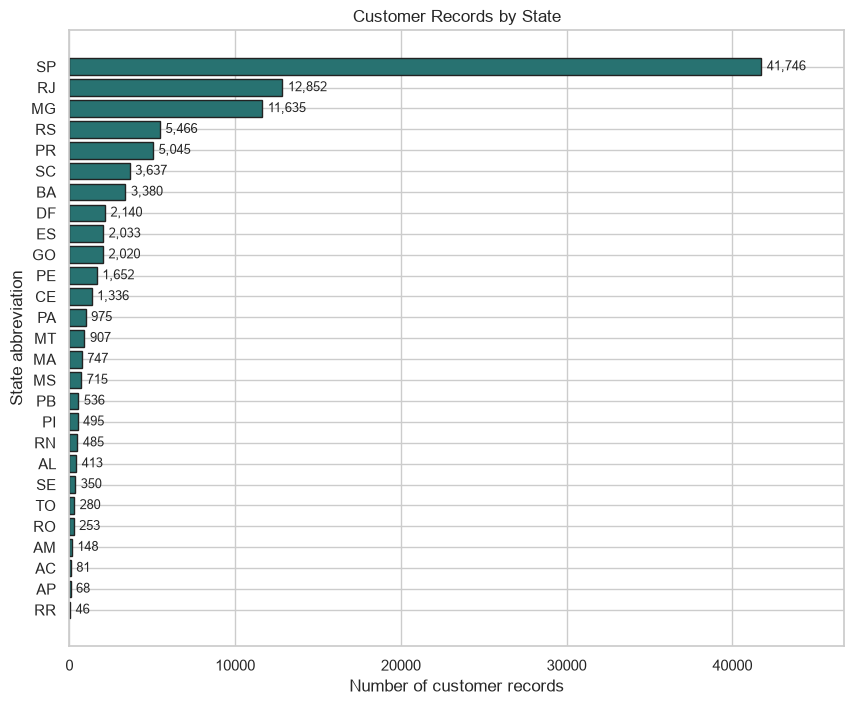

In [19]:
customer_state_counts = customers_clean["customer_state"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(customer_state_counts.index, customer_state_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR)
label_horizontal_bars(ax, bars)
ax.set_title("Customer Records by State")
ax.set_xlabel("Number of customer records")
ax.set_ylabel("State abbreviation")
save_figure(fig, "customer_counts_by_state.png")

**Observation.** Customer records are geographically concentrated: SP has **41,746**, followed by RJ with 12,852 and MG with 11,635. This describes representation in the customer table only and does not indicate late-delivery risk.

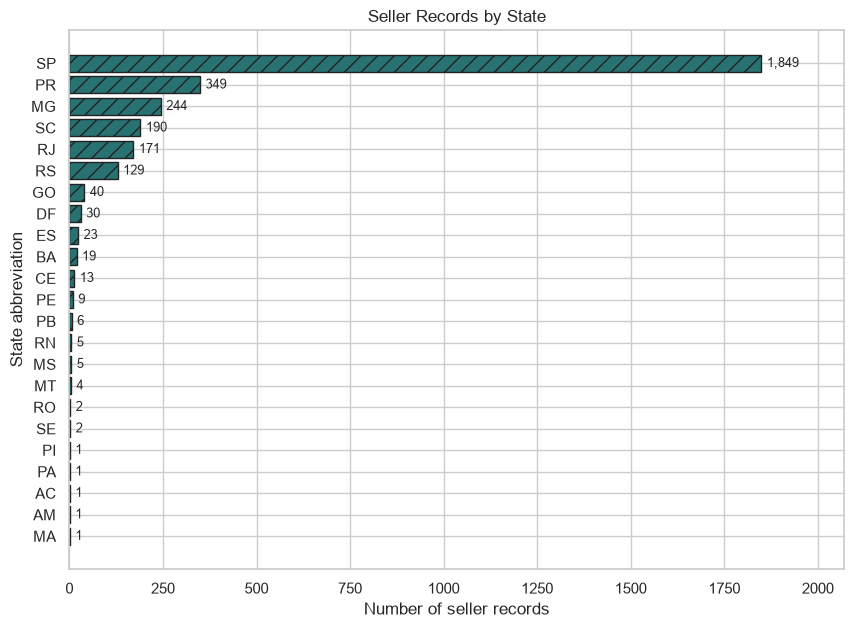

In [20]:
seller_state_counts = sellers_clean["seller_state"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(seller_state_counts.index, seller_state_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
label_horizontal_bars(ax, bars)
ax.set_title("Seller Records by State")
ax.set_xlabel("Number of seller records")
ax.set_ylabel("State abbreviation")
save_figure(fig, "seller_counts_by_state.png")

**Observation.** Sellers are more concentrated in SP, which contains **1,849 of 3,095 sellers**. PR is second with 349 and MG third with 244; four valid Brazilian states have no seller record in this table.

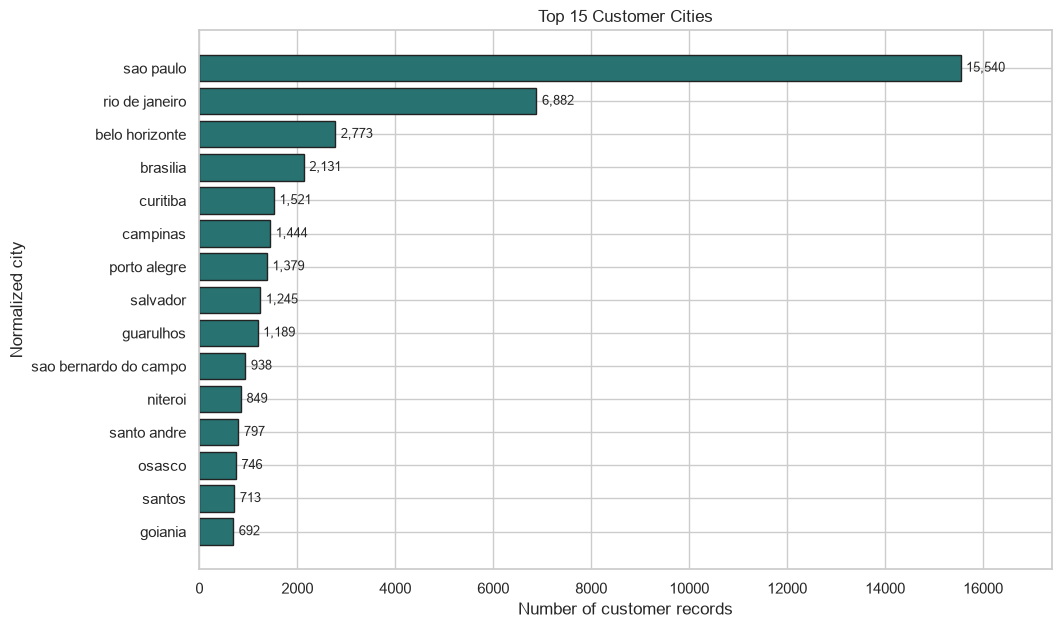

In [21]:
top_customer_cities = customers_clean["customer_city"].value_counts().head(15).sort_values()
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_customer_cities.index, top_customer_cities.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR)
label_horizontal_bars(ax, bars)
ax.set_title("Top 15 Customer Cities")
ax.set_xlabel("Number of customer records")
ax.set_ylabel("Normalized city")
save_figure(fig, "top_15_customer_cities.png")

**Observation.** Sao Paulo leads with **15,540 customer records**, more than twice Rio de Janeiro's 6,882. The chart is intentionally limited to 15 cities so labels remain readable; the customer table contains 4,119 distinct normalized cities.

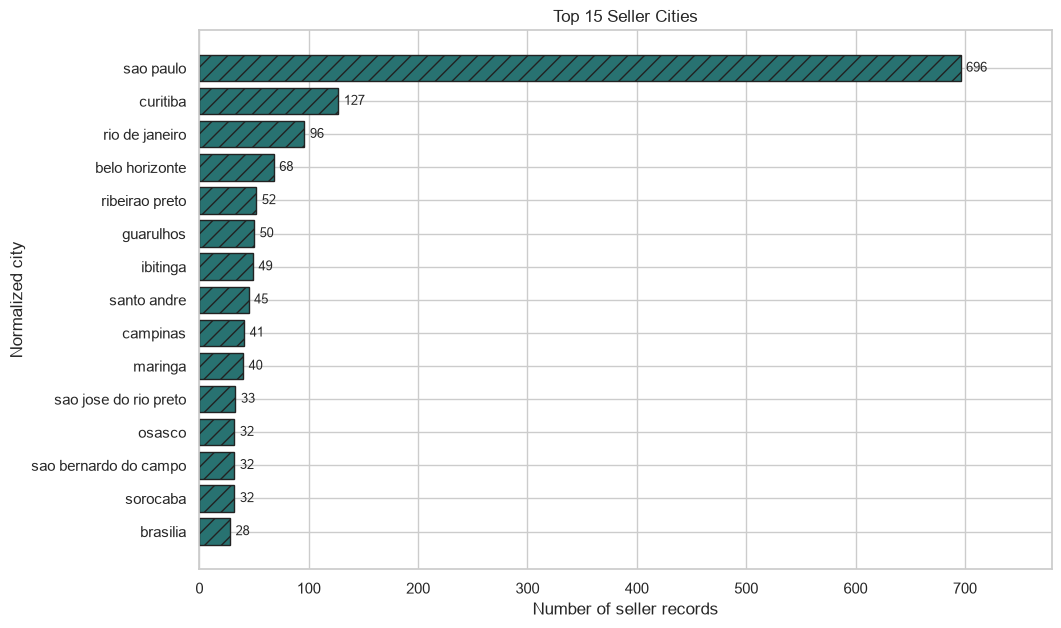

In [22]:
top_seller_cities = sellers_clean["seller_city"].value_counts().head(15).sort_values()
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_seller_cities.index, top_seller_cities.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
label_horizontal_bars(ax, bars)
ax.set_title("Top 15 Seller Cities")
ax.set_xlabel("Number of seller records")
ax.set_ylabel("Normalized city")
save_figure(fig, "top_15_seller_cities.png")

**Observation.** Sao Paulo contains **694 seller records**, well above Curitiba with 127 and Rio de Janeiro with 96. Only the top 15 of 606 normalized seller cities are displayed.

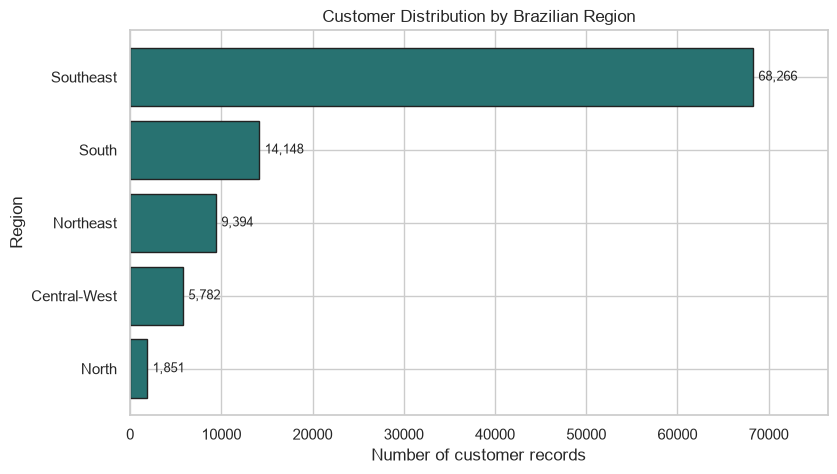

In [23]:
customer_region_counts = customers_clean["customer_region"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(customer_region_counts.index, customer_region_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR)
label_horizontal_bars(ax, bars)
ax.set_title("Customer Distribution by Brazilian Region")
ax.set_xlabel("Number of customer records")
ax.set_ylabel("Region")
save_figure(fig, "customer_distribution_by_region.png")

**Observation.** The Southeast accounts for **68,266 customer records**, followed by the South with 14,148. The North has the smallest representation with 1,851 records.

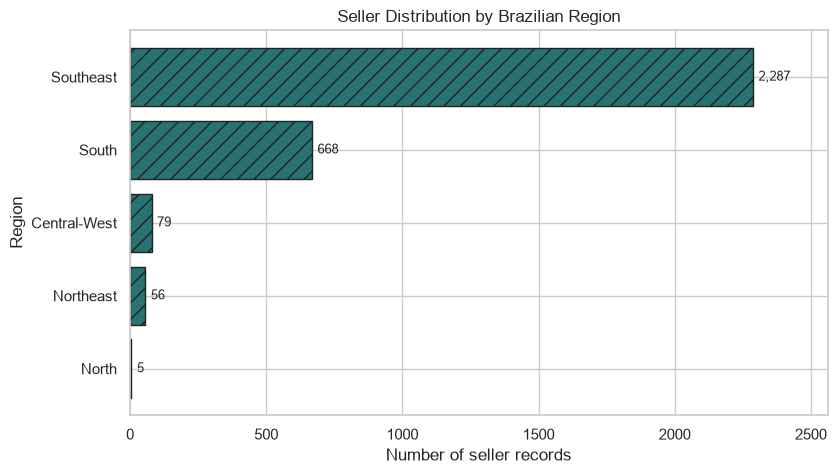

In [24]:
seller_region_counts = sellers_clean["seller_region"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(seller_region_counts.index, seller_region_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
label_horizontal_bars(ax, bars)
ax.set_title("Seller Distribution by Brazilian Region")
ax.set_xlabel("Number of seller records")
ax.set_ylabel("Region")
save_figure(fig, "seller_distribution_by_region.png")

**Observation.** The Southeast contains **2,287 sellers**, while the South contains 668. Only 5 sellers are located in the North, showing substantial regional imbalance in seller representation.

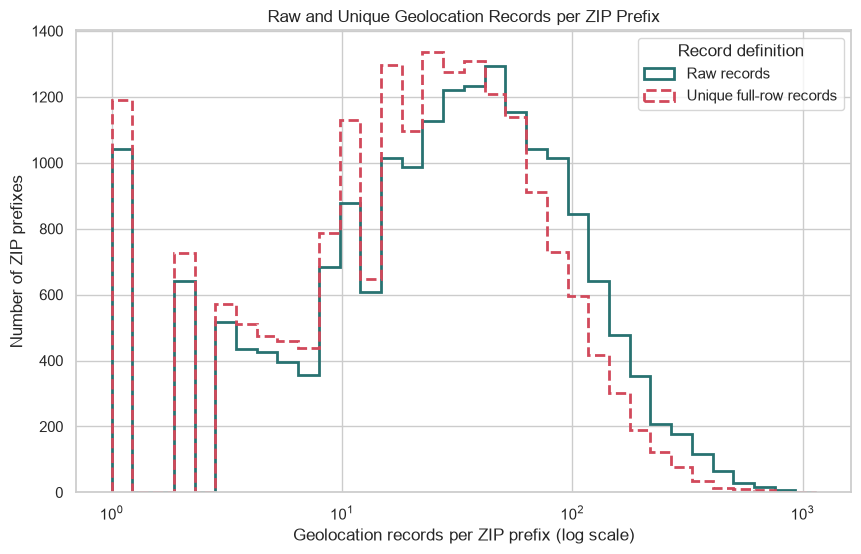

In [25]:
raw_zip_record_distribution = geolocation_zip_clean["geo_raw_record_count"]
unique_zip_record_distribution = geolocation_zip_clean["geo_unique_record_count"]
log_bins = np.logspace(0, np.log10(raw_zip_record_distribution.max()), 35)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(raw_zip_record_distribution, bins=log_bins, histtype="step", linewidth=2, color=PRIMARY_COLOR, label="Raw records")
ax.hist(unique_zip_record_distribution, bins=log_bins, histtype="step", linewidth=2, linestyle="--", color=SECONDARY_COLOR, label="Unique full-row records")
ax.set_xscale("log")
ax.set_title("Raw and Unique Geolocation Records per ZIP Prefix")
ax.set_xlabel("Geolocation records per ZIP prefix (log scale)")
ax.set_ylabel("Number of ZIP prefixes")
ax.legend(title="Record definition")
save_figure(fig, "geolocation_records_per_zip_prefix.png")

**Observation.** Both distributions are shown so source volume remains distinguishable from unique evidence after exact deduplication. The logarithmic x-axis keeps sparse and highly repeated ZIP prefixes visible without allowing a few large counts to dominate the chart.

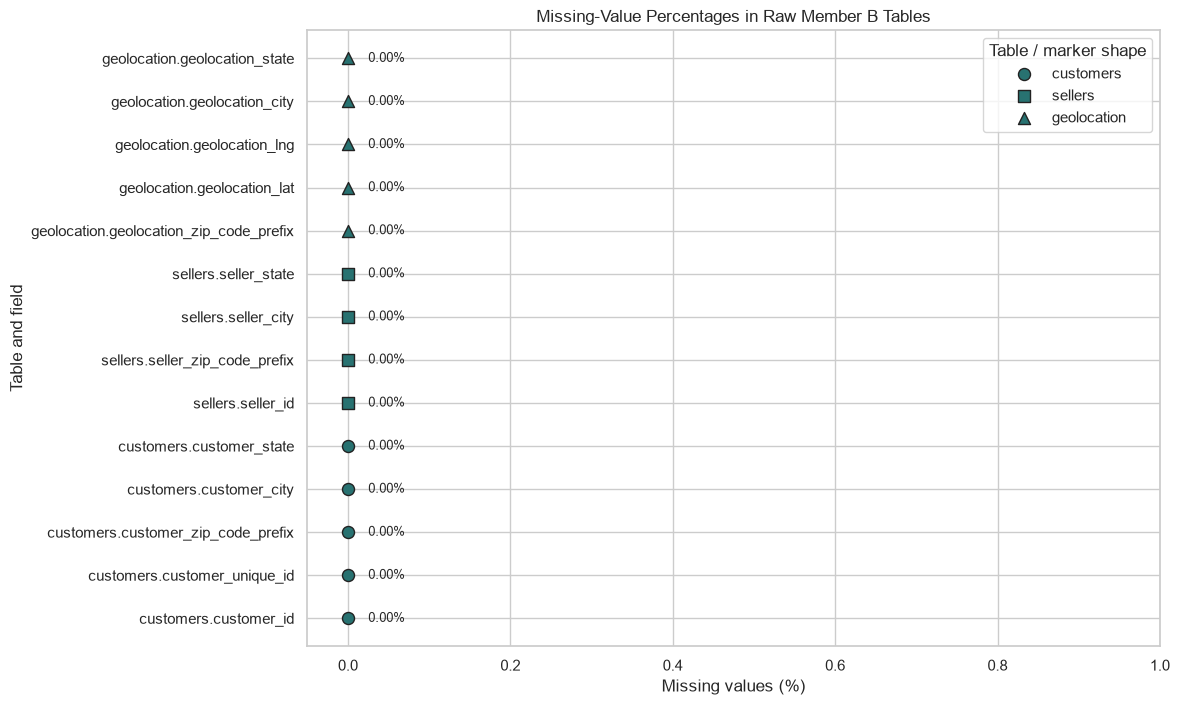

In [26]:
missing_plot = missing_summary.reset_index().copy()
missing_plot["field"] = missing_plot["table"] + "." + missing_plot["column"]
marker_by_table = {"customers": "o", "sellers": "s", "geolocation": "^"}

fig, ax = plt.subplots(figsize=(11, 8))
for table_name, table_data in missing_plot.groupby("table", sort=False):
    positions = table_data.index.to_numpy()
    ax.scatter(
        table_data["missing_percentage"],
        positions,
        marker=marker_by_table[table_name],
        s=75,
        color=PRIMARY_COLOR,
        edgecolor=EDGE_COLOR,
        label=table_name,
        zorder=3,
    )
    for percentage, position in zip(table_data["missing_percentage"], positions):
        ax.text(percentage + 0.025, position, f"{percentage:.2f}%", va="center", fontsize=9)
ax.set_yticks(missing_plot.index, missing_plot["field"])
ax.set_xlim(-0.05, 1.0)
ax.set_title("Missing-Value Percentages in Raw Member B Tables")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Table and field")
ax.legend(title="Table / marker shape")
save_figure(fig, "missing_value_percentages.png")

**Observation.** Every audited source column has **0.00% missing values**. This source-level completeness is separate from ZIP enrichment coverage, where unmatched prefixes can still produce missing coordinates.

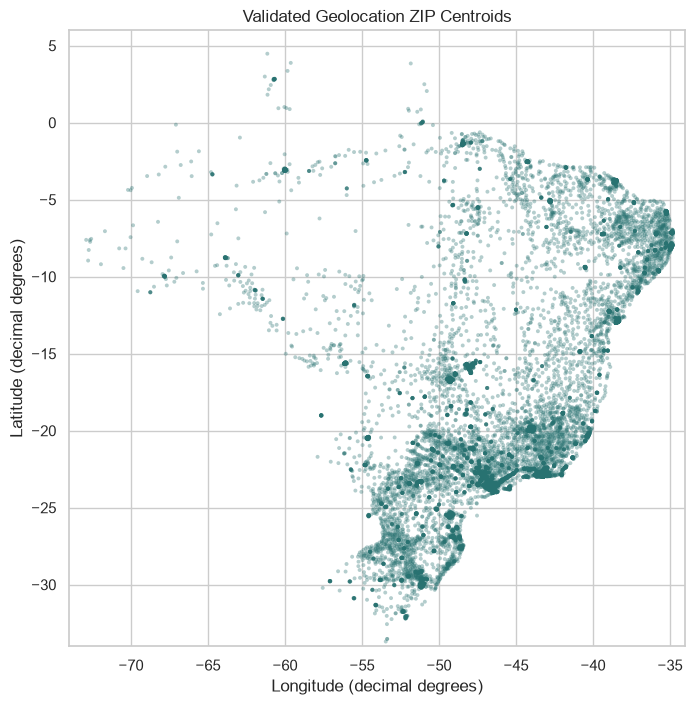

In [27]:
valid_zip_centroids = geolocation_zip_clean.dropna(subset=["geolocation_lat", "geolocation_lng"])
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(
    valid_zip_centroids["geolocation_lng"],
    valid_zip_centroids["geolocation_lat"],
    s=8,
    alpha=0.35,
    color=PRIMARY_COLOR,
    edgecolors="none",
    marker="o",
)
ax.set_xlim(LONGITUDE_MIN, LONGITUDE_MAX)
ax.set_ylim(LATITUDE_MIN, LATITUDE_MAX)
ax.set_title("Validated Geolocation ZIP Centroids")
ax.set_xlabel("Longitude (decimal degrees)")
ax.set_ylabel("Latitude (decimal degrees)")
ax.set_aspect("equal", adjustable="box")
save_figure(fig, "geolocation_latitude_longitude_scatter.png")

**Observation.** The scatter displays **19,010 ZIP centroids with valid coordinates** inside the selected Brazilian bounds. Dense clusters indicate where the source contains more ZIP-prefix centroids; the plot does not measure orders, customers, sellers, or delivery outcomes.

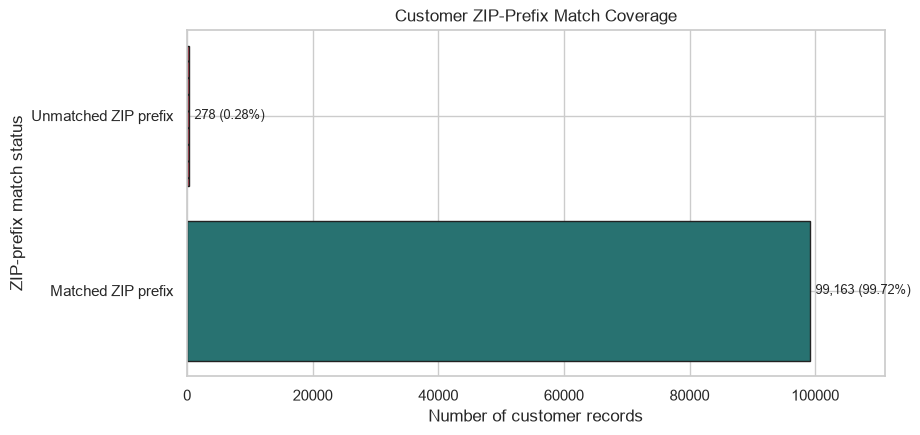

In [28]:
customer_zip_matched = customers_geo_clean["customer_geo_raw_record_count"].notna()
customer_coverage_counts = pd.Series(
    {"Matched ZIP prefix": int(customer_zip_matched.sum()), "Unmatched ZIP prefix": int((~customer_zip_matched).sum())}
)
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(
    customer_coverage_counts.index,
    customer_coverage_counts.values,
    color=[PRIMARY_COLOR, SECONDARY_COLOR],
    edgecolor=EDGE_COLOR,
    hatch=["", "//"],
)
total_customers = customer_coverage_counts.sum()
label_horizontal_bars(ax, bars, lambda value: f"{int(value):,} ({value / total_customers:.2%})")
ax.set_title("Customer ZIP-Prefix Match Coverage")
ax.set_xlabel("Number of customer records")
ax.set_ylabel("ZIP-prefix match status")
save_figure(fig, "customer_zip_match_coverage.png")

**Observation.** **99,163 of 99,441 customer rows (99.72%)** find a ZIP prefix in the geolocation lookup. **278 customer records have ZIP prefixes that do not match the ZIP-level geolocation lookup.** One additional customer record matched a ZIP lookup row whose valid centroid coordinates are unavailable, which is why **279 customer records lack coordinates**.

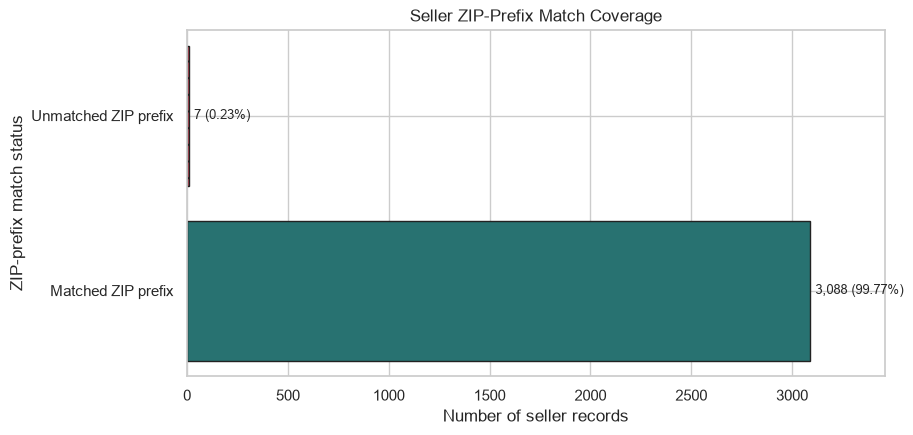

In [29]:
seller_zip_matched = sellers_geo_clean["seller_geo_raw_record_count"].notna()
seller_coverage_counts = pd.Series(
    {"Matched ZIP prefix": int(seller_zip_matched.sum()), "Unmatched ZIP prefix": int((~seller_zip_matched).sum())}
)
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(
    seller_coverage_counts.index,
    seller_coverage_counts.values,
    color=[PRIMARY_COLOR, SECONDARY_COLOR],
    edgecolor=EDGE_COLOR,
    hatch=["", "//"],
)
total_sellers = seller_coverage_counts.sum()
label_horizontal_bars(ax, bars, lambda value: f"{int(value):,} ({value / total_sellers:.2%})")
ax.set_title("Seller ZIP-Prefix Match Coverage")
ax.set_xlabel("Number of seller records")
ax.set_ylabel("ZIP-prefix match status")
save_figure(fig, "seller_zip_match_coverage.png")

**Observation.** **3,088 of 3,095 seller rows (99.77%)** find a ZIP prefix in the geolocation lookup, leaving 7 unmatched seller rows. This is descriptive coverage information only.

## 17. Order-Level Geographic Feature Engineering

The raw orders and order-items files are used strictly as relationship bridges. Only `order_id` and `customer_id` are read from orders, and only `order_id` and `seller_id` are read from order items. No status, timestamp, target, product, price, freight, or item-characteristic field is loaded or transformed. Raw bridge files remain read-only.

### 17.1 Load and Audit Permitted Bridge Columns

Bridge tables are loaded with explicit `usecols` restrictions and string identifiers. Their keys and missingness are checked before any relationship is used.

In [30]:
ORDERS_BRIDGE_PATH = RAW_DIR / "olist_orders_dataset.csv"
ORDER_ITEMS_BRIDGE_PATH = RAW_DIR / "olist_order_items_dataset.csv"

orders_bridge = pd.read_csv(
    ORDERS_BRIDGE_PATH,
    usecols=["order_id", "customer_id"],
    dtype={"order_id": "string", "customer_id": "string"},
)
order_items_bridge = pd.read_csv(
    ORDER_ITEMS_BRIDGE_PATH,
    usecols=["order_id", "seller_id"],
    dtype={"order_id": "string", "seller_id": "string"},
)

bridge_audit = pd.DataFrame(
    [
        {
            "table": "orders_bridge",
            "rows": len(orders_bridge),
            "unique_order_ids": orders_bridge["order_id"].nunique(dropna=False),
            "order_id_is_unique": orders_bridge["order_id"].is_unique,
            "missing_order_ids": int(orders_bridge["order_id"].isna().sum()),
            "missing_relationship_ids": int(orders_bridge["customer_id"].isna().sum()),
        },
        {
            "table": "order_items_bridge",
            "rows": len(order_items_bridge),
            "unique_order_ids": order_items_bridge["order_id"].nunique(dropna=False),
            "order_id_is_unique": order_items_bridge["order_id"].is_unique,
            "missing_order_ids": int(order_items_bridge["order_id"].isna().sum()),
            "missing_relationship_ids": int(order_items_bridge["seller_id"].isna().sum()),
        },
    ]
).set_index("table")
display(bridge_audit)

,rows,unique_order_ids,order_id_is_unique,missing_order_ids,missing_relationship_ids
table,,,,,
orders_bridge,99441,99441,True,0,0
order_items_bridge,112650,98666,False,0,0


**Interpretation.** The orders bridge contains **99,441 rows and 99,441 unique order IDs**. The order-items bridge contains **112,650 rows across 98,666 orders**, so its order IDs appropriately repeat. Neither bridge contains a missing order, customer, or seller identifier.

### 17.2 Unique Order-Seller Relationships

Repeated `order_id`-`seller_id` pairs are removed in a new bridge copy. This prevents a seller from being counted multiple times only because it supplied multiple item rows. The raw `order_items_bridge` DataFrame is not modified.

In [31]:
repeated_order_seller_rows = int(
    order_items_bridge.duplicated(subset=["order_id", "seller_id"], keep="first").sum()
)
unique_order_seller_bridge = (
    order_items_bridge
    .drop_duplicates(subset=["order_id", "seller_id"])
    .copy()
)

order_seller_dedup_audit = pd.Series(
    {
        "raw_order_item_bridge_rows": len(order_items_bridge),
        "repeated_order_seller_rows_removed": repeated_order_seller_rows,
        "unique_order_seller_rows": len(unique_order_seller_bridge),
        "unique_orders_with_sellers": unique_order_seller_bridge["order_id"].nunique(),
        "missing_order_ids_after_deduplication": int(unique_order_seller_bridge["order_id"].isna().sum()),
        "missing_seller_ids_after_deduplication": int(unique_order_seller_bridge["seller_id"].isna().sum()),
    },
    name="unique_order_seller_bridge",
).to_frame("count")
display(order_seller_dedup_audit)

,count
raw_order_item_bridge_rows,112650
repeated_order_seller_rows_removed,12640
unique_order_seller_rows,100010
unique_orders_with_sellers,98666
missing_order_ids_after_deduplication,0
missing_seller_ids_after_deduplication,0


**Interpretation.** Deduplication removes **12,640 repeated order-seller rows**, leaving **100,010 unique order-seller relationships across 98,666 orders**. It changes only the temporary relationship bridge used for seller counting; it does not alter Member C's item-level data or summarize products, prices, freight, or quantities.

### 17.3 Validated Geographic Joins

Orders are joined to cleaned customer geography with a one-to-one validation. Unique order-seller relationships are joined to cleaned seller geography with a many-to-one validation, then linked to the order-level customer geography with another many-to-one validation. Row counts are recorded before and after every join.

In [32]:
customer_order_lookup = customers_geo_clean[
    [
        "customer_id",
        "customer_state",
        "customer_region",
        "customer_latitude",
        "customer_longitude",
        "customer_geolocation_missing",
    ]
].copy()
seller_order_lookup = sellers_geo_clean[
    [
        "seller_id",
        "seller_state",
        "seller_region",
        "seller_latitude",
        "seller_longitude",
        "seller_geolocation_missing",
    ]
].copy()

order_customer_geo = orders_bridge.merge(
    customer_order_lookup,
    on="customer_id",
    how="left",
    validate="one_to_one",
)
order_seller_geo = unique_order_seller_bridge.merge(
    seller_order_lookup,
    on="seller_id",
    how="left",
    validate="many_to_one",
)
order_seller_geo = order_seller_geo.merge(
    order_customer_geo[
        [
            "order_id",
            "customer_state",
            "customer_region",
            "customer_latitude",
            "customer_longitude",
            "customer_geolocation_missing",
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one",
)

bridge_join_audit = pd.DataFrame(
    [
        {
            "join": "orders -> customer geography",
            "rows_before": len(orders_bridge),
            "rows_after": len(order_customer_geo),
            "row_change": len(order_customer_geo) - len(orders_bridge),
            "validation": "one_to_one",
        },
        {
            "join": "unique order-seller -> seller geography",
            "rows_before": len(unique_order_seller_bridge),
            "rows_after": len(order_seller_geo),
            "row_change": len(order_seller_geo) - len(unique_order_seller_bridge),
            "validation": "many_to_one",
        },
        {
            "join": "order-seller geography -> customer geography",
            "rows_before": len(unique_order_seller_bridge),
            "rows_after": len(order_seller_geo),
            "row_change": len(order_seller_geo) - len(unique_order_seller_bridge),
            "validation": "many_to_one",
        },
    ]
).set_index("join")

assert len(order_customer_geo) == len(orders_bridge)
assert len(order_seller_geo) == len(unique_order_seller_bridge)
display(bridge_join_audit)

,rows_before,rows_after,row_change,validation
join,,,,
orders -> customer geography,99441,99441,0,one_to_one
unique order-seller -> seller geography,100010,100010,0,many_to_one
order-seller geography -> customer geography,100010,100010,0,many_to_one


**Interpretation.** The customer join preserves all **99,441 order rows**. Both seller-side joins preserve all **100,010 unique order-seller rows**. Every validated join therefore has a row change of zero, preventing accidental order or seller duplication.

### 17.4 Seller-Level Geographic Features

Vectorized Haversine distance calculates the great-circle separation between customer and seller ZIP centroids using Earth's mean radius. It is a straight-line geographic proxy, not road distance, route length, travel time, or logistics cost. Distances remain missing when either endpoint is unavailable.

State and region comparisons use pandas nullable booleans. A comparison is true or false only when both labels are known; missing labels remain unknown and are never treated as cross-state or cross-region.

In [33]:
EARTH_MEAN_RADIUS_KM = 6_371.0088


def haversine_distance_km(lat1, lon1, lat2, lon2):
    valid = lat1.notna() & lon1.notna() & lat2.notna() & lon2.notna()
    phi1 = np.radians(lat1.astype(float))
    phi2 = np.radians(lat2.astype(float))
    delta_phi = np.radians(lat2.astype(float) - lat1.astype(float))
    delta_lambda = np.radians(lon2.astype(float) - lon1.astype(float))
    haversine_a = (
        np.sin(delta_phi / 2.0) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0) ** 2
    )
    angular_distance = 2.0 * np.arcsin(np.sqrt(np.clip(haversine_a, 0.0, 1.0)))
    distance = EARTH_MEAN_RADIUS_KM * angular_distance
    return pd.Series(distance, index=lat1.index).where(valid)


same_state = pd.Series(pd.NA, index=order_seller_geo.index, dtype="boolean")
known_state_comparison = order_seller_geo["customer_state"].notna() & order_seller_geo["seller_state"].notna()
same_state.loc[known_state_comparison] = (
    order_seller_geo.loc[known_state_comparison, "customer_state"]
    == order_seller_geo.loc[known_state_comparison, "seller_state"]
)

same_region = pd.Series(pd.NA, index=order_seller_geo.index, dtype="boolean")
known_region_comparison = order_seller_geo["customer_region"].notna() & order_seller_geo["seller_region"].notna()
same_region.loc[known_region_comparison] = (
    order_seller_geo.loc[known_region_comparison, "customer_region"]
    == order_seller_geo.loc[known_region_comparison, "seller_region"]
)

order_seller_geo = order_seller_geo.assign(
    distance_km=haversine_distance_km(
        order_seller_geo["customer_latitude"],
        order_seller_geo["customer_longitude"],
        order_seller_geo["seller_latitude"],
        order_seller_geo["seller_longitude"],
    ),
    same_state=same_state,
    same_region=same_region,
    missing_customer_coordinates=(
        order_seller_geo["customer_latitude"].isna()
        | order_seller_geo["customer_longitude"].isna()
    ),
    missing_seller_coordinates=(
        order_seller_geo["seller_latitude"].isna()
        | order_seller_geo["seller_longitude"].isna()
    ),
)
order_seller_geo = order_seller_geo.assign(
    missing_distance=order_seller_geo["distance_km"].isna()
)

seller_level_geo_audit = pd.Series(
    {
        "unique_order_seller_rows": len(order_seller_geo),
        "distance_available_rows": int(order_seller_geo["distance_km"].notna().sum()),
        "missing_distance_rows": int(order_seller_geo["missing_distance"].sum()),
        "unknown_state_comparisons": int(order_seller_geo["same_state"].isna().sum()),
        "unknown_region_comparisons": int(order_seller_geo["same_region"].isna().sum()),
    },
    name="seller_level_geography",
).to_frame("count")
display(seller_level_geo_audit)

,count
unique_order_seller_rows,100010
distance_available_rows,99510
missing_distance_rows,500
unknown_state_comparisons,0
unknown_region_comparisons,0


**Interpretation.** Haversine distance is available for **99,510 of 100,010 order-seller relationships**; 500 remain missing because at least one coordinate endpoint is unavailable. All state and region labels required for seller-level comparisons are present, so there are zero unknown comparisons at this stage. Missing coordinate pairs remain missing rather than being assigned a distance.

### 17.5 One Row per Order

Seller-level rows are aggregated after order-seller deduplication. Nullable `any` and `all` logic preserves uncertainty: for example, all-sellers-same-state is false when any known seller is cross-state, true only when every comparison is known and true, and otherwise remains missing. Orders without an order-seller relationship receive seller counts of zero while seller comparison and distance fields remain unavailable.

In [34]:
def nullable_any(series: pd.Series):
    return series.astype("boolean").any(skipna=False)


def nullable_all(series: pd.Series):
    return series.astype("boolean").all(skipna=False)


seller_geography_by_order = (
    order_seller_geo
    .groupby("order_id", as_index=False, dropna=False)
    .agg(
        geographic_seller_count=("seller_id", "nunique"),
        distinct_seller_states=("seller_state", "nunique"),
        distinct_seller_regions=("seller_region", "nunique"),
        any_seller_same_state=("same_state", nullable_any),
        all_sellers_same_state=("same_state", nullable_all),
        any_seller_same_region=("same_region", nullable_any),
        all_sellers_same_region=("same_region", nullable_all),
        minimum_distance_km=("distance_km", "min"),
        average_distance_km=("distance_km", "mean"),
        maximum_distance_km=("distance_km", "max"),
        missing_seller_coordinates=("missing_seller_coordinates", "any"),
    )
)

order_geo_features = order_customer_geo[
    [
        "order_id",
        "customer_state",
        "customer_region",
        "customer_geolocation_missing",
    ]
].rename(columns={"customer_geolocation_missing": "missing_customer_coordinates"})
order_geo_features = order_geo_features.merge(
    seller_geography_by_order,
    on="order_id",
    how="left",
    validate="one_to_one",
)

count_columns = ["geographic_seller_count", "distinct_seller_states", "distinct_seller_regions"]
order_geo_features[count_columns] = order_geo_features[count_columns].fillna(0).astype("int64")
nullable_boolean_columns = [
    "any_seller_same_state",
    "all_sellers_same_state",
    "any_seller_same_region",
    "all_sellers_same_region",
    "missing_seller_coordinates",
]
order_geo_features[nullable_boolean_columns] = order_geo_features[nullable_boolean_columns].astype("boolean")
order_geo_features["missing_customer_coordinates"] = order_geo_features["missing_customer_coordinates"].astype("boolean")

order_geo_features = order_geo_features[
    [
        "order_id",
        "customer_state",
        "customer_region",
        "geographic_seller_count",
        "distinct_seller_states",
        "distinct_seller_regions",
        "any_seller_same_state",
        "all_sellers_same_state",
        "any_seller_same_region",
        "all_sellers_same_region",
        "minimum_distance_km",
        "average_distance_km",
        "maximum_distance_km",
        "missing_customer_coordinates",
        "missing_seller_coordinates",
    ]
]

orders_with_missing_distance = order_geo_features["average_distance_km"].isna()
order_geo_validation = pd.Series(
    {
        "final_rows": len(order_geo_features),
        "unique_order_ids": order_geo_features["order_id"].nunique(dropna=False),
        "order_id_is_unique": order_geo_features["order_id"].is_unique,
        "row_change_from_orders_bridge": len(order_geo_features) - len(orders_bridge),
        "orders_with_zero_geographic_sellers": int(order_geo_features["geographic_seller_count"].eq(0).sum()),
        "orders_with_missing_distance": int(orders_with_missing_distance.sum()),
        "orders_with_missing_distance_percentage": orders_with_missing_distance.mean() * 100,
        "orders_with_missing_customer_coordinates": int(order_geo_features["missing_customer_coordinates"].sum()),
        "orders_with_missing_seller_coordinates": int(order_geo_features["missing_seller_coordinates"].fillna(False).sum()),
    },
    name="order_geo_features",
).to_frame("value")

assert len(order_geo_features) == len(orders_bridge)
assert order_geo_features["order_id"].is_unique
assert order_geo_features["order_id"].notna().all()
display(order_geo_validation)
order_distance_summary = order_geo_features[
    ["minimum_distance_km", "average_distance_km", "maximum_distance_km"]
].describe(percentiles=[0.25, 0.50, 0.75, 0.95]).transpose()
display(order_distance_summary)
order_geo_missingness = pd.DataFrame(
    {
        "missing_count": order_geo_features.isna().sum(),
        "missing_percentage": order_geo_features.isna().mean().mul(100),
    }
)
display(order_geo_missingness)
display(order_geo_features.head())

,value
final_rows,99441
unique_order_ids,99441
order_id_is_unique,True
row_change_from_orders_bridge,0
orders_with_zero_geographic_sellers,775
orders_with_missing_distance,1265
orders_with_missing_distance_percentage,1.2721
orders_with_missing_customer_coordinates,279
orders_with_missing_seller_coordinates,220


,count,mean,std,min,25%,50%,75%,95%,max
minimum_distance_km,"98,176.0000",600.0630,593.7508,0.0000,182.0561,431.8246,797.1754,"2,097.6185","3,579.2670"
average_distance_km,"98,176.0000",601.3627,593.6499,0.0000,186.4974,433.8321,798.0737,"2,098.4722","3,579.2670"
maximum_distance_km,"98,176.0000",602.6679,594.1333,0.0000,188.1690,435.3821,800.7876,"2,099.7929","3,579.2670"


,missing_count,missing_percentage
order_id,0,0.0000
customer_state,0,0.0000
customer_region,0,0.0000
geographic_seller_count,0,0.0000
distinct_seller_states,0,0.0000
distinct_seller_regions,0,0.0000
any_seller_same_state,775,0.7794
all_sellers_same_state,775,0.7794
any_seller_same_region,775,0.7794
all_sellers_same_region,775,0.7794


,order_id,customer_state,customer_region,geographic_seller_count,distinct_seller_states,distinct_seller_regions,any_seller_same_state,all_sellers_same_state,any_seller_same_region,all_sellers_same_region,minimum_distance_km,average_distance_km,maximum_distance_km,missing_customer_coordinates,missing_seller_coordinates
0,e481f51cbdc54678b7cc49136f2d6af7,SP,Southeast,1,1,1,True,True,True,True,18.6766,18.6766,18.6766,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,BA,Northeast,1,1,1,False,False,False,False,861.0699,861.0699,861.0699,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,GO,Central-West,1,1,1,False,False,False,False,514.5358,514.5358,514.5358,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,Northeast,1,1,1,False,False,False,False,"1,821.8742","1,821.8742","1,821.8742",False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,Southeast,1,1,1,True,True,True,True,29.6232,29.6232,29.6232,False,False


**Interpretation.** The final in-memory table contains **99,441 rows and 99,441 unique order IDs**, with no row change from the orders bridge. There are **775 orders with no geographic seller relationship**. Average distance is missing for **1,265 orders (1.2721%)**; 279 orders have missing customer coordinates and 220 linked orders have at least one seller with missing coordinates. Seller comparison fields remain explicitly missing for the 775 orders without a seller relationship.

### 17.6 Domain-Based Preliminary Feature Decisions

This subsection documents Member B's **domain-based preliminary decisions** using only fields that exist in this notebook. These decisions control what is handed downstream; they are not target-based or model-based feature selection. Member A's approved target is used only for descriptive EDA in Section 18 and is not recreated here or used for automatic feature selection. Final statistical selection must be performed after the chronological split, using training data only and considering model performance, stability, multicollinearity, and validation evidence.

| Feature or field | Role | Decision | Justification | Availability at prediction time | Downstream preprocessing |
|---|---|---|---|---|---|
|`order_id`|Order-level merge identifier|**Key-only**|Required to merge Member B features into the final order table; an arbitrary identifier has no generalizable predictive meaning.|Available with the order.|Exclude from the model feature matrix.|
|`customer_state`|Customer location category|**Retain**|Interpretable coarse geography and the source for state comparisons. Retention is provisional because it overlaps with region and distance.|Available from the customer's order-linked location before outcome information.|Fit categorical encoding on training data only; preserve an unknown category.|
|`customer_region`|Customer macro-region category|**Retain**|Lower-cardinality geographic context that may generalize better than state. It overlaps hierarchically with customer state.|Derived from customer state before outcome information.|Fit categorical encoding on training data only; review redundancy with state.|
|`geographic_seller_count`|Number of distinct sellers linked to an order|**Retain**|Captures geographic relationship complexity after repeated order-seller item rows are removed.|Available once sellers are assigned to the order; prediction timing must be defined accordingly.|Consider train-only scaling or transformation if required by the selected model.|
|`distinct_seller_states`|Seller geographic-diversity count|**Retain**|Summarizes state-level seller dispersion without exposing raw seller identifiers.|Available once sellers are assigned to the order.|Review distribution and overlap with seller count; scale only if the model requires it.|
|`distinct_seller_regions`|Seller macro-region-diversity count|**Retain**|Provides a coarser diversity measure than distinct states.|Available once sellers are assigned to the order.|Review overlap with distinct seller states and seller count using training data.|
|`any_seller_same_state`|Nullable state-agreement indicator|**Retain**|Distinguishes orders having at least one seller in the customer state while preserving unknown comparisons.|Available from customer and assigned-seller geography.|Encode nullable boolean after splitting; handle missing values using a training-only strategy.|
|`all_sellers_same_state`|Nullable state-agreement indicator|**Retain**|Identifies orders whose known sellers are all in the customer state. It may overlap strongly with the corresponding any-state indicator for single-seller orders.|Available from customer and assigned-seller geography.|Encode nullable boolean after splitting; review overlap rather than deleting automatically.|
|`any_seller_same_region`|Nullable region-agreement indicator|**Retain**|Captures at least one seller in the same macro-region and is less granular than state agreement.|Available from customer and assigned-seller geography.|Encode nullable boolean after splitting; handle missing values using training data only.|
|`all_sellers_same_region`|Nullable region-agreement indicator|**Retain**|Captures whether all known sellers share the customer's macro-region. It can overlap with state indicators and with any-region for single-seller orders.|Available from customer and assigned-seller geography.|Encode nullable boolean after splitting; review redundancy using training evidence.|
|`minimum_distance_km`|Nearest seller Haversine-distance summary|**Retain**|Represents the closest straight-line customer-seller separation for multi-seller orders.|Available from static ZIP centroids after sellers are assigned.|Retain missingness; fit imputation and scaling on training data only if required.|
|`average_distance_km`|Mean seller Haversine-distance summary|**Retain**|Provides the central order-level distance measure and uses all available seller links.|Available from static ZIP centroids after sellers are assigned.|Consider train-only imputation, scaling, or skew transformation after inspecting the training distribution.|
|`maximum_distance_km`|Farthest seller Haversine-distance summary|**Retain**|Represents the longest straight-line seller separation within an order.|Available from static ZIP centroids after sellers are assigned.|Retain missingness; review correlation with minimum and average distance downstream.|
|`missing_customer_coordinates`|Customer-geolocation quality indicator|**Retain**|Makes unavailable customer coordinates explicit instead of replacing them with zero.|Available when the customer ZIP lookup is performed.|Encode as boolean; coordinate imputation, if used, must be fitted on training data only.|
|`missing_seller_coordinates`|Nullable seller-geolocation quality indicator|**Retain**|Identifies linked orders with unavailable seller coordinates and remains missing for orders without a seller relationship.|Available when seller ZIP lookups are performed.|Preserve the distinction between missing coordinates and no seller relationship; resolve encoding after the split.|
|`customer_zip_code_prefix`<br>`seller_zip_code_prefix`<br>`geolocation_zip_code_prefix`|Geolocation join keys|**Key-only**|Needed to construct centroids and enrich entities, but raw ZIP prefixes are high-cardinality identifiers. Direct modelling risks sparsity, memorization, unstable rare levels, and misleading numeric ordinality.|Available before outcome information.|Exclude from the baseline feature matrix. If reconsidered, use a train-fitted, leakage-safe encoding with explicit unknown handling.|
|`customer_id`<br>`seller_id`|Relationship keys|**Key-only**|Needed to connect permitted bridge tables to cleaned geography; identifiers should not act as predictors.|Available with the order relationships.|Exclude from the model feature matrix.|
|`customer_city`<br>`seller_city`<br>`geolocation_city`|Normalized city labels|**Exclude**|Cities are high-cardinality, include rare labels, and can encourage memorization or unstable encodings. Their useful spatial information is represented more robustly by state, region, and distance features.|Available before outcome information.|Not passed as baseline predictors. Any later reconsideration requires train-only encoding and rare-category handling.|
|`seller_state`<br>`seller_region`|Seller-level categories before order aggregation|**Exclude**|A multi-seller order cannot be represented by one raw seller label without arbitrary row selection. Their information is summarized by diversity counts and same-location indicators.|Available once sellers are assigned.|Do not pass raw seller labels at order grain; use the engineered aggregates.|
|`geolocation_state`<br>`geolocation_region`|ZIP-centroid location labels|**Diagnostic-only**|Used to validate the ZIP lookup and derive entity regions, but not included directly in the final order-level table.|Available when the static geolocation lookup is built.|Retain in the lookup for audit and enrichment; do not add as duplicate order-level predictors.|
|`customer_latitude`<br>`customer_longitude`<br>`seller_latitude`<br>`seller_longitude`<br>`geolocation_lat`<br>`geolocation_lng`|Raw or enriched centroid coordinates|**Exclude**|Coordinates are intermediate inputs to Haversine distance. Passing them alongside states, regions, and distances adds strong overlap and lets a model learn location surfaces without an established need.|Available from the ZIP lookup.|Do not pass in the baseline feature set; reconsider only with spatial validation and training-only preprocessing.|
|`geo_raw_record_count`<br>`geo_unique_record_count`<br>`geo_exact_duplicates_removed`|ZIP-level duplication diagnostics|**Diagnostic-only**|Demonstrate source support and duplicate handling for each centroid but primarily measure lookup-table data quality rather than order geography.|Available when the static geolocation lookup is built.|Retain for validation and audit; do not pass to the baseline model.|
|`geolocation_valid_coordinate_count`<br>`geolocation_out_of_bounds_count`<br>`geolocation_city_count`<br>`geolocation_state_count`|ZIP-level coordinate and label-quality diagnostics|**Diagnostic-only**|Support centroid validation, conflict review, and reproducibility. They are not included in `order_geo_features`.|Available when the static geolocation lookup is built.|Retain in intermediate tables for audit; exclude from the baseline model unless a downstream training-only experiment justifies them.|

**High-cardinality fields.** Direct one-hot encoding of city or ZIP values would create sparse, unstable feature spaces with many rare levels. Treating ZIP prefixes as numbers would also introduce a false ordinal distance. These fields are therefore join-only or excluded from the baseline rather than encoded in this notebook.

**Overlapping geography.** State and region, minimum/average/maximum distance, any/all agreement indicators, and seller-count/diversity fields may be correlated or redundant. Member B retains the interpretable engineered candidates provisionally. Downstream work should quantify overlap using training data and model-specific evidence instead of deleting useful fields automatically. No encoding, scaling, imputation, splitting, resampling, model fitting, or target-based selection is performed here.

### 17.7 Descriptive Order-Geography Plots

The following plots are rendered in the notebook only and are not saved to disk. They describe engineered geographic features without using or making claims about the late-delivery target.

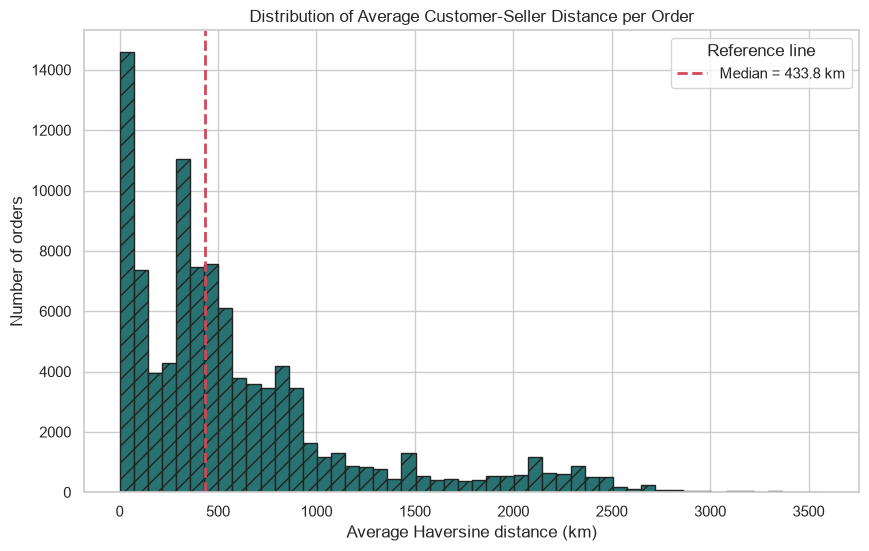

In [35]:
available_average_distances = order_geo_features["average_distance_km"].dropna()
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(available_average_distances, bins=50, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
distance_median = available_average_distances.median()
ax.axvline(distance_median, color=SECONDARY_COLOR, linestyle="--", linewidth=2, label=f"Median = {distance_median:,.1f} km")
ax.set_title("Distribution of Average Customer-Seller Distance per Order")
ax.set_xlabel("Average Haversine distance (km)")
ax.set_ylabel("Number of orders")
ax.legend(title="Reference line")
plt.show()
plt.close(fig)

**Observation.** The distribution summarizes straight-line geographic separation for **98,176 orders** with valid customer and seller coordinates. After exact deduplication, average order distance has a mean of **601.3627 km** and median of **433.8321 km**. Its long-distance tail reflects spatial separation only and is not evidence of delivery lateness.

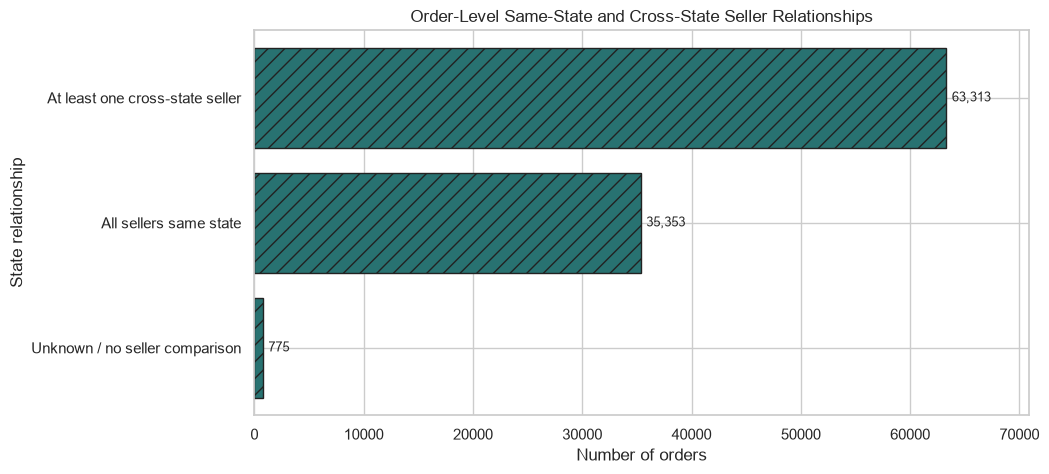

In [36]:
state_order_status = order_geo_features["all_sellers_same_state"].map(
    {True: "All sellers same state", False: "At least one cross-state seller"}
).astype("string").fillna("Unknown / no seller comparison")
state_order_counts = state_order_status.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(state_order_counts.index, state_order_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
label_horizontal_bars(ax, bars)
ax.set_title("Order-Level Same-State and Cross-State Seller Relationships")
ax.set_xlabel("Number of orders")
ax.set_ylabel("State relationship")
plt.show()
plt.close(fig)

**Observation.** Orders are separated into fully same-state, at-least-one cross-state, and unknown/no-comparison groups. The explicit third group prevents missing geography from being counted as cross-state.

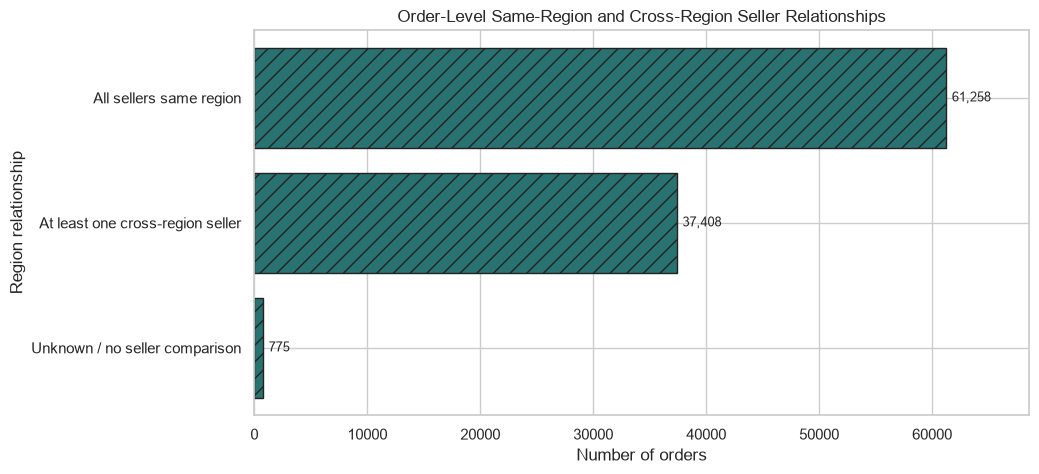

In [37]:
region_order_status = order_geo_features["all_sellers_same_region"].map(
    {True: "All sellers same region", False: "At least one cross-region seller"}
).astype("string").fillna("Unknown / no seller comparison")
region_order_counts = region_order_status.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(region_order_counts.index, region_order_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
label_horizontal_bars(ax, bars)
ax.set_title("Order-Level Same-Region and Cross-Region Seller Relationships")
ax.set_xlabel("Number of orders")
ax.set_ylabel("Region relationship")
plt.show()
plt.close(fig)

**Observation.** Region comparison follows the same three-way treatment as state comparison. Unknown geography remains visible and is not interpreted as a cross-region relationship.

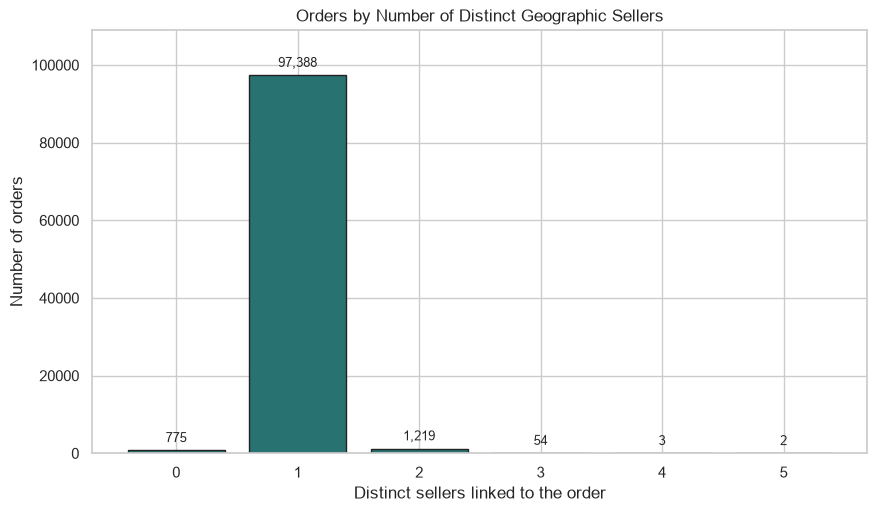

In [38]:
orders_by_seller_count = order_geo_features["geographic_seller_count"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(orders_by_seller_count.index.astype(str), orders_by_seller_count.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR)
ax.bar_label(bars, labels=[f"{int(value):,}" for value in orders_by_seller_count.values], padding=4, fontsize=9)
ax.margins(y=0.12)
ax.set_title("Orders by Number of Distinct Geographic Sellers")
ax.set_xlabel("Distinct sellers linked to the order")
ax.set_ylabel("Number of orders")
plt.show()
plt.close(fig)

**Observation.** Seller counts are based on unique `order_id`-`seller_id` relationships, so repeated item rows from the same seller do not inflate this distribution. Orders with no seller bridge record are shown explicitly at zero.

## 18. Target-Related Geographic EDA

### 18.1 Ownership Boundary and Temporary EDA Contract

Member A owns target construction, eligible-order filtering, delivery-date processing, and overall order preprocessing. Member B reads only `order_id` and the approved `is_late_delivery` from Member A's output, does not recreate or modify the target, and does not change eligibility rules.

The target is joined temporarily to the approved Member B order-geography output for descriptive EDA only. `geo_target_eda` is never exported, and `is_late_delivery` remains absent from `order_geo_features.csv`. Results are associative, not causal; no predictive model or target-based feature selection is fitted here.

In [39]:
from scipy.stats import chi2_contingency, mannwhitneyu

MEMBER_A_TARGET_PATH = REPO_ROOT / "data" / "processed" / "orders_clean.csv"
MEMBER_B_ORDER_GEO_PATH = REPO_ROOT / "data" / "processed" / "order_geo_features.csv"
target_bridge = pd.read_csv(MEMBER_A_TARGET_PATH, usecols=["order_id", "is_late_delivery"], dtype={"order_id": "string"})
order_geo_features_eda_source = pd.read_csv(MEMBER_B_ORDER_GEO_PATH, dtype={"order_id": "string"})

target_validation = pd.Series({
    "target_file": MEMBER_A_TARGET_PATH.relative_to(REPO_ROOT).as_posix(),
    "row_count": len(target_bridge),
    "missing_order_id": int(target_bridge["order_id"].isna().sum()),
    "duplicate_order_id": int(target_bridge["order_id"].duplicated().sum()),
    "order_id_unique": bool(target_bridge["order_id"].is_unique),
    "missing_target": int(target_bridge["is_late_delivery"].isna().sum()),
    "target_values": sorted(target_bridge["is_late_delivery"].dropna().unique().tolist()),
}, name="value").to_frame()
assert target_bridge["order_id"].notna().all() and target_bridge["order_id"].is_unique
assert target_bridge["is_late_delivery"].notna().all()
assert set(target_bridge["is_late_delivery"].unique()) == {0, 1}
assert order_geo_features_eda_source["order_id"].notna().all() and order_geo_features_eda_source["order_id"].is_unique
assert "is_late_delivery" not in order_geo_features_eda_source.columns

order_coverage_comparison = target_bridge[["order_id"]].merge(order_geo_features_eda_source[["order_id"]], on="order_id", how="outer", indicator="coverage", validate="one_to_one")
coverage_counts = order_coverage_comparison["coverage"].value_counts()
shared_order_count = int(coverage_counts.get("both", 0)); member_a_only_count = int(coverage_counts.get("left_only", 0)); member_b_only_count = int(coverage_counts.get("right_only", 0))
coverage_summary = pd.DataFrame({
    "dataset": ["Member A eligible target", "Member B order geography"],
    "row_count": [len(target_bridge), len(order_geo_features_eda_source)],
    "shared_order_count": [shared_order_count, shared_order_count],
    "unmatched_order_count": [member_a_only_count, member_b_only_count],
    "match_percentage": [shared_order_count / len(target_bridge) * 100, shared_order_count / len(order_geo_features_eda_source) * 100],
}).set_index("dataset")
geo_target_eda = target_bridge.merge(order_geo_features_eda_source, on="order_id", how="inner", validate="one_to_one")
assert len(geo_target_eda) == shared_order_count and geo_target_eda["order_id"].is_unique
assert member_a_only_count == 0 and "is_late_delivery" not in order_geo_features.columns
display(Markdown("#### Approved Target Validation"), target_validation)
display(Markdown("#### Diagnostic Outer Coverage Comparison"), coverage_summary)
print(f"Temporary one-to-one EDA merge shape: {geo_target_eda.shape}")

#### Approved Target Validation

,value
target_file,data/processed/orders_clean.csv
row_count,96470
missing_order_id,0
duplicate_order_id,0
order_id_unique,True
missing_target,0
target_values,"[0, 1]"


#### Diagnostic Outer Coverage Comparison

,row_count,shared_order_count,unmatched_order_count,match_percentage
dataset,,,,
Member A eligible target,96470,96470,0,100.0000
Member B order geography,99441,96470,2971,97.0123


Temporary one-to-one EDA merge shape: (96470, 16)


**Interpretation.** Member A contributes **96,470 unique eligible orders** with a complete binary target. All 96,470 match Member B (100.00% of Member A), while **2,971 orders appear only in Member B**; Member B coverage is **97.01%**. The gap follows Member A's documented rules: non-delivered orders and eight delivered rows without an actual delivery timestamp are unlabelled. The one-to-one temporary merge is not saved.

### 18.2 Class Distribution and Imbalance

Counts and percentages use only Member A's eligible target population.

,order_count,percentage
is_late_delivery,,
On time (0),88644,91.8876
Late (1),7826,8.1124


Majority-to-minority ratio: 11.3269:1


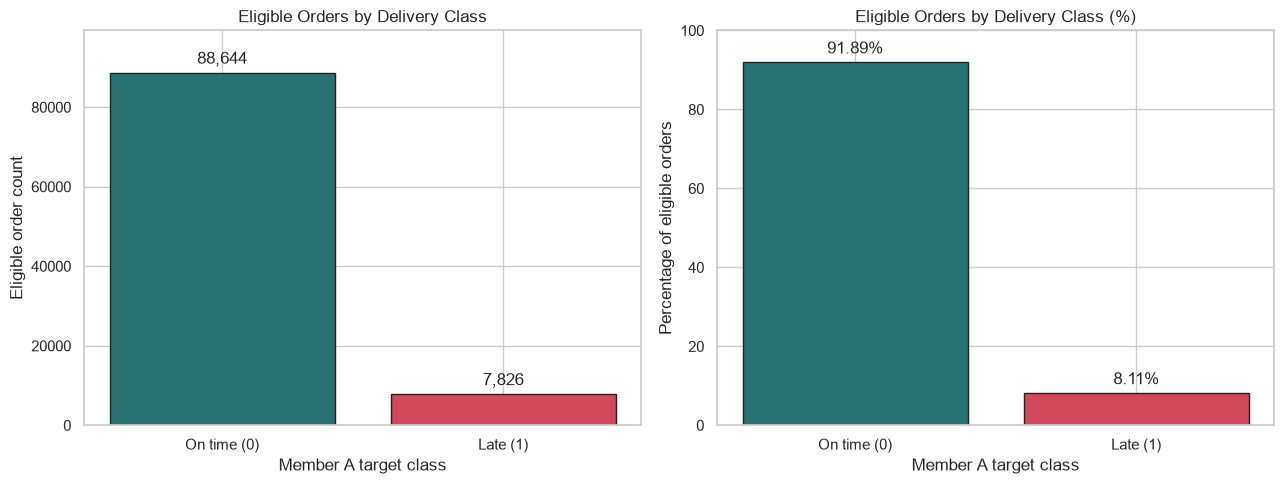

In [40]:
target_class_summary = geo_target_eda["is_late_delivery"].value_counts().sort_index().rename(index={0: "On time (0)", 1: "Late (1)"}).rename("order_count").to_frame()
target_class_summary["percentage"] = target_class_summary["order_count"] / len(geo_target_eda) * 100
majority_to_minority_ratio = target_class_summary.loc["On time (0)", "order_count"] / target_class_summary.loc["Late (1)", "order_count"]
display(target_class_summary); print(f"Majority-to-minority ratio: {majority_to_minority_ratio:.4f}:1")
fig, axes = plt.subplots(1, 2, figsize=(13, 5)); colors=[PRIMARY_COLOR, SECONDARY_COLOR]
bars=axes[0].bar(target_class_summary.index,target_class_summary["order_count"],color=colors,edgecolor=EDGE_COLOR); axes[0].bar_label(bars,labels=[f"{v:,}" for v in target_class_summary["order_count"]],padding=4)
axes[0].set(title="Eligible Orders by Delivery Class",xlabel="Member A target class",ylabel="Eligible order count"); axes[0].set_ylim(0,target_class_summary["order_count"].max()*1.12)
bars=axes[1].bar(target_class_summary.index,target_class_summary["percentage"],color=colors,edgecolor=EDGE_COLOR); axes[1].bar_label(bars,labels=[f"{v:.2f}%" for v in target_class_summary["percentage"]],padding=4)
axes[1].set(title="Eligible Orders by Delivery Class (%)",xlabel="Member A target class",ylabel="Percentage of eligible orders"); axes[1].set_ylim(0,100)
plt.tight_layout(); plt.show(); plt.close(fig)

**Interpretation.** There are **88,644 on-time orders (91.8876%)** and **7,826 late orders (8.1124%)**, a **11.3269:1** ratio. Accuracy alone may obscure minority performance, so downstream evaluation should include precision, recall, F1-score, ROC-AUC, and especially PR-AUC. Weighting or resampling belongs only on training data after the chronological split.

### 18.3 Customer State and Region

Tables report eligible orders, late orders, and late rate. All states remain in the data; the state chart requires at least 300 eligible orders only to avoid visually emphasizing very small groups.

#### Customer Region Target Summary

,customer_region,eligible_orders,late_orders,late_rate_pct
2,Northeast,9044,1296,14.3299
1,North,1796,176,9.7996
0,Central-West,5624,448,7.9659
4,Southeast,66193,4932,7.4509
3,South,13813,974,7.0513


#### Customer State Target Summary

,customer_state,eligible_orders,late_orders,late_rate_pct,reliable_visual_sample
1,AL,397,95,23.9295,True
9,MA,717,141,19.6653,True
16,PI,476,76,15.9664,True
5,CE,1279,196,15.3245,True
24,SE,335,51,15.2239,True
4,BA,3256,457,14.0356,True
18,RJ,12350,1664,13.4737,True
26,TO,274,35,12.7737,False
13,PA,946,117,12.3679,True
7,ES,1995,244,12.2306,True


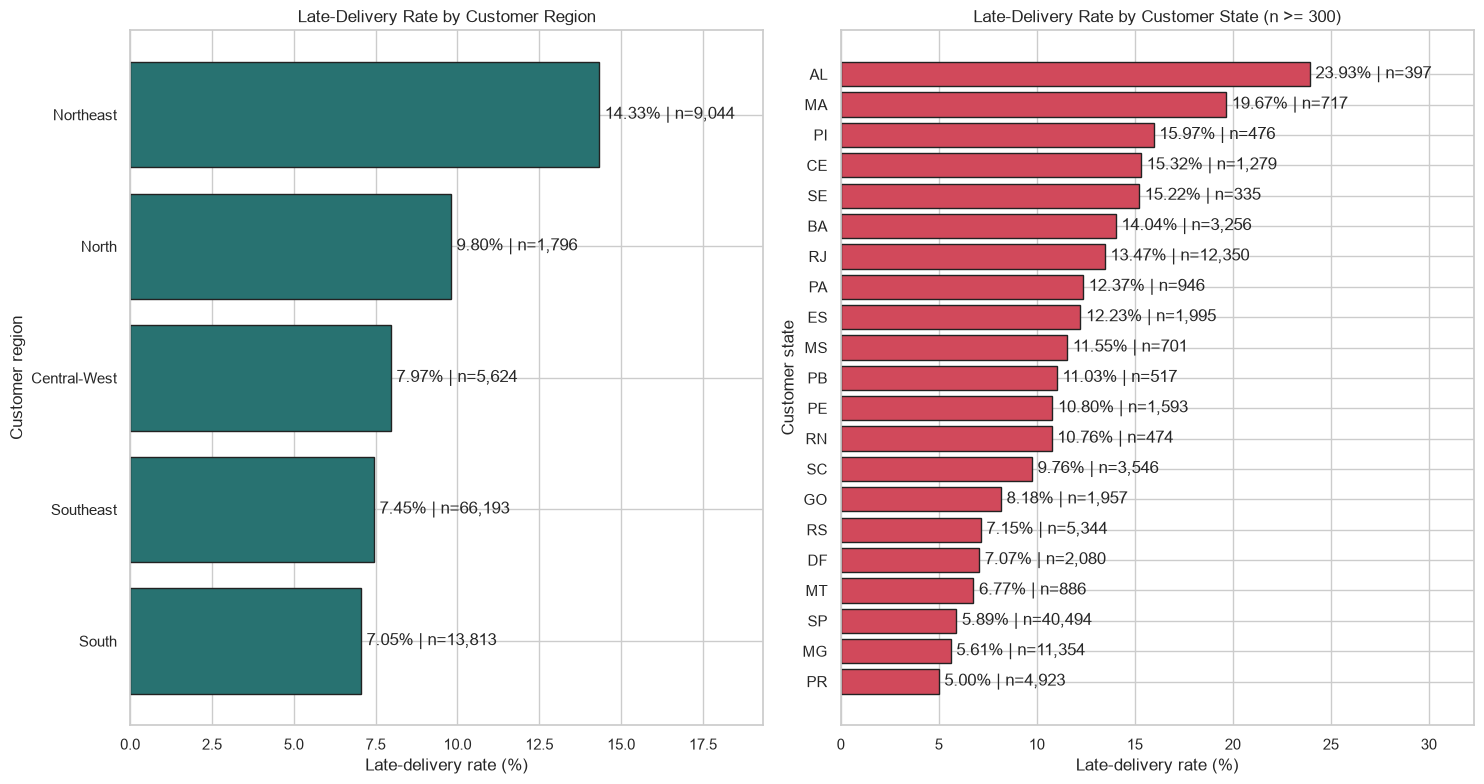

In [41]:
def categorical_target_summary(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    summary = frame.groupby(column, dropna=False, observed=False)["is_late_delivery"].agg(eligible_orders="size", late_orders="sum", late_rate="mean").reset_index()
    summary["late_rate_pct"] = summary.pop("late_rate") * 100
    return summary
customer_region_target_summary = categorical_target_summary(geo_target_eda,"customer_region").sort_values("late_rate_pct",ascending=False)
customer_state_target_summary = categorical_target_summary(geo_target_eda,"customer_state").sort_values(["late_rate_pct","eligible_orders"],ascending=[False,False])
customer_state_target_summary["reliable_visual_sample"] = customer_state_target_summary["eligible_orders"].ge(300)
display(Markdown("#### Customer Region Target Summary"),customer_region_target_summary)
display(Markdown("#### Customer State Target Summary"),customer_state_target_summary)
region_plot=customer_region_target_summary.sort_values("late_rate_pct"); state_plot=customer_state_target_summary.loc[customer_state_target_summary["reliable_visual_sample"]].sort_values("late_rate_pct")
fig,axes=plt.subplots(1,2,figsize=(15,8))
bars=axes[0].barh(region_plot["customer_region"],region_plot["late_rate_pct"],color=PRIMARY_COLOR,edgecolor=EDGE_COLOR); axes[0].bar_label(bars,labels=[f"{r:.2f}% | n={n:,}" for r,n in zip(region_plot["late_rate_pct"],region_plot["eligible_orders"])],padding=4)
axes[0].set(title="Late-Delivery Rate by Customer Region",xlabel="Late-delivery rate (%)",ylabel="Customer region"); axes[0].margins(x=.35)
bars=axes[1].barh(state_plot["customer_state"],state_plot["late_rate_pct"],color=SECONDARY_COLOR,edgecolor=EDGE_COLOR); axes[1].bar_label(bars,labels=[f"{r:.2f}% | n={n:,}" for r,n in zip(state_plot["late_rate_pct"],state_plot["eligible_orders"])],padding=4)
axes[1].set(title="Late-Delivery Rate by Customer State (n >= 300)",xlabel="Late-delivery rate (%)",ylabel="Customer state"); axes[1].margins(x=.35)
plt.tight_layout(); plt.show(); plt.close(fig)

**Interpretation.** Northeast is highest at **14.3299% (1,296/9,044)**, versus North 9.7996%, Central-West 7.9659%, Southeast 7.4509%, and South 7.0513%. Among states meeting the display threshold, AL is **23.9295% (n=397)** and MA 19.6653% (n=717), while PR is 4.9970%, MG 5.6104%, and SP 5.8947%. Small-state rates are not used for strong conclusions. Geography may proxy route, infrastructure, seller-network, and seasonal differences; it is not shown to cause lateness. State and region remain provisional pending out-of-time stability and incremental-value checks.

### 18.4 Customer-Seller State and Region Agreement

For each nullable indicator, 0 means false, 1 means true, and missing means unavailable. Missing remains an explicit table category even when its count is zero.

eligible_orders  late_orders  \
indicator               value                                                 
any_seller_same_state   0 - No                           61648         5722   
                        1 - Yes                          34822         2104   
                        Missing / unavailable                0            0   
all_sellers_same_state  0 - No                           61895         5723   
                        1 - Yes                          34575         2103   
                        Missing / unavailable                0            0   
any_seller_same_region  0 - No                           36340         3248   
                        1 - Yes                          60130         4578   
                        Missing / unavailable                0            0   
all_sellers_same_region 0 - No                           36606         3249   
                        1 - Yes                          59864         4577   
                        Missing / unavailable                0            0   

                                               late_rate_pct  
indicator               value                                 
any_seller_same_state   0 - No                        9.2817  
                        1 - Yes                       6.0422  
                        Missing / unavailable            NaN  
all_sellers_same_state  0 - No                        9.2463  
                        1 - Yes                       6.0824  
                        Missing / unavailable            NaN  
any_seller_same_region  0 - No                        8.9378  
                        1 - Yes                       7.6135  
                        Missing / unavailable            NaN  
all_sellers_same_region 0 - No                        8.8756  
                        1 - Yes                       7.6457  
                        Missing / unavailable            NaN

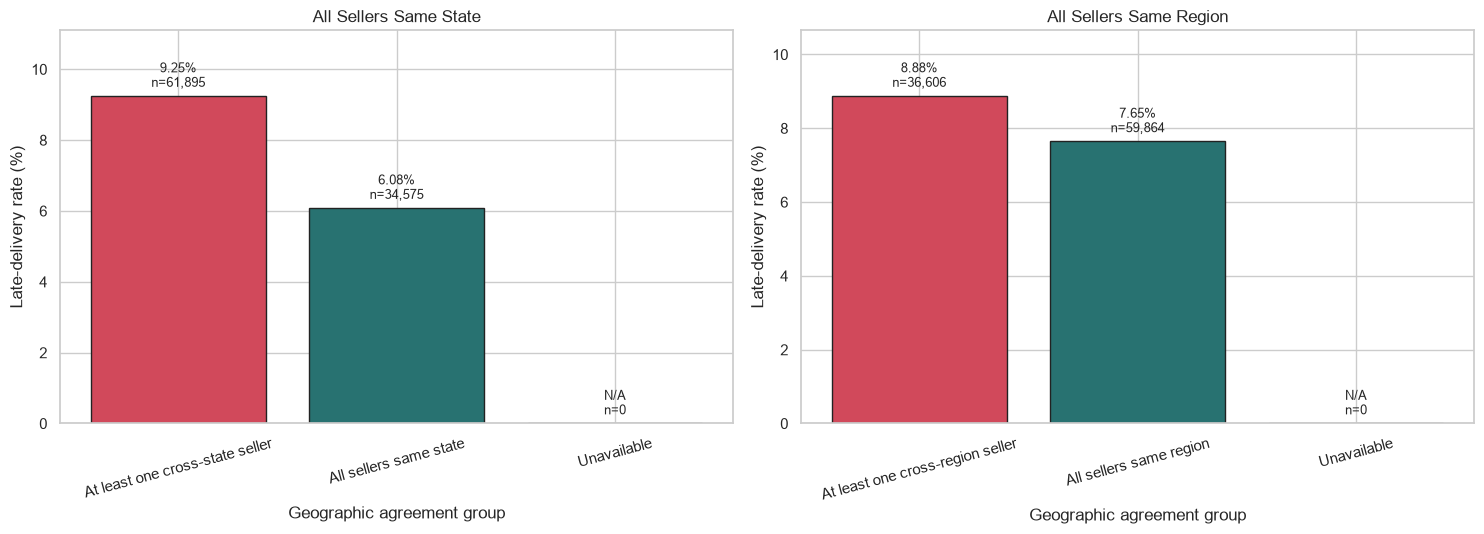

In [42]:
agreement_columns=["any_seller_same_state","all_sellers_same_state","any_seller_same_region","all_sellers_same_region"]
agreement_categories=["0 - No","1 - Yes","Missing / unavailable"]; agreement_tables={}
for column in agreement_columns:
    labels=geo_target_eda[column].astype("boolean").map({False:"0 - No",True:"1 - Yes"}).astype("string").fillna("Missing / unavailable")
    table=geo_target_eda.assign(agreement_group=labels).groupby("agreement_group",observed=False)["is_late_delivery"].agg(eligible_orders="size",late_orders="sum",late_rate="mean").reindex(agreement_categories)
    table[["eligible_orders","late_orders"]]=table[["eligible_orders","late_orders"]].fillna(0).astype(int); table["late_rate_pct"]=table.pop("late_rate")*100; agreement_tables[column]=table
agreement_target_summary=pd.concat(agreement_tables,names=["indicator","value"]); display(agreement_target_summary)
plot_specs=[("all_sellers_same_state","All Sellers Same State","At least one cross-state seller","All sellers same state"),("all_sellers_same_region","All Sellers Same Region","At least one cross-region seller","All sellers same region")]
fig,axes=plt.subplots(1,2,figsize=(15,5.5))
for ax,(column,title,no_label,yes_label) in zip(axes,plot_specs):
    table=agreement_tables[column]; bars=ax.bar([no_label,yes_label,"Unavailable"],table["late_rate_pct"].fillna(0),color=[SECONDARY_COLOR,PRIMARY_COLOR,"#8D99AE"],edgecolor=EDGE_COLOR)
    labels=[f"{r:.2f}%\nn={n:,}" if n else "N/A\nn=0" for r,n in zip(table["late_rate_pct"].fillna(0),table["eligible_orders"])]
    ax.bar_label(bars,labels=labels,padding=4,fontsize=9); ax.set(title=title,xlabel="Geographic agreement group",ylabel="Late-delivery rate (%)"); ax.tick_params(axis="x",rotation=15); ax.margins(y=.2)
plt.tight_layout(); plt.show(); plt.close(fig)

**Interpretation.** All agreement values are available for eligible orders. At least one cross-state seller corresponds to **9.2817%** late versus **6.0422%** when at least one seller shares the state; all-seller results are 9.2463% versus 6.0824%. Cross-region differences are smaller: 8.9378% versus 7.6135% for any-seller and 8.8756% versus 7.6457% for all-seller comparisons. These indicators overlap with distance and destination mix, so the associations require downstream redundancy and stability checks.

### 18.5 Customer-Seller Distance

Minimum, average, and maximum Haversine summaries are compared without deleting outliers. Boxplot fliers are hidden only visually; all values remain in calculations and the histogram. Reproducible exploratory average-distance bands use `<250`, `250-499`, `500-999`, `1,000-1,499`, and `1,500+` km, plus missing. They are descriptive, not universal logistics thresholds.

available_count  missing_count  mean_km  \
distance_feature    target_class                                            
minimum_distance_km On time                 88218            426 586.9809   
                    Late                     7775             51 737.2886   
average_distance_km On time                 88218            426 588.4166   
                    Late                     7775             51 737.4032   
maximum_distance_km On time                 88218            426 589.8586   
                    Late                     7775             51 737.5178   

                                  median_km  standard_deviation_km    q1_km  \
distance_feature    target_class                                              
minimum_distance_km On time        425.1209               582.1334 172.5311   
                    Late           511.4896               682.0684 294.3708   
average_distance_km On time        426.7138               582.0431 176.3556   
                    Late           511.7607               682.1229 294.3708   
maximum_distance_km On time        428.2797               582.6135 177.5392   
                    Late           511.8625               682.1992 294.3708   

                                    q3_km  
distance_feature    target_class           
minimum_distance_km On time      782.3332  
                    Late         923.8608  
average_distance_km On time      783.3470  
                    Late         924.2771  
maximum_distance_km On time      786.1667  
                    Late         924.2771

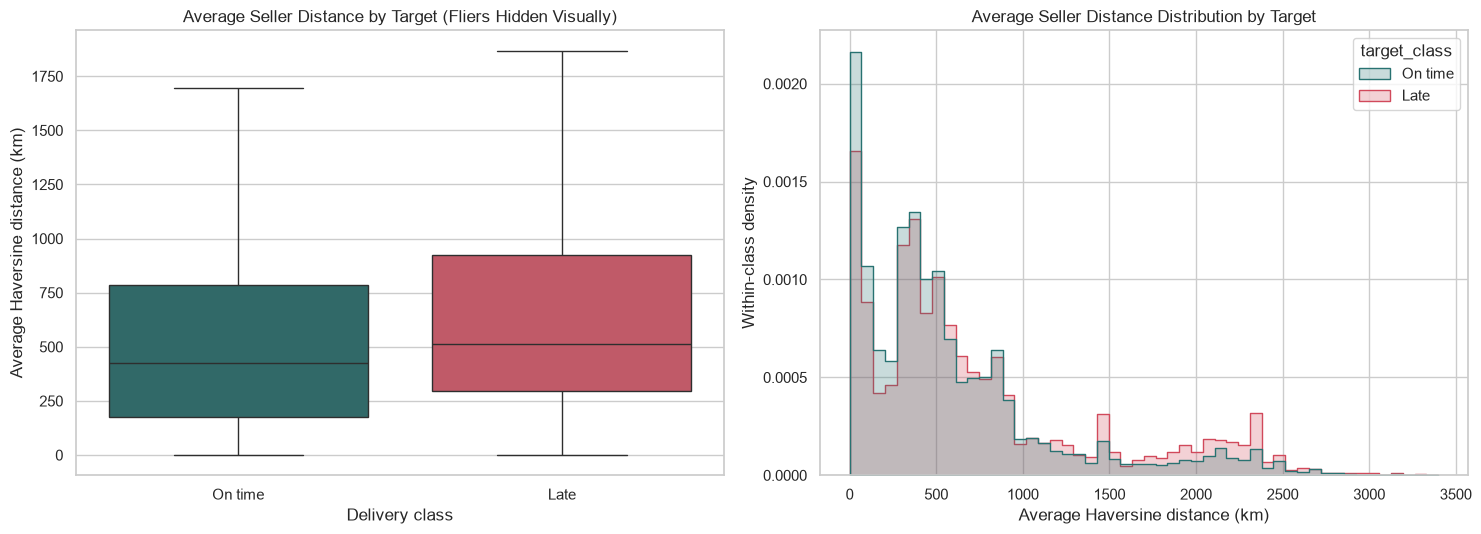

,eligible_orders,late_orders,late_rate_pct
distance_band,,,
<250,27289,1720,6.3029
250-499,27599,2074,7.5148
500-999,25763,2170,8.4229
"1,000-1,499",6573,665,10.1171
"1,500+",8769,1146,13.0688
Missing,477,51,10.6918


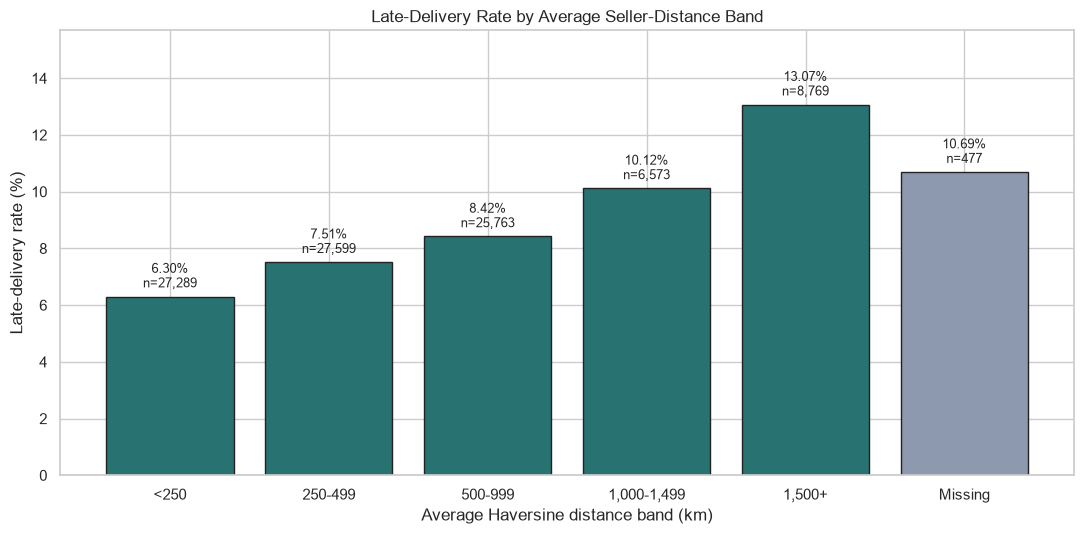

In [43]:
distance_columns_target=["minimum_distance_km","average_distance_km","maximum_distance_km"]
rows=[]
for column in distance_columns_target:
    for value,label in [(0,"On time"),(1,"Late")]:
        series=geo_target_eda.loc[geo_target_eda["is_late_delivery"].eq(value),column]; available=series.dropna()
        rows.append({"distance_feature":column,"target_class":label,"available_count":len(available),"missing_count":int(series.isna().sum()),"mean_km":available.mean(),"median_km":available.median(),"standard_deviation_km":available.std(),"q1_km":available.quantile(.25),"q3_km":available.quantile(.75)})
distance_target_summary=pd.DataFrame(rows).set_index(["distance_feature","target_class"]); display(distance_target_summary)
plot=geo_target_eda[["is_late_delivery","average_distance_km"]].dropna().copy(); plot["target_class"]=plot["is_late_delivery"].map({0:"On time",1:"Late"})
fig,axes=plt.subplots(1,2,figsize=(15,5.5))
sns.boxplot(data=plot,x="target_class",y="average_distance_km",order=["On time","Late"],showfliers=False,palette={"On time":PRIMARY_COLOR,"Late":SECONDARY_COLOR},hue="target_class",legend=False,ax=axes[0]); axes[0].set(title="Average Seller Distance by Target (Fliers Hidden Visually)",xlabel="Delivery class",ylabel="Average Haversine distance (km)")
sns.histplot(data=plot,x="average_distance_km",hue="target_class",hue_order=["On time","Late"],bins=50,stat="density",common_norm=False,element="step",palette={"On time":PRIMARY_COLOR,"Late":SECONDARY_COLOR},ax=axes[1]); axes[1].set(title="Average Seller Distance Distribution by Target",xlabel="Average Haversine distance (km)",ylabel="Within-class density")
plt.tight_layout(); plt.show(); plt.close(fig)
band_order=["<250","250-499","500-999","1,000-1,499","1,500+","Missing"]
bands=pd.cut(geo_target_eda["average_distance_km"],bins=[-np.inf,250,500,1000,1500,np.inf],labels=band_order[:-1],right=False).astype("string").fillna("Missing")
distance_band_target_summary=geo_target_eda.assign(distance_band=bands).groupby("distance_band",observed=False)["is_late_delivery"].agg(eligible_orders="size",late_orders="sum",late_rate="mean").reindex(band_order); distance_band_target_summary["late_rate_pct"]=distance_band_target_summary.pop("late_rate")*100; display(distance_band_target_summary)
fig,ax=plt.subplots(figsize=(11,5.5)); bars=ax.bar(distance_band_target_summary.index,distance_band_target_summary["late_rate_pct"],color=[PRIMARY_COLOR]*5+["#8D99AE"],edgecolor=EDGE_COLOR)
ax.bar_label(bars,labels=[f"{r:.2f}%\nn={n:,}" for r,n in zip(distance_band_target_summary["late_rate_pct"],distance_band_target_summary["eligible_orders"])],padding=4,fontsize=9); ax.set(title="Late-Delivery Rate by Average Seller-Distance Band",xlabel="Average Haversine distance band (km)",ylabel="Late-delivery rate (%)"); ax.margins(y=.2); plt.tight_layout(); plt.show(); plt.close(fig)

**Interpretation.** Average distance is available for **95,993 orders** and missing for 477. Late orders have mean **737.4032 km** versus 588.4166 km and median **511.7607 km** versus 426.7138 km; minimum and maximum summaries agree. Late rate rises from **6.3029% below 250 km** to **13.0688% at 1,500+ km**; missing distance is 10.6918% (51/477). Distributions still overlap, and Haversine distance is not route distance. Distance remains provisional pending nonlinear, missingness, correlation, and out-of-time checks.

### 18.6 Seller Count and Geographic Diversity

Original count values remain in tables. Only the seller-count chart combines counts of three or more into `3+` because they cover 59 orders; source values are unchanged.

eligible_orders  late_orders  late_rate_pct
feature                 value                                             
geographic_seller_count 1                95195         7808         8.2021
                        2                 1216           18         1.4803
                        3                   54            0         0.0000
                        4                    3            0         0.0000
                        5                    2            0         0.0000
distinct_seller_states  1                95961         7822         8.1512
                        2                  502            4         0.7968
                        3                    7            0         0.0000
distinct_seller_regions 1                96172         7825         8.1365
                        2                  298            1         0.3356

#### Seller-Count Display Groups

,eligible_orders,late_orders,late_rate_pct
seller_count_group,,,
1,95195,7808,8.2021
2,1216,18,1.4803
3+,59,0,0.0000


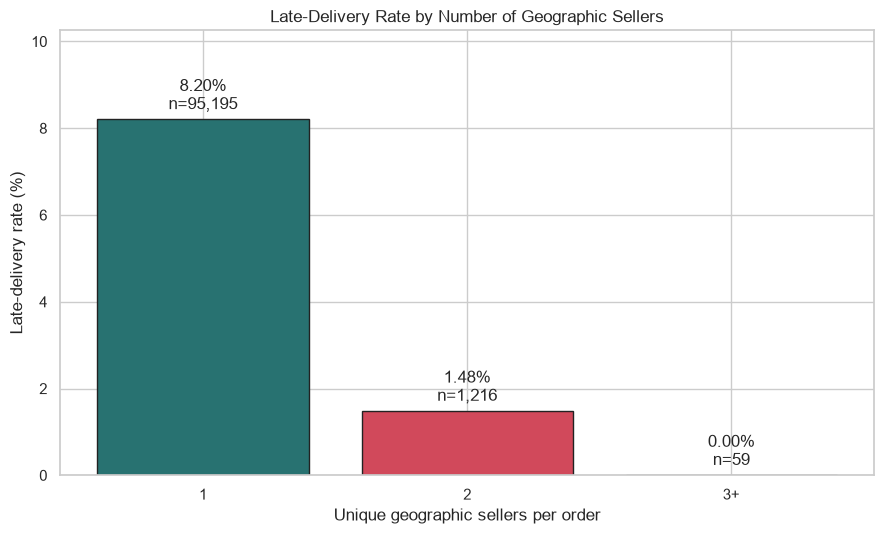

In [44]:
seller_complexity_columns=["geographic_seller_count","distinct_seller_states","distinct_seller_regions"]
seller_complexity_tables={c:categorical_target_summary(geo_target_eda,c).sort_values(c) for c in seller_complexity_columns}
seller_complexity_target_summary=pd.concat({c:t.set_index(c) for c,t in seller_complexity_tables.items()},names=["feature","value"]); display(seller_complexity_target_summary)
display_group=geo_target_eda["geographic_seller_count"].map(lambda v:"3+" if v>=3 else str(int(v)))
seller_count_display_summary=geo_target_eda.assign(seller_count_group=display_group).groupby("seller_count_group",observed=False)["is_late_delivery"].agg(eligible_orders="size",late_orders="sum",late_rate="mean").reindex(["1","2","3+"]); seller_count_display_summary["late_rate_pct"]=seller_count_display_summary.pop("late_rate")*100; display(Markdown("#### Seller-Count Display Groups"),seller_count_display_summary)
fig,ax=plt.subplots(figsize=(9,5.5)); bars=ax.bar(seller_count_display_summary.index,seller_count_display_summary["late_rate_pct"],color=[PRIMARY_COLOR,SECONDARY_COLOR,"#8D99AE"],edgecolor=EDGE_COLOR)
ax.bar_label(bars,labels=[f"{r:.2f}%\nn={n:,}" for r,n in zip(seller_count_display_summary["late_rate_pct"],seller_count_display_summary["eligible_orders"])],padding=4); ax.set(title="Late-Delivery Rate by Number of Geographic Sellers",xlabel="Unique geographic sellers per order",ylabel="Late-delivery rate (%)"); ax.margins(y=.25); plt.tight_layout(); plt.show(); plt.close(fig)

**Interpretation.** Single-seller orders dominate (**95,195/96,470**) and are 8.2021% late. Two-seller orders are 1.4803% (18/1,216); the 59 orders in `3+` have no late cases. Multi-state and multi-region orders are also rare. These small, compositionally different groups do not show that adding sellers prevents lateness. Count and diversity features remain provisional, with rare-level handling and stability to be tested on training data.

### 18.7 Coordinate and Distance Availability

Customer coordinates, seller coordinates, and average-distance availability are compared separately. Missingness is a coverage diagnostic, not a causal mechanism.

eligible_orders  late_orders  late_rate_pct
availability_feature status                                                
Customer coordinates Available            96205         7796         8.1035
                     Missing                265           30        11.3208
Seller coordinates   Available            96253         7805         8.1088
                     Missing                217           21         9.6774
Average distance     Available            95993         7775         8.0995
                     Missing                477           51        10.6918

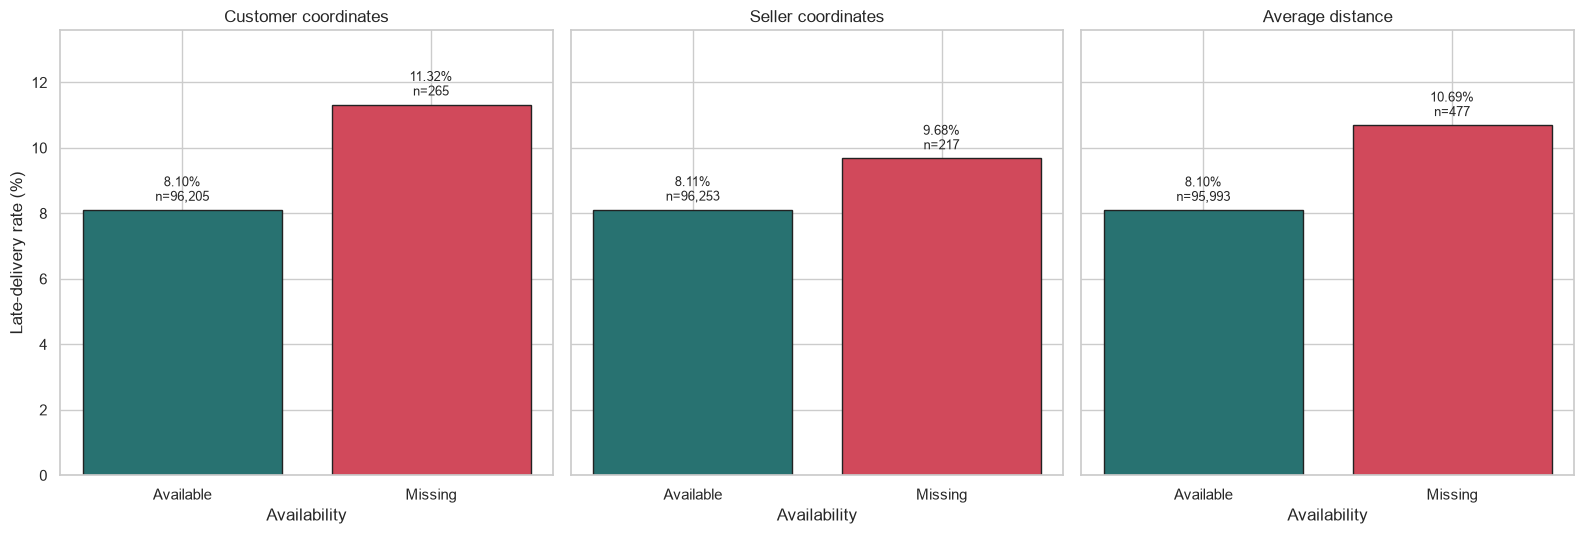

In [45]:
availability_specs={
    "Customer coordinates":geo_target_eda["missing_customer_coordinates"].astype("boolean").map({False:"Available",True:"Missing"}).astype("string").fillna("Indicator unavailable"),
    "Seller coordinates":geo_target_eda["missing_seller_coordinates"].astype("boolean").map({False:"Available",True:"Missing"}).astype("string").fillna("Indicator unavailable"),
    "Average distance":geo_target_eda["average_distance_km"].isna().map({False:"Available",True:"Missing"}),}
availability_tables={}
for name,groups in availability_specs.items():
    table=geo_target_eda.assign(availability_group=groups).groupby("availability_group",observed=False)["is_late_delivery"].agg(eligible_orders="size",late_orders="sum",late_rate="mean"); table["late_rate_pct"]=table.pop("late_rate")*100; availability_tables[name]=table
availability_target_summary=pd.concat(availability_tables,names=["availability_feature","status"]); display(availability_target_summary)
fig,axes=plt.subplots(1,3,figsize=(16,5.5),sharey=True)
for ax,(name,table) in zip(axes,availability_tables.items()):
    ordered=table.reindex(["Available","Missing"]).dropna(subset=["eligible_orders"]); bars=ax.bar(ordered.index,ordered["late_rate_pct"],color=[PRIMARY_COLOR,SECONDARY_COLOR],edgecolor=EDGE_COLOR)
    ax.bar_label(bars,labels=[f"{r:.2f}%\nn={int(n):,}" for r,n in zip(ordered["late_rate_pct"],ordered["eligible_orders"])],padding=4,fontsize=9); ax.set(title=name,xlabel="Availability"); ax.margins(y=.2)
axes[0].set_ylabel("Late-delivery rate (%)"); plt.tight_layout(); plt.show(); plt.close(fig)

**Interpretation.** Missing customer coordinates cover **265 orders** at 11.3208% late versus 8.1035% when available. Missing seller coordinates cover 217 orders (9.6774% versus 8.1088%), and missing average distance covers 477 (10.6918% versus 8.0995%). These small groups may reflect coverage or order composition; missingness indicators remain provisional and require stability checks.

### 18.8 Limited Descriptive Statistical Support

Highly skewed distances use two-sided Mann-Whitney U tests with rank-biserial effect size. Categorical tables use chi-square only where expected counts are adequate, with Cramer's V. Full-sample p-values support description, not causality or feature selection.

In [46]:
mw_rows=[]
for column in distance_columns_target:
    late=geo_target_eda.loc[geo_target_eda["is_late_delivery"].eq(1),column].dropna(); on_time=geo_target_eda.loc[geo_target_eda["is_late_delivery"].eq(0),column].dropna()
    statistic,p_value=mannwhitneyu(late,on_time,alternative="two-sided"); effect=2*statistic/(len(late)*len(on_time))-1
    mw_rows.append({"feature":column,"late_n":len(late),"on_time_n":len(on_time),"mann_whitney_u":statistic,"p_value":p_value,"rank_biserial_late_vs_on_time":effect})
mann_whitney_results=pd.DataFrame(mw_rows).set_index("feature")
def chi_square_effect(name,categories):
    table=pd.crosstab(categories,geo_target_eda["is_late_delivery"]); statistic,p_value,dof,expected=chi2_contingency(table); denominator=table.to_numpy().sum()*min(table.shape[0]-1,table.shape[1]-1)
    return {"feature":name,"groups":table.shape[0],"chi_square":statistic,"degrees_of_freedom":dof,"p_value":p_value,"minimum_expected_count":expected.min(),"cramers_v":np.sqrt(statistic/denominator)}
chi_inputs={
    "customer_region":geo_target_eda["customer_region"],
    "any_seller_same_state":geo_target_eda["any_seller_same_state"].astype("boolean").astype("string").fillna("Unavailable"),
    "all_sellers_same_state":geo_target_eda["all_sellers_same_state"].astype("boolean").astype("string").fillna("Unavailable"),
    "any_seller_same_region":geo_target_eda["any_seller_same_region"].astype("boolean").astype("string").fillna("Unavailable"),
    "all_sellers_same_region":geo_target_eda["all_sellers_same_region"].astype("boolean").astype("string").fillna("Unavailable"),
    "average_distance_missing":geo_target_eda["average_distance_km"].isna().map({False:"Available",True:"Missing"}),}
chi_square_results=pd.DataFrame([chi_square_effect(n,v) for n,v in chi_inputs.items()]).set_index("feature")
assert chi_square_results["minimum_expected_count"].ge(5).all()
display(Markdown("#### Mann-Whitney U Distance Comparisons"),mann_whitney_results)
display(Markdown("#### Chi-Square Categorical Comparisons"),chi_square_results)

#### Mann-Whitney U Distance Comparisons

,late_n,on_time_n,mann_whitney_u,p_value,rank_biserial_late_vs_on_time
feature,,,,,
minimum_distance_km,7775,88218,"386,548,151.5000",0.0000,0.1271
average_distance_km,7775,88218,"385,882,407.5000",0.0000,0.1252
maximum_distance_km,7775,88218,"385,308,831.5000",0.0000,0.1235


#### Chi-Square Categorical Comparisons

,groups,chi_square,degrees_of_freedom,p_value,minimum_expected_count,cramers_v
feature,,,,,,
customer_region,5,535.7575,4,0.0000,145.6981,0.0745
any_seller_same_state,2,312.8587,1,0.0000,"2,824.8883",0.0569
all_sellers_same_state,2,297.4681,1,0.0000,"2,804.8507",0.0555
any_seller_same_region,2,53.1137,1,0.0000,"2,948.0340",0.0235
all_sellers_same_region,2,45.9332,1,0.0000,"2,969.6129",0.0218
average_distance_missing,2,3.9381,1,0.0472,38.6960,0.0064


**Interpretation.** Distance rank-biserial effects are only **0.1235-0.1271**, a small positive shift for late orders despite tiny p-values. Customer-region Cramer's V is **0.0745**, state agreement **0.0555-0.0569**, region agreement **0.0218-0.0235**, and distance availability **0.0064**. Expected counts exceed five. Large samples make small differences detectable, so practical effect size, redundancy, stability, and downstream model contribution matter more than significance alone. No feature is selected or rejected here.

## 19. Leakage Analysis

### 19.1 Prediction Point and Feature-Availability Review

The intended prediction point is **after the order and its items are confirmed, but before delivery occurs**. At this point, the order identifier, customer relationship, ordered items, associated sellers, and static customer/seller geography are known. Delivery outcomes and later order-lifecycle events are not known. This timing assumption is essential for the seller-count and seller-diversity features: they are safe only because all order items and their associated sellers have already been confirmed.

The table below reviews every column in the final `order_geo_features` table, followed by the intermediate geographic fields and quality diagnostics used to create or validate those columns. `Retain` means provisionally eligible for downstream modelling; it is not a target-based or model-based selection decision.

| Feature name | Source tables | When available | Available at prediction point? | Leakage risk | Decision | Explanation |
|---|---|---|---|---|---|---|
|`order_id`|`orders` bridge|When the order is created.|Yes|Identifier memorization if modelled.|**Key-only**|Used to merge Member B's output; it is not a model predictor.|
|`customer_state`|`orders` bridge -> `customers`|When the order's customer record and stored location are known.|Yes|Low, provided the order-time customer record is used.|**Retain**|Static, coarse customer geography known before delivery.|
|`customer_region`|`customers`; state-to-region mapping|When customer state is known.|Yes|Low; overlaps with customer state.|**Retain**|Deterministic pre-delivery macro-region derived without outcome data.|
|`geographic_seller_count`|`order_items` bridge|After confirmed items identify the distinct sellers.|Yes, under the defined prediction point.|Timing leakage if prediction were moved before item or seller confirmation.|**Retain**|Counts unique order-seller relationships after duplicate pairs are removed.|
|`distinct_seller_states`|`order_items` bridge -> `sellers`|After confirmed sellers are linked to their stored states.|Yes, under the defined prediction point.|Timing leakage if sellers are not yet known; otherwise low.|**Retain**|Order-level seller geographic-diversity summary available before delivery.|
|`distinct_seller_regions`|`order_items` bridge -> `sellers`; state-to-region mapping|After confirmed sellers are linked and regions are derived.|Yes, under the defined prediction point.|Timing leakage if sellers are not yet known; overlaps with seller-state diversity.|**Retain**|Coarser seller geographic-diversity summary derived without outcomes.|
|`any_seller_same_state`|`customers`, `order_items` bridge, `sellers`|After customer and confirmed-seller states are known.|Yes|Low; nullable when a comparison cannot be made.|**Retain**|Pre-delivery relationship indicator; missing locations are not labelled cross-state.|
|`all_sellers_same_state`|`customers`, `order_items` bridge, `sellers`|After customer and all confirmed-seller states are known.|Yes|Low; overlaps with `any_seller_same_state`, especially for single-seller orders.|**Retain**|Pre-delivery relationship indicator with explicit unknown comparisons.|
|`any_seller_same_region`|`customers`, `order_items` bridge, `sellers`; state-to-region mapping|After customer and confirmed-seller regions are known.|Yes|Low; nullable when a comparison cannot be made.|**Retain**|Pre-delivery macro-region relationship indicator.|
|`all_sellers_same_region`|`customers`, `order_items` bridge, `sellers`; state-to-region mapping|After customer and all confirmed-seller regions are known.|Yes|Low; overlaps with `any_seller_same_region` and state indicators.|**Retain**|Pre-delivery macro-region relationship indicator with unknowns preserved.|
|`minimum_distance_km`|`customers`, `sellers`, `geolocation`, and the two permitted bridge tables|After confirmed sellers and static ZIP-centroid coordinates are known.|Yes|Low if centroids are built without target or delivery outcomes.|**Retain**|Minimum Haversine distance is a pre-delivery geographic proxy, not actual route distance.|
|`average_distance_km`|`customers`, `sellers`, `geolocation`, and the two permitted bridge tables|After confirmed sellers and static ZIP-centroid coordinates are known.|Yes|Low if centroids are built without target or delivery outcomes.|**Retain**|Mean Haversine distance summarizes all linked sellers before delivery.|
|`maximum_distance_km`|`customers`, `sellers`, `geolocation`, and the two permitted bridge tables|After confirmed sellers and static ZIP-centroid coordinates are known.|Yes|Low if centroids are built without target or delivery outcomes.|**Retain**|Maximum Haversine distance summarizes the farthest linked seller before delivery.|
|`missing_customer_coordinates`|`customers`, `geolocation`|When the customer ZIP lookup is attempted.|Yes|Low; may reflect source-data quality but contains no delivery outcome.|**Retain**|Preserves informative missingness without replacing coordinates with zero.|
|`missing_seller_coordinates`|`order_items` bridge, `sellers`, `geolocation`|After confirmed sellers are known and their ZIP lookups are attempted.|Yes, under the defined prediction point.|Low, conditional on sellers being confirmed.|**Retain**|Flags unavailable seller coordinates without inferring an outcome.|
|`seller_state`, `seller_region`|`sellers`; state-to-region mapping|After associated sellers are confirmed.|Yes|Low, but raw values do not have a single unambiguous order-level value for multi-seller orders.|**Exclude from final order output**|Used only to create diversity and same-location summaries.|
|`customer_latitude`, `customer_longitude`|`customers`, `geolocation`|When the customer ZIP is matched to the static centroid lookup.|Yes|Low, but strongly overlaps with state, region, and distance features.|**Exclude from final order output**|Intermediate Haversine inputs; not included as direct predictors.|
|`seller_latitude`, `seller_longitude`|`order_items` bridge, `sellers`, `geolocation`|After associated sellers are confirmed and ZIPs are matched.|Yes, under the defined prediction point.|Low, but strongly overlaps with seller geography and distance features.|**Exclude from final order output**|Intermediate Haversine inputs; not included as direct predictors.|
|`geo_raw_record_count`, `geo_unique_record_count`, `geo_exact_duplicates_removed`|`geolocation`|When the static ZIP lookup is prepared.|Yes|No direct outcome leakage, but these measure reference-table support and duplication rather than order geography.|**Diagnostic-only**|Retained for centroid reproducibility and data-quality auditing, not modelling.|
|`geolocation_valid_coordinate_count`, `geolocation_out_of_bounds_count`|`geolocation`|When coordinates are validated and ZIP centroids are prepared.|Yes|No direct outcome leakage; may encode source coverage artifacts.|**Diagnostic-only**|Used to validate coordinate quality and centroid support.|
|`geolocation_city_count`, `geolocation_state_count`|`geolocation`|When ZIP-level city and state conflicts are audited.|Yes|No direct outcome leakage; measures lookup conflicts rather than an order property.|**Diagnostic-only**|Used for data-quality review and excluded from the final order-level features.|

### 19.2 Prohibited Outcome and Lifecycle Information

The following information is unavailable at the prediction point and is prohibited from Member B predictors: the actual customer delivery timestamp, actual carrier-delivery timestamp, actual delivery duration, number of late days, review data created after delivery, and cancellation or other later lifecycle information not yet known when prediction is made. The actual delivery date may be used by Member A only to construct the approved target; it must never be included as a predictor or copied into `order_geo_features`.

Target-derived aggregates must also be isolated from feature construction. For example, a regional late-delivery rate calculated across the full dataset would expose validation and future outcomes to the model. Any target encoding or target-derived aggregate considered downstream must be calculated from training data only, with fold-aware or time-aware procedures that prevent each validation row from contributing its own target or future targets. No such feature is created here.

### 19.3 Downstream Leakage Controls

Member B does not perform the chronological split in this notebook and does not add or recreate Member A's target. After the team performs the chronological split, encoders, imputers, scalers, resampling methods, and model-based feature-selection procedures must be fitted on the training data only and then applied unchanged to validation and test data. Correlated geographic candidates should be assessed within that training-only workflow rather than selected using the complete dataset.

**Conclusion.** Under the stated prediction point, all 14 proposed Member B predictor columns in `order_geo_features` are available before delivery. `order_id` remains a merge key only; raw coordinates and raw seller location labels remain intermediate and excluded; geolocation record-count and quality fields remain diagnostic-only. This conclusion depends on preserving the assumption that order items and associated sellers are confirmed before prediction and on excluding all delivery outcomes, later lifecycle information, and full-dataset target-derived statistics.

## 20. Output Validation

This section consolidates final validation of the four in-memory Member B outputs without recreating their transformations or writing CSV files. Assertions enforce grain, keys, valid domains, distance logic, and leakage boundaries. Expected coordinate gaps remain visible as diagnostics rather than being treated as assertion failures.

In [47]:
member_b_output_registry = {
    "geolocation_zip_clean": {
        "frame": geolocation_zip_clean,
        "grain": "one row per geolocation ZIP-code prefix",
        "key": "geolocation_zip_code_prefix",
        "expected_join": "customers/sellers ZIP -> geolocation ZIP (many-to-one)",
    },
    "customers_geo_clean": {
        "frame": customers_geo_clean,
        "grain": "one row per order-specific customer_id",
        "key": "customer_id",
        "expected_join": "orders.customer_id -> customer geography (one-to-one in Olist)",
    },
    "sellers_geo_clean": {
        "frame": sellers_geo_clean,
        "grain": "one row per seller_id",
        "key": "seller_id",
        "expected_join": "order items.seller_id -> seller geography (many-to-one)",
    },
    "order_geo_features": {
        "frame": order_geo_features,
        "grain": "one row per order_id",
        "key": "order_id",
        "expected_join": "integrated order table.order_id -> Member B features (one-to-one)",
    },
}

member_b_output_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "intended_grain": specification["grain"],
            "row_count": len(specification["frame"]),
            "column_count": specification["frame"].shape[1],
            "key_column": specification["key"],
            "key_unique": specification["frame"][specification["key"]].is_unique,
            "key_missing_count": int(specification["frame"][specification["key"]].isna().sum()),
            "exact_duplicate_count": int(specification["frame"].duplicated().sum()),
            "expected_downstream_join": specification["expected_join"],
        }
        for name, specification in member_b_output_registry.items()
    ]
).set_index("dataset")

member_b_output_schema = pd.concat(
    {
        name: pd.DataFrame(
            {
                "column_position": range(frame.shape[1]),
                "column_name": frame.columns,
                "dtype": frame.dtypes.astype(str).to_numpy(),
            }
        ).set_index("column_position")
        for name, frame in (
            (name, specification["frame"])
            for name, specification in member_b_output_registry.items()
        )
    },
    names=["dataset", "column_position"],
)

member_b_output_missingness = pd.concat(
    {
        name: pd.DataFrame(
            {
                "missing_count": specification["frame"].isna().sum(),
                "missing_percentage": specification["frame"].isna().mean().mul(100),
                "dtype": specification["frame"].dtypes.astype(str),
            }
        )
        for name, specification in member_b_output_registry.items()
    },
    names=["dataset", "column"],
)

display(Markdown("### 20.1 Output Grain, Keys, and Join Contracts"), member_b_output_summary)
display(Markdown("### 20.2 Final Schemas, Data Types, and Missingness"))
for dataset_name, specification in member_b_output_registry.items():
    frame = specification["frame"]
    dataset_schema = pd.DataFrame(
        {
            "column_name": frame.columns,
            "dtype": frame.dtypes.astype(str).to_numpy(),
        }
    )
    dataset_missingness = pd.DataFrame(
        {
            "missing_count": frame.isna().sum(),
            "missing_percentage": frame.isna().mean().mul(100),
        }
    )
    display(Markdown(f"#### `{dataset_name}`"), dataset_schema, dataset_missingness)

binary_columns_by_output = {
    "customers_geo_clean": ["customer_geolocation_missing"],
    "sellers_geo_clean": ["seller_geolocation_missing"],
    "order_geo_features": [
        "any_seller_same_state",
        "all_sellers_same_state",
        "any_seller_same_region",
        "all_sellers_same_region",
        "missing_customer_coordinates",
        "missing_seller_coordinates",
    ],
}
binary_domain_rows = []
for dataset_name, columns in binary_columns_by_output.items():
    frame = member_b_output_registry[dataset_name]["frame"]
    for column in columns:
        observed_values = sorted({int(value) for value in frame[column].dropna().astype(int).unique()})
        binary_domain_rows.append(
            {
                "dataset": dataset_name,
                "column": column,
                "observed_non_missing_values": observed_values,
                "missing_count": int(frame[column].isna().sum()),
                "valid_binary_domain": set(observed_values).issubset({0, 1}),
            }
        )
binary_domain_validation = pd.DataFrame(binary_domain_rows).set_index(["dataset", "column"])

count_columns_by_output = {
    "geolocation_zip_clean": [
        "geo_raw_record_count", "geo_unique_record_count", "geo_exact_duplicates_removed",
        "geolocation_valid_coordinate_count", "geolocation_out_of_bounds_count",
        "geolocation_city_count", "geolocation_state_count",
    ],
    "customers_geo_clean": [
        "customer_geo_raw_record_count", "customer_geo_unique_record_count",
        "customer_geo_exact_duplicates_removed", "customer_geolocation_valid_coordinate_count",
        "customer_geolocation_out_of_bounds_count", "customer_geolocation_city_count",
        "customer_geolocation_state_count",
    ],
    "sellers_geo_clean": [
        "seller_geo_raw_record_count", "seller_geo_unique_record_count",
        "seller_geo_exact_duplicates_removed", "seller_geolocation_valid_coordinate_count",
        "seller_geolocation_out_of_bounds_count", "seller_geolocation_city_count",
        "seller_geolocation_state_count",
    ],
    "order_geo_features": ["geographic_seller_count", "distinct_seller_states", "distinct_seller_regions"],
}
count_domain_rows = []
for dataset_name, columns in count_columns_by_output.items():
    frame = member_b_output_registry[dataset_name]["frame"]
    for column in columns:
        available_values = frame[column].dropna()
        count_domain_rows.append(
            {
                "dataset": dataset_name,
                "column": column,
                "available_count": len(available_values),
                "missing_count": int(frame[column].isna().sum()),
                "minimum_value": available_values.min() if not available_values.empty else pd.NA,
                "non_negative": bool(available_values.ge(0).all()),
            }
        )
count_domain_validation = pd.DataFrame(count_domain_rows).set_index(["dataset", "column"])

distance_columns = ["minimum_distance_km", "average_distance_km", "maximum_distance_km"]
distance_values = order_geo_features[distance_columns]
complete_distance_rows = distance_values.notna().all(axis=1)
complete_distances = distance_values.loc[complete_distance_rows]
distance_order_tolerance_km = 1e-9
minimum_above_average = complete_distances["minimum_distance_km"].gt(complete_distances["average_distance_km"])
average_above_maximum = complete_distances["average_distance_km"].gt(complete_distances["maximum_distance_km"])
minimum_le_average = (
    ~minimum_above_average
    | np.isclose(
        complete_distances["minimum_distance_km"],
        complete_distances["average_distance_km"],
        rtol=0,
        atol=distance_order_tolerance_km,
    )
)
average_le_maximum = (
    ~average_above_maximum
    | np.isclose(
        complete_distances["average_distance_km"],
        complete_distances["maximum_distance_km"],
        rtol=0,
        atol=distance_order_tolerance_km,
    )
)
distance_order_valid = bool(minimum_le_average.all() and average_le_maximum.all())
maximum_possible_haversine_km = np.pi * EARTH_MEAN_RADIUS_KM
available_distance_values = distance_values.stack().dropna()
distance_diagnostics = pd.Series(
    {
        "rows_with_all_distances_available": int(complete_distance_rows.sum()),
        "rows_with_any_distance_missing": int(distance_values.isna().any(axis=1).sum()),
        "minimum_le_average_le_maximum_for_complete_rows": bool(distance_order_valid),
        "strict_minimum_above_average_rows": int(minimum_above_average.sum()),
        "strict_average_above_maximum_rows": int(average_above_maximum.sum()),
        "largest_minimum_above_average_difference_km": (
            complete_distances.loc[minimum_above_average, "minimum_distance_km"]
            .sub(complete_distances.loc[minimum_above_average, "average_distance_km"])
            .max() if minimum_above_average.any() else 0.0
        ),
        "largest_average_above_maximum_difference_km": (
            complete_distances.loc[average_above_maximum, "average_distance_km"]
            .sub(complete_distances.loc[average_above_maximum, "maximum_distance_km"])
            .max() if average_above_maximum.any() else 0.0
        ),
        "floating_point_tolerance_km": distance_order_tolerance_km,
        "negative_distance_values": int(available_distance_values.lt(0).sum()),
        "infinite_distance_values": int((~np.isfinite(available_distance_values)).sum()),
        "values_above_maximum_haversine_distance": int(available_distance_values.gt(maximum_possible_haversine_km).sum()),
        "maximum_observed_distance_km": available_distance_values.max(),
        "maximum_possible_haversine_km": maximum_possible_haversine_km,
    },
    name="distance_validation",
).to_frame("value")

coordinate_diagnostic_rows = []
for dataset_name, frame, coordinate_columns, missing_indicator in [
    ("customers_geo_clean", customers_geo_clean, ["customer_latitude", "customer_longitude"], "customer_geolocation_missing"),
    ("sellers_geo_clean", sellers_geo_clean, ["seller_latitude", "seller_longitude"], "seller_geolocation_missing"),
]:
    missing_coordinate_mask = frame[coordinate_columns].isna().any(axis=1)
    coordinate_diagnostic_rows.append(
        {
            "dataset": dataset_name,
            "missing_coordinate_rows": int(missing_coordinate_mask.sum()),
            "missing_coordinate_percentage": missing_coordinate_mask.mean() * 100,
            "indicator_matches_missing_coordinates": bool(frame[missing_indicator].eq(missing_coordinate_mask).all()),
            "zero_values_in_missing_coordinate_rows": int(frame.loc[missing_coordinate_mask, coordinate_columns].eq(0).sum().sum()),
        }
    )
zip_missing_coordinate_mask = geolocation_zip_clean[["geolocation_lat", "geolocation_lng"]].isna().any(axis=1)
coordinate_diagnostic_rows.append(
    {
        "dataset": "geolocation_zip_clean",
        "missing_coordinate_rows": int(zip_missing_coordinate_mask.sum()),
        "missing_coordinate_percentage": zip_missing_coordinate_mask.mean() * 100,
        "indicator_matches_missing_coordinates": pd.NA,
        "zero_values_in_missing_coordinate_rows": int(
            geolocation_zip_clean.loc[zip_missing_coordinate_mask, ["geolocation_lat", "geolocation_lng"]].eq(0).sum().sum()
        ),
    }
)
coordinate_missingness_diagnostics = pd.DataFrame(coordinate_diagnostic_rows).set_index("dataset")
order_missingness_diagnostics = pd.DataFrame(
    {
        "missing_count": [
            int(order_geo_features["missing_customer_coordinates"].fillna(False).sum()),
            int(order_geo_features["missing_seller_coordinates"].fillna(False).sum()),
            int(order_geo_features["average_distance_km"].isna().sum()),
        ],
        "missing_percentage": [
            order_geo_features["missing_customer_coordinates"].fillna(False).mean() * 100,
            order_geo_features["missing_seller_coordinates"].fillna(False).mean() * 100,
            order_geo_features["average_distance_km"].isna().mean() * 100,
        ],
    },
    index=["missing_customer_coordinates", "missing_seller_coordinates", "missing_order_distance"],
)

prohibited_column_fragments = (
    "target", "late", "delivered", "delivery_timestamp", "delivery_duration",
    "late_days", "review", "carrier_delivery", "cancellation",
)
prohibited_order_columns = [
    column for column in order_geo_features.columns
    if any(fragment in column.lower() for fragment in prohibited_column_fragments)
]
order_join_key = "order_id"
order_model_candidate_columns = [column for column in order_geo_features.columns if column != order_join_key]

mandatory_validation_checks = {
    "zip_key_present_and_unique": geolocation_zip_clean["geolocation_zip_code_prefix"].notna().all() and geolocation_zip_clean["geolocation_zip_code_prefix"].is_unique,
    "customer_rows_preserved": len(customers_geo_clean) == len(customers_clean),
    "customer_key_present_and_unique": customers_geo_clean["customer_id"].notna().all() and customers_geo_clean["customer_id"].is_unique,
    "seller_rows_preserved": len(sellers_geo_clean) == len(sellers_clean),
    "seller_key_present_and_unique": sellers_geo_clean["seller_id"].notna().all() and sellers_geo_clean["seller_id"].is_unique,
    "order_rows_preserved": len(order_geo_features) == len(orders_bridge),
    "order_key_present_and_unique": order_geo_features["order_id"].notna().all() and order_geo_features["order_id"].is_unique,
    "no_exact_output_duplicates": member_b_output_summary["exact_duplicate_count"].eq(0).all(),
    "no_duplicate_column_names": all(not specification["frame"].columns.duplicated().any() for specification in member_b_output_registry.values()),
    "binary_fields_valid": binary_domain_validation["valid_binary_domain"].all(),
    "count_fields_non_negative": count_domain_validation["non_negative"].all(),
    "distance_summary_order_valid": bool(distance_order_valid),
    "distance_values_finite": np.isfinite(available_distance_values).all(),
    "distance_values_non_negative": available_distance_values.ge(0).all(),
    "distance_values_within_haversine_limit": available_distance_values.le(maximum_possible_haversine_km).all(),
    "customer_missing_indicator_valid": customers_geo_clean["customer_geolocation_missing"].eq(customers_geo_clean[["customer_latitude", "customer_longitude"]].isna().any(axis=1)).all(),
    "seller_missing_indicator_valid": sellers_geo_clean["seller_geolocation_missing"].eq(sellers_geo_clean[["seller_latitude", "seller_longitude"]].isna().any(axis=1)).all(),
    "missing_coordinates_not_replaced_with_zero": coordinate_missingness_diagnostics["zero_values_in_missing_coordinate_rows"].eq(0).all(),
    "no_target_or_post_delivery_columns": len(prohibited_order_columns) == 0,
    "order_id_is_join_key_not_predictor": order_join_key not in order_model_candidate_columns,
}
mandatory_assertion_results = pd.Series(mandatory_validation_checks, name="passed").astype(bool).to_frame()

assert mandatory_validation_checks["zip_key_present_and_unique"]
assert mandatory_validation_checks["customer_rows_preserved"]
assert mandatory_validation_checks["customer_key_present_and_unique"]
assert mandatory_validation_checks["seller_rows_preserved"]
assert mandatory_validation_checks["seller_key_present_and_unique"]
assert mandatory_validation_checks["order_rows_preserved"]
assert mandatory_validation_checks["order_key_present_and_unique"]
assert mandatory_validation_checks["no_exact_output_duplicates"]
assert mandatory_validation_checks["no_duplicate_column_names"]
assert mandatory_validation_checks["binary_fields_valid"]
assert mandatory_validation_checks["count_fields_non_negative"]
assert mandatory_validation_checks["distance_summary_order_valid"]
assert mandatory_validation_checks["distance_values_finite"]
assert mandatory_validation_checks["distance_values_non_negative"]
assert mandatory_validation_checks["distance_values_within_haversine_limit"]
assert mandatory_validation_checks["customer_missing_indicator_valid"]
assert mandatory_validation_checks["seller_missing_indicator_valid"]
assert mandatory_validation_checks["missing_coordinates_not_replaced_with_zero"]
assert mandatory_validation_checks["no_target_or_post_delivery_columns"]
assert mandatory_validation_checks["order_id_is_join_key_not_predictor"]

display(Markdown("### 20.4 Binary and Count-Domain Validation"), binary_domain_validation, count_domain_validation)
display(Markdown("### 20.5 Distance Validation"), distance_diagnostics)
display(Markdown("### 20.6 Expected Geographic Missingness"), coordinate_missingness_diagnostics, order_missingness_diagnostics)
display(Markdown("### 20.7 Mandatory Assertion Results"), mandatory_assertion_results)
display(
    Markdown(
        f"**Leakage boundary:** prohibited final columns found: `{prohibited_order_columns}`. "
        f"`{order_join_key}` is retained only as the one-to-one downstream joining key; "
        f"the validated modelling-candidate list contains {len(order_model_candidate_columns)} geographic fields and excludes it."
    )
)


### 20.1 Output Grain, Keys, and Join Contracts

,intended_grain,row_count,column_count,key_column,key_unique,key_missing_count,exact_duplicate_count,expected_downstream_join
dataset,,,,,,,,
geolocation_zip_clean,one row per geolocation ZIP-code prefix,19015,13,geolocation_zip_code_prefix,True,0,0,customers/sellers ZIP -> geolocation ZIP (many...
customers_geo_clean,one row per order-specific customer_id,99441,18,customer_id,True,0,0,orders.customer_id -> customer geography (one-...
sellers_geo_clean,one row per seller_id,3095,17,seller_id,True,0,0,order items.seller_id -> seller geography (man...
order_geo_features,one row per order_id,99441,15,order_id,True,0,0,integrated order table.order_id -> Member B fe...


### 20.2 Final Schemas, Data Types, and Missingness

#### `geolocation_zip_clean`

,column_name,dtype
0,geolocation_zip_code_prefix,string
1,geolocation_lat,float64
2,geolocation_lng,float64
3,geolocation_city,str
4,geolocation_state,string
5,geolocation_valid_coordinate_count,int64
6,geolocation_out_of_bounds_count,int64
7,geolocation_city_count,int64
8,geolocation_state_count,int64
9,geo_raw_record_count,int64


...

,missing_coordinate_rows,missing_coordinate_percentage,indicator_matches_missing_coordinates,zero_values_in_missing_coordinate_rows
dataset,,,,
customers_geo_clean,279,0.2806,True,0
sellers_geo_clean,7,0.2262,True,0
geolocation_zip_clean,5,0.0263,<NA>,0


,missing_count,missing_percentage
missing_customer_coordinates,279,0.2806
missing_seller_coordinates,220,0.2212
missing_order_distance,1265,1.2721


### 20.7 Mandatory Assertion Results

,passed
zip_key_present_and_unique,True
customer_rows_preserved,True
customer_key_present_and_unique,True
seller_rows_preserved,True
seller_key_present_and_unique,True
order_rows_preserved,True
order_key_present_and_unique,True
no_exact_output_duplicates,True
no_duplicate_column_names,True
binary_fields_valid,True


**Leakage boundary:** prohibited final columns found: `[]`. `order_id` is retained only as the one-to-one downstream joining key; the validated modelling-candidate list contains 14 geographic fields and excludes it.

### 20.8 Validation Interpretation and Limitations

The mandatory checks above validate structural integrity and permissible value domains while reporting expected geolocation gaps explicitly. Missing coordinates remain null and are accompanied by indicators; they are never replaced with zero. Distance summaries are checked only where values exist, because a missing customer or seller centroid legitimately prevents a Haversine calculation. The distance-order assertion allows only a `1e-9` km numerical tolerance for floating-point aggregation; any larger inversion fails validation.

The principal unresolved limitation is source coverage: some customer or seller ZIP prefixes may not have a usable centroid after coordinate validation. Haversine values are straight-line geographic proxies rather than road-network distances. These limitations should be preserved during downstream integration, where `order_geo_features` must join through `order_id` with a validated one-to-one relationship. No target, post-delivery outcome, model transformation, or processed CSV is introduced here.

## 21. Findings and Preprocessing Decisions

### 21.1 Purpose, Scope, and Ownership

Member B owns customer, seller, and geolocation understanding, geographic preprocessing, enrichment, and order-level geographic feature engineering. Raw inputs remain read-only. The orders and order-items files are used only as relationship bridges: orders contributes `order_id` and `customer_id`, while order items contributes `order_id` and `seller_id`. Member A owns target engineering, Member C owns item/product preprocessing, and Member D owns the final integrated merge. No target, status, timestamp, price, freight, product, review, or post-delivery field is used here. Member B's maintained findings are stored under **Member B — Customer, Seller and Geolocation Analysis** in `report/findings_and_decisions.md`.

### 21.2 Executed Findings

| Area | Executed result | Decision or implication |
|---|---|---|
|Source structures|Customers: **99,441 x 5**, sellers: **3,095 x 4**, geolocation: **1,000,163 x 5**.|Preserve their distinct grains: one row per `customer_id`, one per `seller_id`, and one observed geolocation record per non-unique ZIP prefix.|
|Source missingness|Every audited source column has **0 missing values**.|Source completeness does not guarantee enrichment coverage because some entity ZIPs are absent or lack valid coordinates.|
|Entity keys|`customer_id` and `seller_id` are unique. There are **96,096** unique `customer_unique_id` values; **2,997** repeat across **6,342** rows, with a maximum repetition of 17.|Use `customer_id` for the order-specific customer join; do not assume `customer_unique_id` is unique.|
|Exact duplicates|Customers and sellers have 0 exact duplicates. Geolocation has **261,831 exact duplicate rows (26.1788%)**; exact deduplication leaves **738,332** rows.|Keep raw data unchanged and build a separate deduplicated geolocation copy so repeated identical coordinates do not receive extra centroid weight.|
|Coordinate quality|Using latitude **[-34, 6]** and longitude **[-74, -34]**, **33** deduplicated rows across **21 ZIP prefixes** are outside bounds. IQR rules flag 130,286 latitude and 28,738 longitude values, but these are not removed merely for being statistical outliers.|Mask only coordinates outside the documented broad bounds; retain plausible IQR outliers.|
|ZIP conflicts|Across **19,015** prefixes, 17,972 have multiple raw records, 17,823 multiple unique records, 17,781 multiple coordinate pairs, 548 multiple normalized cities, and 8 multiple states.|Audit conflicts and create a deterministic one-row-per-ZIP lookup rather than choosing an arbitrary row.|
|ZIP centroids|The lookup has **19,015 unique ZIP rows**, built from medians of **738,299** valid deduplicated coordinate records. Five prefixes lack a valid centroid.|Median coordinates reduce sensitivity to unusual observations. Retain raw, unique, duplicate, validity, and conflict counts for reproducibility.|
|Regions|All **27** federal units map to North, Northeast, Central-West, Southeast, or South, with zero missing entity or ZIP-level regions.|Use a complete deterministic state-to-region mapping.|
|Customer enrichment|**99,163 / 99,441 (99.72%)** customer rows match a ZIP. **278 customer records have ZIP prefixes that do not match the ZIP-level geolocation lookup.** One additional customer record matched a lookup row whose valid centroid coordinates are unavailable, so **279 customer records lack coordinates**.|Use a validated many-to-one ZIP join, preserve all 99,441 customers, and retain a missing-geolocation indicator.|
|Seller enrichment|**3,088 / 3,095 (99.77%)** seller rows match a ZIP; **7** are unmatched and lack coordinates.|Use a validated many-to-one ZIP join, preserve all 3,095 sellers, and retain a missing-geolocation indicator.|
|Relationship bridges|Orders has **99,441** unique order rows. Order items has **112,650** rows across 98,666 orders. Removing repeated order-seller pairs removes **12,640** rows and leaves **100,010** unique relationships.|Prevent multiple item rows from making one seller count multiple times.|
|Bridge joins|The customer join preserves 99,441 rows with one-to-one validation. Both seller-side joins preserve 100,010 rows with many-to-one validation.|Validated cardinality prevents accidental row multiplication.|
|Distance|Haversine distance is available for **99,510 / 100,010** order-seller relationships. At order level, 98,176 orders have distances; average distance has mean **601.3627 km** and median **433.8321 km**.|Treat Haversine distance as a straight-line geographic proxy, not road distance or travel time.|
|Order output|`order_geo_features` has **99,441 rows and 99,441 unique order IDs**. There are 775 orders without a seller bridge relationship and 1,265 orders with missing distance (**1.2721%**).|Retain exactly one row per order and preserve missing comparisons rather than labelling them cross-state or cross-region.|

### 21.3 Engineered Features and Preliminary Decisions

The final in-memory order table contains customer state and region; distinct seller count; distinct seller-state and seller-region counts; nullable any/all same-state and same-region indicators; minimum, average, and maximum Haversine distance; and customer/seller coordinate-missingness indicators. `order_id` is a merge key only. Raw ZIPs and entity identifiers are key-only; high-cardinality cities, raw seller labels, and raw coordinates are excluded from the baseline order output; geolocation record-count and conflict fields remain diagnostic-only. Final statistical or model-based feature selection is deferred to downstream training data after the chronological split.

### 21.4 Leakage Controls and Limitations

The prediction point is after the order and its items are confirmed but before delivery. Seller count and geographic diversity are available only under this timing assumption. Actual delivery timestamps, duration, late days, reviews, cancellation outcomes, later lifecycle data, and full-dataset target-derived aggregates are prohibited predictors. Encoders, imputers, scalers, resampling methods, and model-based selectors must be fitted on training data only. Remaining limitations are incomplete ZIP coverage, five ZIPs without valid centroids, missing order distances, Haversine distance being a straight-line proxy, and potentially overlapping state, region, distance, and agreement features.

### 21.5 Target-Related Geographic Findings and Decisions

Member A's approved target has 96,470 eligible orders: **88,644 on time (91.8876%)** and **7,826 late (8.1124%)**, an **11.3269:1** ratio. All target IDs match Member B one-to-one. Member B has 2,971 additional unlabelled orders because Member A excludes non-delivered orders and delivered orders without a known actual delivery timestamp. The target exists only in temporary `geo_target_eda`, never in Member B outputs.

Northeast is **14.3299%** late versus South **7.0513%**; at least one cross-state seller is **9.2817%** versus **6.0422%** for at least one same-state seller; and average-distance bands rise from **6.3029% below 250 km** to **13.0688% at 1,500+ km**. Late median average distance is **511.7607 km** versus **426.7138 km**, but rank-biserial effect is small (**0.1252**) and distributions overlap.

Multi-seller, multi-region, and missing-coordinate groups are small, so their rates are not treated as robust or causal. Chi-square effects are small (customer-region Cramer's V **0.0745**; agreement at most **0.0569**). Geographic features remain provisional. Downstream work must test stability after the chronological split, review correlated fields, use minority-aware metrics including PR-AUC, and fit resampling, weighting, imputation, encoding, scaling, and model-based selection on training data only.


## 22. Read-Only Validation of Existing Processed Outputs

The four approved Member B outputs were created and validated before this continuation. This complete rerun does not regenerate them. In-memory approved schemas are compared with existing CSVs through read-only reload validation.

- `data/processed/geolocation_zip_clean.csv`
- `data/processed/customers_geo_clean.csv`
- `data/processed/sellers_geo_clean.csv`
- `data/processed/order_geo_features.csv`

Assertions enforce schemas, dtypes, grains, keys, duplicates, five-character ZIPs, and absence of target or post-delivery fields. No `to_csv` call is used.

In [48]:
assert mandatory_assertion_results["passed"].all(), "Section 20 validation must pass before export."

PROCESSED_DIR = REPO_ROOT / "data" / "processed"

geolocation_output_columns = [
    "geolocation_zip_code_prefix",
    "geolocation_lat",
    "geolocation_lng",
    "geolocation_city",
    "geolocation_state",
    "geolocation_region",
    "geolocation_valid_coordinate_count",
    "geolocation_out_of_bounds_count",
    "geolocation_city_count",
    "geolocation_state_count",
    "geo_raw_record_count",
    "geo_unique_record_count",
    "geo_exact_duplicates_removed",
]
customer_output_columns = [
    "customer_id",
    "customer_unique_id",
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",
    "customer_region",
    "customer_latitude",
    "customer_longitude",
    "customer_geolocation_missing",
]
seller_output_columns = [
    "seller_id",
    "seller_zip_code_prefix",
    "seller_city",
    "seller_state",
    "seller_region",
    "seller_latitude",
    "seller_longitude",
    "seller_geolocation_missing",
]
order_output_columns = [
    "order_id",
    "customer_state",
    "customer_region",
    "geographic_seller_count",
    "distinct_seller_states",
    "distinct_seller_regions",
    "any_seller_same_state",
    "all_sellers_same_state",
    "any_seller_same_region",
    "all_sellers_same_region",
    "minimum_distance_km",
    "average_distance_km",
    "maximum_distance_km",
    "missing_customer_coordinates",
    "missing_seller_coordinates",
]

geolocation_zip_export = geolocation_zip_clean.loc[:, geolocation_output_columns].copy()
customers_geo_export = customers_geo_clean.loc[:, customer_output_columns].copy()
sellers_geo_export = sellers_geo_clean.loc[:, seller_output_columns].copy()
order_geo_export = order_geo_features.loc[:, order_output_columns].copy()

export_text_columns = {
    "geolocation_zip_clean": [
        "geolocation_zip_code_prefix", "geolocation_city",
        "geolocation_state", "geolocation_region",
    ],
    "customers_geo_clean": [
        "customer_id", "customer_unique_id", "customer_zip_code_prefix",
        "customer_city", "customer_state", "customer_region",
    ],
    "sellers_geo_clean": [
        "seller_id", "seller_zip_code_prefix", "seller_city",
        "seller_state", "seller_region",
    ],
    "order_geo_features": ["order_id", "customer_state", "customer_region"],
}
export_boolean_columns = {
    "geolocation_zip_clean": [],
    "customers_geo_clean": ["customer_geolocation_missing"],
    "sellers_geo_clean": ["seller_geolocation_missing"],
    "order_geo_features": [
        "any_seller_same_state", "all_sellers_same_state",
        "any_seller_same_region", "all_sellers_same_region",
        "missing_customer_coordinates", "missing_seller_coordinates",
    ],
}

member_b_export_registry = {
    "geolocation_zip_clean": {
        "frame": geolocation_zip_export,
        "path": PROCESSED_DIR / "geolocation_zip_clean.csv",
        "key": "geolocation_zip_code_prefix",
        "grain": "one row per geolocation ZIP-code prefix",
        "zip_columns": ["geolocation_zip_code_prefix"],
    },
    "customers_geo_clean": {
        "frame": customers_geo_export,
        "path": PROCESSED_DIR / "customers_geo_clean.csv",
        "key": "customer_id",
        "grain": "one row per order-specific customer record",
        "zip_columns": ["customer_zip_code_prefix"],
    },
    "sellers_geo_clean": {
        "frame": sellers_geo_export,
        "path": PROCESSED_DIR / "sellers_geo_clean.csv",
        "key": "seller_id",
        "grain": "one row per seller",
        "zip_columns": ["seller_zip_code_prefix"],
    },
    "order_geo_features": {
        "frame": order_geo_export,
        "path": PROCESSED_DIR / "order_geo_features.csv",
        "key": "order_id",
        "grain": "one row per order",
        "zip_columns": [],
    },
}

for dataset_name, specification in member_b_export_registry.items():
    frame = specification["frame"]
    for column in export_text_columns[dataset_name]:
        frame[column] = frame[column].astype("string")
    for column in export_boolean_columns[dataset_name]:
        frame[column] = frame[column].astype("boolean")

prohibited_export_fragments = (
    "is_late_delivery", "target", "delivered_customer",
    "delivered_carrier", "delivery_duration", "late_days",
    "review", "cancellation", "order_status",
)
pre_export_validation_rows = []
for dataset_name, specification in member_b_export_registry.items():
    frame = specification["frame"]
    key = specification["key"]
    path = specification["path"]
    unexpected_suffix_columns = [column for column in frame.columns if column.endswith(("_x", "_y"))]
    prohibited_columns = [
        column for column in frame.columns
        if any(fragment in column.lower() for fragment in prohibited_export_fragments)
    ]
    zip_format_valid = all(
        frame[column].str.fullmatch(r"\d{5}", na=False).all()
        for column in specification["zip_columns"]
    )
    if path.exists():
        existing_columns = pd.read_csv(path, nrows=0).columns.tolist()
        if existing_columns != frame.columns.tolist():
            raise FileExistsError(
                f"Refusing to overwrite {path}: its schema does not match the approved Member B output."
            )
    pre_export_validation_rows.append(
        {
            "dataset": dataset_name,
            "mandatory_section_20_checks_passed": bool(mandatory_assertion_results["passed"].all()),
            "key_present_and_unique": bool(frame[key].notna().all() and frame[key].is_unique),
            "exact_duplicate_count": int(frame.duplicated().sum()),
            "zip_format_valid": bool(zip_format_valid),
            "unnamed_columns": int(sum(column.lower().startswith("unnamed:") for column in frame.columns)),
            "temporary_suffix_columns": len(unexpected_suffix_columns),
            "prohibited_columns": prohibited_columns,
        }
    )
pre_export_validation = pd.DataFrame(pre_export_validation_rows).set_index("dataset")

assert pre_export_validation["mandatory_section_20_checks_passed"].all()
assert pre_export_validation["key_present_and_unique"].all()
assert pre_export_validation["exact_duplicate_count"].eq(0).all()
assert pre_export_validation["zip_format_valid"].all()
assert pre_export_validation["unnamed_columns"].eq(0).all()
assert pre_export_validation["temporary_suffix_columns"].eq(0).all()
assert pre_export_validation["prohibited_columns"].map(len).eq(0).all()
assert "order_id" in order_geo_export.columns
assert order_geo_export["order_id"].is_unique

missing_existing_outputs = [specification["path"] for specification in member_b_export_registry.values() if not specification["path"].is_file()]
assert not missing_existing_outputs, f"Approved outputs missing: {missing_existing_outputs}"

reloaded_member_b_outputs = {}
reload_validation_rows = []
reload_missingness_tables = {}
for dataset_name, specification in member_b_export_registry.items():
    dtype_map = {column: "string" for column in export_text_columns[dataset_name]}
    dtype_map.update({column: "boolean" for column in export_boolean_columns[dataset_name]})
    reloaded = pd.read_csv(specification["path"], dtype=dtype_map)
    reloaded_member_b_outputs[dataset_name] = reloaded
    source_frame = specification["frame"]
    key = specification["key"]
    unnamed_columns = [column for column in reloaded.columns if column.lower().startswith("unnamed:")]
    prohibited_columns = [
        column for column in reloaded.columns
        if any(fragment in column.lower() for fragment in prohibited_export_fragments)
    ]
    zip_format_valid = all(
        reloaded[column].str.fullmatch(r"\d{5}", na=False).all()
        for column in specification["zip_columns"]
    )
    reload_validation_rows.append(
        {
            "dataset": dataset_name,
            "output_path": specification["path"].relative_to(REPO_ROOT).as_posix(),
            "grain": specification["grain"],
            "row_count": len(reloaded),
            "column_count": reloaded.shape[1],
            "key": key,
            "shape_matches": reloaded.shape == source_frame.shape,
            "schema_matches": (
                reloaded.columns.tolist() == source_frame.columns.tolist()
                and reloaded.dtypes.astype(str).tolist() == source_frame.dtypes.astype(str).tolist()
            ),
            "key_unique": reloaded[key].is_unique,
            "key_missing_count": int(reloaded[key].isna().sum()),
            "exact_duplicate_count": int(reloaded.duplicated().sum()),
            "zip_format_valid": bool(zip_format_valid),
            "unnamed_column_count": len(unnamed_columns),
            "prohibited_column_count": len(prohibited_columns),
        }
    )
    reload_missingness_tables[dataset_name] = pd.DataFrame(
        {
            "missing_count": reloaded.isna().sum(),
            "missing_percentage": reloaded.isna().mean().mul(100),
            "dtype": reloaded.dtypes.astype(str),
        }
    )

reload_validation = pd.DataFrame(reload_validation_rows).set_index("dataset")
assert reload_validation["shape_matches"].all()
assert reload_validation["schema_matches"].all()
assert reload_validation["key_unique"].all()
assert reload_validation["key_missing_count"].eq(0).all()
assert reload_validation["exact_duplicate_count"].eq(0).all()
assert reload_validation["zip_format_valid"].all()
assert reload_validation["unnamed_column_count"].eq(0).all()
assert reload_validation["prohibited_column_count"].eq(0).all()
assert len(reloaded_member_b_outputs["order_geo_features"]) == len(orders_bridge)
assert reloaded_member_b_outputs["order_geo_features"]["order_id"].is_unique

final_export_manifest = reload_validation[
    [
        "output_path", "row_count", "column_count", "key",
        "key_unique", "exact_duplicate_count",
    ]
]
display(Markdown("### 22.1 Pre-Export Validation"), pre_export_validation)
display(Markdown("### 22.2 Reloaded CSV Validation"), reload_validation)
for dataset_name, missingness in reload_missingness_tables.items():
    display(Markdown(f"#### Reloaded `{dataset_name}` missingness and dtypes"), missingness)
display(Markdown("### 22.3 Final Member B Output Manifest"), final_export_manifest)


### 22.1 Pre-Export Validation

,mandatory_section_20_checks_passed,key_present_and_unique,exact_duplicate_count,zip_format_valid,unnamed_columns,temporary_suffix_columns,prohibited_columns
dataset,,,,,,,
geolocation_zip_clean,True,True,0,True,0,0,[]
customers_geo_clean,True,True,0,True,0,0,[]
sellers_geo_clean,True,True,0,True,0,0,[]
order_geo_features,True,True,0,True,0,0,[]


### 22.2 Reloaded CSV Validation

,output_path,grain,row_count,column_count,key,shape_matches,schema_matches,key_unique,key_missing_count,exact_duplicate_count,zip_format_valid,unnamed_column_count,prohibited_column_count
dataset,,,,,,,,,,,,,
geolocation_zip_clean,data/processed/geolocation_zip_clean.csv,one row per geolocation ZIP-code prefix,19015,13,geolocation_zip_code_prefix,True,True,True,0,0,True,0,0
customers_geo_clean,data/processed/customers_geo_clean.csv,one row per order-specific customer record,99441,9,customer_id,True,True,True,0,0,True,0,0
sellers_geo_clean,data/processed/sellers_geo_clean.csv,one row per seller,3095,8,seller_id,True,True,True,0,0,True,0,0
order_geo_features,data/processed/order_geo_features.csv,one row per order,99441,15,order_id,True,True,True,0,0,True,0,0


#### Reloaded `geolocation_zip_clean` missingness and dtypes

...

,missing_count,missing_percentage,dtype
seller_id,0,0.0000,string
seller_zip_code_prefix,0,0.0000,string
seller_city,0,0.0000,string
seller_state,0,0.0000,string
seller_region,0,0.0000,string
seller_latitude,7,0.2262,float64
seller_longitude,7,0.2262,float64
seller_geolocation_missing,0,0.0000,boolean


#### Reloaded `order_geo_features` missingness and dtypes

,missing_count,missing_percentage,dtype
order_id,0,0.0000,string
customer_state,0,0.0000,string
customer_region,0,0.0000,string
geographic_seller_count,0,0.0000,int64
distinct_seller_states,0,0.0000,int64
distinct_seller_regions,0,0.0000,int64
any_seller_same_state,775,0.7794,boolean
all_sellers_same_state,775,0.7794,boolean
any_seller_same_region,775,0.7794,boolean
all_sellers_same_region,775,0.7794,boolean


### 22.3 Final Member B Output Manifest

,output_path,row_count,column_count,key,key_unique,exact_duplicate_count
dataset,,,,,,
geolocation_zip_clean,data/processed/geolocation_zip_clean.csv,19015,13,geolocation_zip_code_prefix,True,0
customers_geo_clean,data/processed/customers_geo_clean.csv,99441,9,customer_id,True,0
sellers_geo_clean,data/processed/sellers_geo_clean.csv,3095,8,seller_id,True,0
order_geo_features,data/processed/order_geo_features.csv,99441,15,order_id,True,0


### 22.4 Reload Interpretation

Existing outputs match approved in-memory shapes, schemas, dtypes, keys, duplicate counts, and ZIP formatting, and contain no target or post-delivery columns. `order_id` remains a join key. This continuation performs read-only reload validation and does not regenerate processed CSVs.

## 23. Member B Viva Summary

**Q1. Why use ZIP-code prefixes?**  
They are the common geographic key across customers, sellers, and geolocation. They provide a reproducible level for enrichment while preserving leading zeros as five-character strings.

**Q2. Why does geolocation contain repeated ZIP prefixes?**  
Its grain is an observed coordinate record, not one row per ZIP. Of 19,015 prefixes, 17,972 have multiple raw records and 17,781 have multiple coordinate pairs.

**Q3. Why remove exact geolocation duplicates?**  
The 261,831 exact duplicates would give repeated identical coordinates extra influence. Deduplication is performed in a separate DataFrame before centroid calculation; raw counts remain available for audit.

**Q4. Why use median coordinates?**  
The median uses all valid unique records for a ZIP and is less sensitive to unusual coordinates than a mean or an arbitrary first row. It produces one deterministic representative point per ZIP.

**Q5. Why are orders and order items needed?**  
Customers connect to orders through `customer_id`, while sellers connect through order items using `seller_id`. Only these relationship columns are loaded; other members retain ownership of order, item, and target processing.

**Q6. Why validate many-to-one and one-to-one joins?**  
They make the intended grain executable. Many-to-one ZIP and seller joins prevent lookup duplication, while one-to-one order joins ensure the final table cannot multiply order rows silently.

**Q7. Why use Haversine distance?**  
It efficiently calculates straight-line distance between latitude-longitude points without requiring a road network. It is a geographic proxy, not route distance, travel time, or logistics cost.

**Q8. How are multiple sellers handled?**  
Repeated order-seller pairs are removed first. Seller rows are then summarized to one order using seller count, distinct states and regions, any/all agreement indicators, and minimum/average/maximum distance.

**Q9. How is leakage prevented?**  
Features use only information available after item and seller confirmation but before delivery. Post-delivery variables and target-derived full-dataset aggregates are excluded, and modelling transformations must be fitted on training data only.

**Q10. Why was Member A's target used instead of recreating it?**  
Member A owns the approved definition and eligibility rules. Reading only `order_id` and `is_late_delivery` preserves one authoritative label and prevents inconsistent filtering or outcome leakage.

**Q11. What did Member B contribute personally?**  
Member B audited and cleaned customer, seller, and geolocation data; corrected exact-duplicate weighting; validated coordinates and ZIP conflicts; built robust ZIP centroids and regions; enriched customers and sellers; engineered leakage-aware order-level geographic features; and documented validation, decisions, and limitations.

**Q12. What class imbalance was observed?**  
There are 88,644 on-time and 7,826 late orders (91.8876% versus 8.1124%), so accuracy alone is insufficient.

**Q13. How were unmatched orders handled?**  
All Member A orders match; 2,971 Member B-only orders stay unlabelled under Member A's documented eligibility rules.

**Q14. What geographic relationships were observed?**  
Northeast, cross-state, and longer-distance groups had higher observed late rates, but overlapping distributions and small effects make these associations rather than causal conclusions.

**Q15. Why is the target absent from `order_geo_features.csv`?**  
Keeping the reusable predictor table target-free prevents leakage and preserves Member A's ownership. The target is attached only temporarily for EDA or downstream modelling.

**Q16. Why are findings associative rather than causal?**  
This is observational data; geography correlates with routes, seller mix, infrastructure, season, and other factors.

**Q17. Which downstream metrics are appropriate?**  
Use precision, recall, F1-score, ROC-AUC, and especially PR-AUC alongside accuracy.

**Q18. Where may learned preprocessing or imbalance handling occur?**  
Only after the chronological split and only on training data, then applied unchanged to validation and test data.

**Q19. Did these comparisons select features?**  
No. Final selection requires training-only stability, redundancy, effect-size, and model-performance evidence.